# **4.x Notebook**

Comprehensive (hopefully) notebook for project up to the current point. WIP
by Jack Phelan  




## Table of Contents

1. [Setup](#setup)
2. [Data Preparation](#data-preparation)
   - [Encoded Baseline Dataset](#loading-default-df-and-applying-eda-preprocessing-steps)
   - [EFA Factor Dataset](#creating-factor-transformed-dataset-for-10-dataset)
   - [CFA Factor Dataset (EFA-Informed)](#creating-cfa-based-dataset-with-v1-base)
3. [Feature Importances: EFA & CFA](#feature-importances-efa--cfa-datasets)
   - [EFA Dataset Feature Importances](#efa-dataset-feature-importances)
   - [CFA Dataset Feature Importances](#cfa-dataset-feature-importances)
   - [Top Feature Dataset Creation](#top-feature-dataset-creation)
4. [Initial MLflow Experiments](#mlflow-integrations)
   - [Dataset Comparison (5 datasets × 2 models)](#mlflow-integrations)
   - [SMOTETomek Resampling Comparison](#smotetomek-resampled-dataset-comparison)
5. [IRT-Based Feature Engineering](#feature-selection-reprocessing)
   - [GRM Scoring & IRT Dataset](#irt-based-dataset)
   - [IRT Hybrid Experiments](#irt-hybrid-experiments)
   - [SHAP-Selected Feature Dataset](#shap-selected-feature-dataset)
   - [Hyperparameter Tuning (RF)](#hyperparameter-tuning--rf-on-shap-selected-dataset)
6. [Factor Analysis on IRT-Augmented Data](#return-to-factor-analysis)
   - [EFA: Varimax vs Quartimax](#return-to-factor-analysis)
   - [CFA: 19-Factor Varimax](#confirmatory-factor-analysis-cfa)
   - [Item Pruning](#item-pruning-keep-top-n-loaders-per-factor)
   - [CFA with Freed Residuals](#cfa-with-freed-correlated-residuals)
   - [Oblique CFA (Promax)](#oblique-cfa--promax-rotation--freed-cross-loadings)
   - [Normality Diagnostics & INT Transformation](#normality-diagnostics-for-cfa-input)
   - [Pruned CFA: ML Experiments](#pruned-cfa--ml-experiment)
   - [Pruned CFA: SHAP Analysis](#pruned-cfa--shap-analysis--factor-profiles)
7. [Hybrid Feature Set (Pruned CFA + IRT Theta)](#hybrid-feature-set-pruned-cfa-factors--irt-theta-scores)
8. [Model Evaluation](#cross-experiment-comparison)
   - [Cross-Experiment Comparison](#cross-experiment-comparison)
   - [Probability Calibration](#probability-calibration)
   - [Clinical Threshold Selection](#clinical-threshold-selection)
   - [Bootstrap Confidence Intervals](#bootstrap-confidence-intervals)
   - [Nested CV Feature Selection (Leak Correction)](#cross-validated-feature-selection-leak-correction)
9. [Persist Final Model Artifact](#persist-final-model-artifact)
10. [Model Card](#model-card)


## **Setup**

In [2]:
# ── data & numeric ────────────────────────────────────────────────────────────
import os
import time
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from numpy.linalg import slogdet

# ── stats ─────────────────────────────────────────────────────────────────────
from scipy import stats
from scipy.optimize import minimize
from scipy.stats import randint, uniform

# ── ML ────────────────────────────────────────────────────────────────────────
import joblib
import shap
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss,
    ConfusionMatrixDisplay, f1_score, precision_recall_curve,
    PrecisionRecallDisplay, roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.data
import mlflow.sklearn
from factor_analyzer import (
    ConfirmatoryFactorAnalyzer, FactorAnalyzer,
    ModelSpecification, ModelSpecificationParser,
)

# ── project ───────────────────────────────────────────────────────────────────
from src.features import raw_data_loader, feature_encoder
from src.features.irt_scorer import grm_score_eap
from src.features.transformers import int_transform as _int_transform
from src.modeling.eval import plot_permutation_importance
from src.utils.data_utils import convert_ahi
from src.visualization.plots import efa_elbow_plot

In [3]:
from functools import partial
from src.utils.mlflow_utils import setup_experiment as _setup_exp, run_mlflow_trials as _run_mlflow_trials

_BASE_TAGS = {"notebook": "4fe", "task": "binary-classification", "target": "ahi>=15"}
_setup_experiment = partial(_setup_exp, base_tags=_BASE_TAGS)

## **Data Preparation**


### Loading default df and applying EDA preprocessing steps

In [4]:
# This is the default 1.0 dataset that will be iterated upon in future experiments.
raw_df = raw_data_loader.load_and_clean_raw("../..")
encoded_df = feature_encoder.encode_features(raw_df)
encoded_df = encoded_df.drop(columns=["ess_total_score", "isi_total_score"])
encoded_df.to_csv("../../data/processed/mlflow/mlflow_dataset_v1.csv", index=False)

### Creating factor transformed dataset for 1.0 dataset

In [5]:
# performing factor analysis
factor_analyzer = FactorAnalyzer(n_factors=18, rotation="quartimax")

encoded_df  = pd.read_csv("../../data/processed/mlflow/mlflow_dataset_v1.csv")
encoded_features = encoded_df.drop(columns=["ahi"])
encoded_target = encoded_df["ahi"]
factor_analyzer.fit(encoded_features)
fa_loadings = pd.DataFrame(factor_analyzer.loadings_, index=encoded_features.columns
)

In [6]:
# display top n features per factor loading
n = 7

top_features = {}
for factor in fa_loadings.columns:
    top = fa_loadings[factor].abs().nlargest(n)
    top_features[factor] = [f"{feat}  ({fa_loadings.loc[feat, factor]:+.2f})" for feat in top.index]

pd.DataFrame(top_features, index=[f"#{i+1}" for i in range(n)])


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
#1,fati_interferes_with_work_fam_social_fss (+0.90),diff_staying_asleep_isi (+0.75),not_able_to_control_worrying_freq_gad (+0.75),ess_chance_of_dozing_inactive_public (+0.62),map_index_1_apnea_score (+1.01),feel_sleep_not_sound_isq (+0.78),troub_brth_nose (+0.84),age (+0.59),family_history_of_psychiatric_treatment_mdhx ...,map_index_4_narcolepsy_like_symptoms_score (+...,bmi (+0.77),sleep_affected_your_social_life_isq (+0.47),dream_recall_frequency_rarely_or_never (-0.74),sex (+0.40),ess_chance_of_dozing_lying_down_in_afternoon_w...,latency_sw (+0.42),never_feel_rested (-0.33),difficulty_watching_a_movie_fosq (+0.41)
#2,fati_causes_freq_probs_for_me_fss (+0.89),troub_slp_nose (+0.67),worry_too_much_diff_things_freq_gad (+0.72),ess_chance_of_dozing_in_a_car_while_stopped_fo...,snorting_gasping_map (+0.81),difficulty_staying_asleep_isq (+0.76),nasal_blockage_obstr_nose (+0.80),hypercholesterolemia_mdhx (+0.48),family_history_of_depression_mdhx (+0.64),hh_frequency_score (+0.73),map_score (+0.68),sleep_affected_other_important_parts_of_life_i...,dream_recall_frequency_infrequent (+0.68),morning_headache_map (+0.26),frequent_naps (+0.42),diff_falling_asleep_isi (+0.34),rmeq_total_score (+0.31),ess_chance_of_dozing_tv (-0.35)
#3,fati_interferes_with_responsibilities_fss (+0...,diff_falling_asleep_isi (+0.64),feeling_anxious_freq_gad (+0.67),ess_chance_of_dozing_sitting_quietly_after_lun...,breathing_stops_map (+0.72),multiple_awakenings_isq (+0.74),nasal_congestion_stuffiness_nose (+0.74),hypertension_mdhx (+0.45),family_history_of_anxiety_mdhx (+0.58),sleep_paralysis_frequency_score (+0.67),map_likelihood_ration (+0.52),sleep_affected_work_isq (+0.44),never_smoked (+0.23),feel_depressed_freq_phq (-0.26),difficulty_operating_motor_vehicles_for_short_...,diff_falling_asleep_isq (+0.33),feel_sleep_unrefreshing_isq (-0.29),difficulty_being_active_in_evening_fosq (+0.32)
#4,fati_top_three_disabling_sympts_fss (+0.85),diff_falling_asleep_isq (+0.62),feel_as_if_awful_might_happen_freq_gad (+0.60),fall_asleep_driving_map (+0.57),loud_snoring_map (+0.67),feel_sleep_unrefreshing_isq (+0.74),not_enough_air_excercise_nose (+0.62),cardiovascular_problem_other_mdhx (+0.41),family_history_of_other_psychiatric_illness_md...,fall_asleep_driving_map (+0.28),hypertension_mdhx (+0.31),sleep_made_you_irritable_isq (+0.40),frequent_naps (+0.17),thought_you_would_be_better_dead_freq_phq (-0...,ess_chance_of_dozing_sitting_and_reading (+0.29),how_satisfied_with_curr_sleep_pattern_isi (-0...,difficulty_staying_asleep_isq (+0.22),rmeq_total_score (-0.29)
#5,fati_interferes_with_phys_function_fss (+0.84),how_satisfied_with_curr_sleep_pattern_isi (+0...,feel_bad_abt_yourself_freq_phq (+0.58),map_index_3_excessive_daytime_sleepiness_ (+0...,map_score (+0.60),sleep_made_you_fatigued_isq (+0.47),allergies_or_sinus_problems_mdhx (+0.42),medical_problem_or_surgery_other_mdhx (+0.41),family_history_of_insomnia_mdhx (+0.32),map_index_3_excessive_daytime_sleepiness_ (+0...,exercise_amt_or_time (-0.27),sleep_caused_trouble_concentrating_isq (+0.39),frequent_daytime_sleepiness (+0.15),gastrointestinal_problem_or_surgery_mdhx (+0.23),difficulty_operating_motor_vehicles_for_long_d...,sex (+0.21),difficulty_being_active_in_morning_fosq (+0.22),effect_on_desire_for_intimacy_or_sex_fosq (+0...
#6,fati_prevents_sustained_phys_func_fss (+0.83),slp_quality_sw (-0.54),trouble_relaxing_freq_gad (+0.57),difficulty_operating_motor_vehicles_for_short_...,frequent_tossing_turning_map (+0.31),sleep_affected_your_social_life_isq (+0.30),ear_nose_and_throat_problem_or_surgery_other_m...,urologic_or_kidney_problem_mdhx (+0.34),family_history_of_fibromyalgia_or_chronic_fati...,morning_headache_map (+0.24),type_2_diabetes_mdhx (+0.22),sleep_made_you_fatigued_isq (+0.25),family_history_of_sleep_apnea_mdhx (+0.13),little_interest_or_pleasure_freq_phq (-0.21),ess_chance_of_dozing_tv (+0.25),rmeq_total_score (-0.20),feel_refreshed_after_nap (+0.22

In [7]:
fa_df = factor_analyzer.transform(encoded_features)
fa_df = pd.DataFrame(fa_df, columns=[f"Factor_{i+1}" for i in range(fa_df.shape[1])])
fa_df["ahi"] = encoded_target.values

fa_df.to_csv("../../data/processed/mlflow/mlflow_factor_dataset_v1.csv", index=False)

display(fa_df.head(5))


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15,Factor_16,Factor_17,Factor_18,ahi
0,35.766926,469.093860,-127.427710,911.196915,-3435.227408,-53.878825,199.330406,298.385842,-199.259447,651.468553,992.251477,34.591764,57.768046,77.941877,287.483926,-359.482086,142.346987,939.855590,0.3
1,323.854888,4195.291566,-1138.819720,8137.205140,-30744.337813,-490.166215,1790.764602,2676.898070,-1772.794579,5828.636113,8878.954965,310.146927,530.676634,686.210360,2569.776663,-3206.147546,1268.130313,8383.749697,0.4
2,-223.558856,-2914.739177,789.632700,-5658.463044,21369.494992,340.364690,-1246.176703,-1861.455930,1232.266396,-4053.484426,-6173.226013,-212.937160,-368.295586,-476.402247,-1787.902763,2229.786529,-881.470189,-5828.833304,1.0
3,-37.046131,-467.733177,128.692537,-909.541972,3433.387856,54.428891,-200.591382,-298.920519,198.294410,-649.286992,-992.362742,-34.220449,-59.547808,-75.840732,-287.886898,358.228540,-142.979521,-937.488593,3.9
4,41.470517,544.550645,-147.099404,1056.064349,-3993.485146,-64.505173,233.242283,347.471861,-229.042355,756.616701,1155.756794,40.741331,68.909986,89.147731,333.861565,-418.182822,165.603702,1086.883448,1.3


### Creating CFA based dataset with v1 base

In [8]:
# Build CFA model spec from EFA results:
# assign each feature to its highest absolute-loading factor
factor_assignments = fa_loadings.abs().idxmax(axis=1)

model_dict = {}
for factor_col in fa_loadings.columns:
    assigned = factor_assignments[factor_assignments == factor_col].index.tolist()
    if assigned:
        model_dict[f"F{factor_col + 1}"] = assigned  # use string names; fa_loadings cols are 0-indexed ints

# first arg must be the data (not n_factors) so the parser can infer variable count/order
model_spec = ModelSpecificationParser.parse_model_specification_from_dict(
    encoded_features, model_dict
)

confirmatory_factor_analyzer = ConfirmatoryFactorAnalyzer(model_spec, disp=False, max_iter=1000)
confirmatory_factor_analyzer.fit(encoded_features.values)

cfa_loadings = pd.DataFrame(
    confirmatory_factor_analyzer.loadings_,
    index=encoded_features.columns,
    columns=list(model_dict.keys()),
)

print(f"CFA fitted: {len(model_dict)} factors over {len(encoded_features.columns)} variables")
display(cfa_loadings)


CFA fitted: 17 factors over 146 variables


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/factor_analyzer/confirmatory_factor_analyzer.py:753: UserWarning: The optimization routine failed to converge: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
  warnings.warn(


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F13,F14,F15,F16,F17,F18
age,1.092910,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
bmi,1.113966,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
sex,0.926638,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
sw_9am_start_diff,0.976828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
sw_5pm_end_diff,0.985247,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
congestive_heart_failure_mdhx,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.934095,0.000000
hypertension_mdhx,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.960243,0.000000
oophorectomy_bilateral_mdhx,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.937328,0.000000
dream_recall_frequency_infrequent,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.954623,0.000000


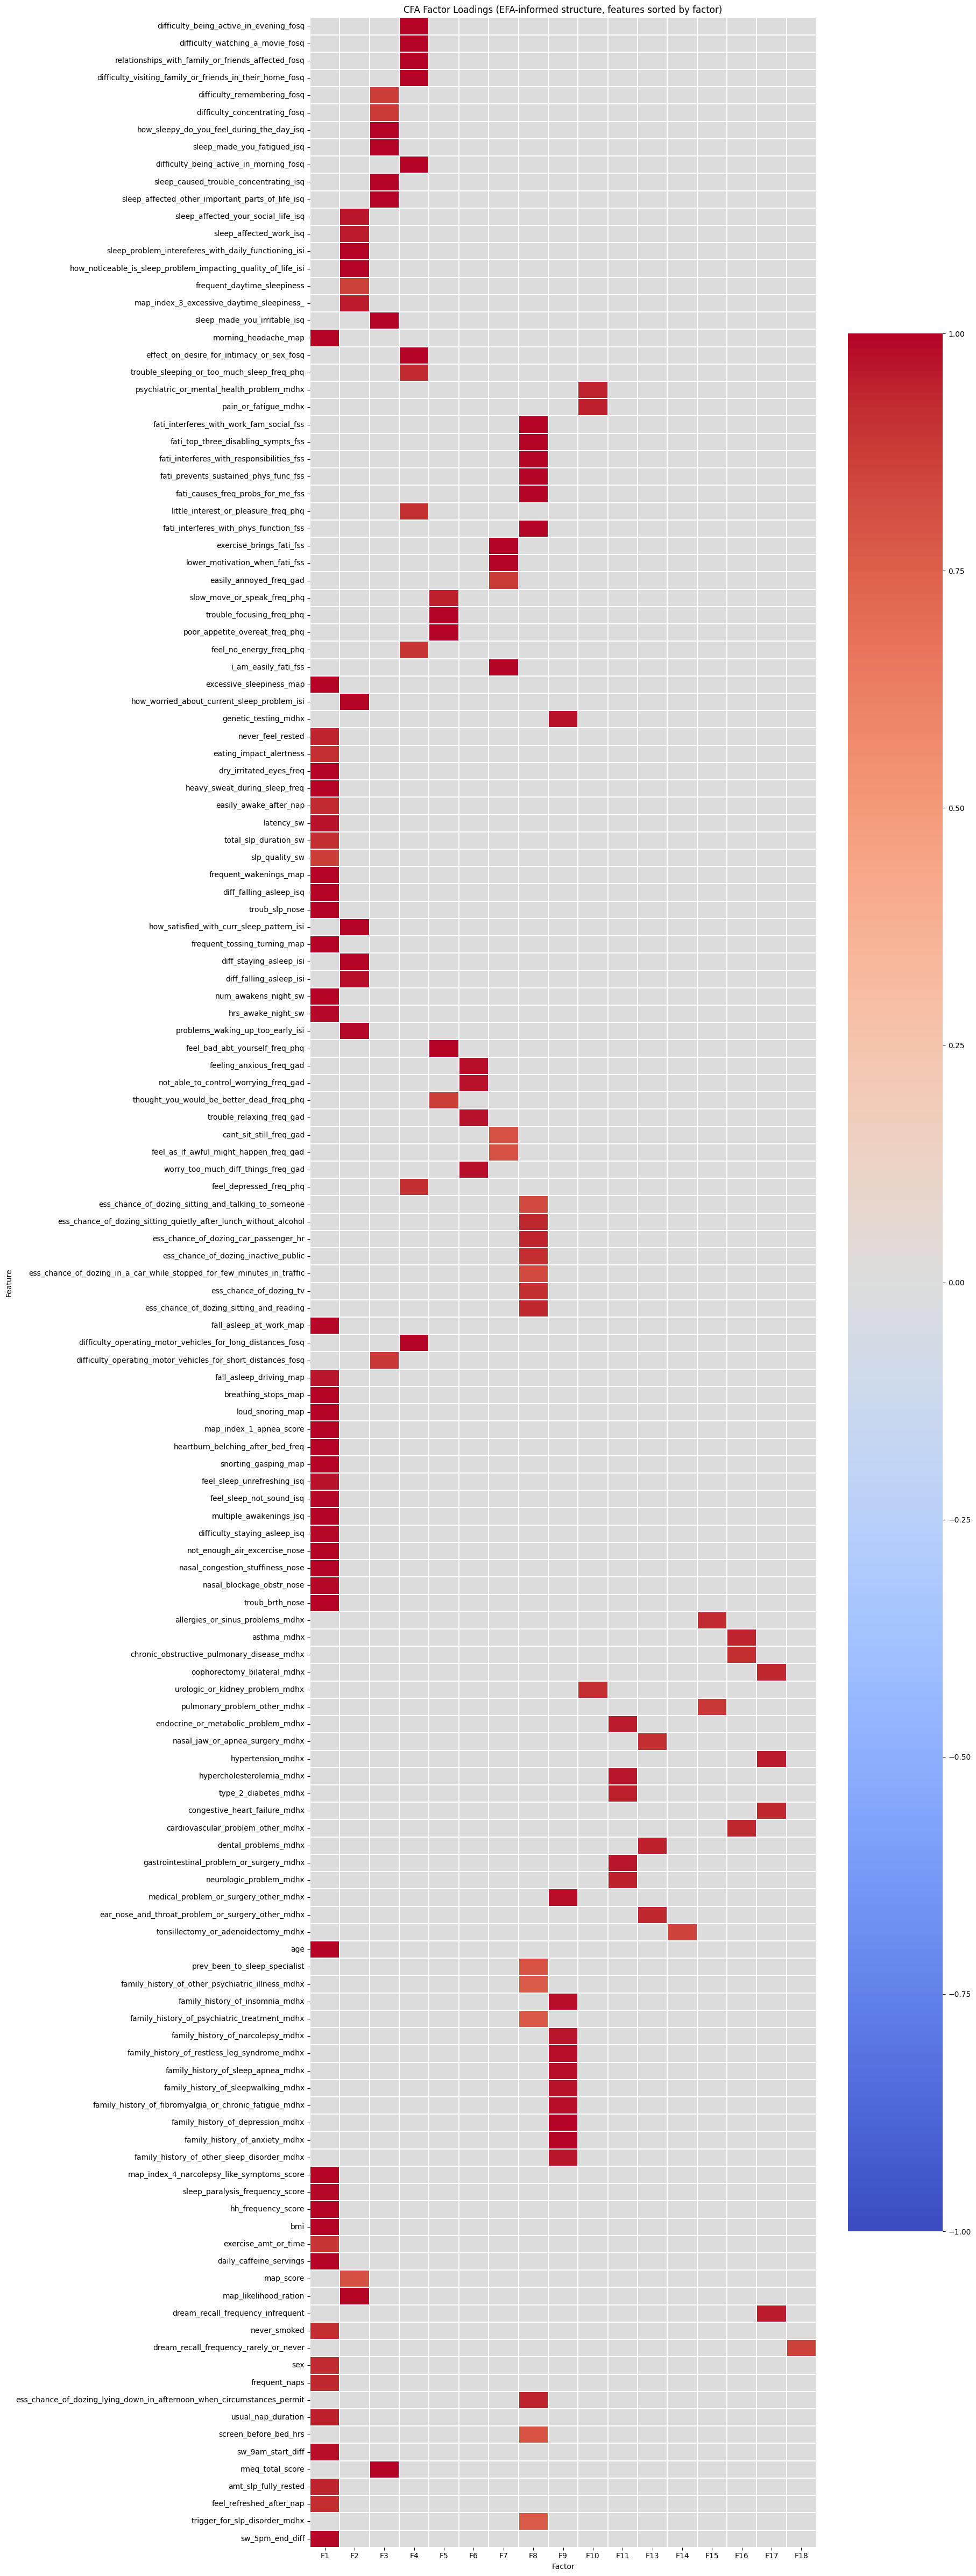

In [9]:
# Sort features by factor assignment for block-diagonal structure
sort_order = factor_assignments.map({col: i for i, col in enumerate(fa_loadings.columns)})
sorted_features = sort_order.sort_values().index
cfa_loadings_sorted = cfa_loadings.loc[sorted_features]

fig, ax = plt.subplots(figsize=(18, max(10, len(encoded_features.columns) // 3)))
sns.heatmap(
    cfa_loadings_sorted,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2,
    ax=ax,
)
ax.set_title("CFA Factor Loadings (EFA-informed structure, features sorted by factor)")
ax.set_xlabel("Factor")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


In [10]:
cfa_scores = confirmatory_factor_analyzer.transform(encoded_features.values)
cfa_df = pd.DataFrame(cfa_scores, columns=list(model_dict.keys()))
cfa_df["ahi"] = encoded_target.values

cfa_dataset_path = "../../data/processed/mlflow/mlflow_cfa_dataset_v1.csv"
cfa_df.to_csv(cfa_dataset_path, index=False)

print(f"CFA dataset saved to {cfa_dataset_path}  shape={cfa_df.shape}")
display(cfa_df.head(5))


CFA dataset saved to ../../data/processed/mlflow/mlflow_cfa_dataset_v1.csv  shape=(1687, 18)


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F13,F14,F15,F16,F17,F18,ahi
0,-0.143716,-0.104106,0.082198,0.310315,-0.156887,-0.066842,-0.168565,-0.124902,-0.185536,-0.300405,-0.205800,-0.244269,-0.292704,-0.238758,-0.132812,-0.165508,0.585288,0.3
1,-0.496754,0.223433,0.453341,-0.981626,-0.343780,-0.590463,0.490244,0.563383,0.357905,0.770250,-0.205800,-0.244269,-0.292704,-0.238758,-0.132812,0.076625,-0.570896,0.4
2,-0.100753,0.981688,0.921126,-0.245896,-0.136531,-0.100637,0.183422,-0.311052,-0.185536,-0.300405,-0.205800,0.461106,0.874651,-0.238758,-0.132812,-0.165508,0.585288,1.0
3,0.053249,-0.516036,-0.086786,-0.100491,0.311715,1.176224,-0.446000,-0.995069,-0.004060,0.410342,-0.006082,-0.244269,-0.292704,-0.238758,-0.132812,-0.165508,0.585288,3.9
4,-0.495538,-0.405588,0.519192,-0.272442,0.051571,0.196574,0.180937,-0.330084,0.169108,0.053340,-0.205800,0.100875,-0.292704,0.310243,-0.132812,0.079199,0.585288,1.3


## **Feature Importances: EFA & CFA Datasets**

Compare feature importance and permutation importance across the EFA factor dataset, CFA factor dataset, and the original encoded features. A helper function handles permutation importance computation and visualisation. Concludes with a top-N feature selection step that produces reduced datasets used in the MLflow comparison experiments.


### EFA Dataset Feature Importances

In [11]:
# get feature importances from efa and cfa datasets
rf_model = RandomForestClassifier(n_estimators=500, random_state=42)

fa_X = fa_df.drop(columns=["ahi"])
fa_y = fa_df["ahi"]
fa_y = convert_ahi(fa_y, threshold=15)

fa_X_train, fa_test_X, fa_train_y, fa_test_y = train_test_split(fa_X, fa_y, test_size=0.2, random_state=42)
rf_model.fit(fa_X_train, fa_train_y)
fa_importances = pd.Series(rf_model.feature_importances_, index=fa_X.columns).sort_values(ascending=False)

display(fa_importances)

Factor_1     0.071794
Factor_12    0.064804
Factor_6     0.063199
Factor_13    0.059278
Factor_14    0.058901
Factor_3     0.056448
Factor_17    0.053780
Factor_7     0.053722
Factor_16    0.053469
Factor_5     0.052946
Factor_15    0.052577
Factor_9     0.052011
Factor_4     0.051783
Factor_2     0.051735
Factor_10    0.051502
Factor_8     0.050967
Factor_11    0.050896
Factor_18    0.050187
dtype: float64

/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Elapsed time to compute the importances: 5.960 seconds
Factor_10    0.004882
Factor_7     0.003994
Factor_9     0.002071
Factor_16    0.000592
Factor_14   -0.003254
Factor_13   -0.003698
Factor_18   -0.003994
Factor_12   -0.004586
Factor_4    -0.004734
Factor_11   -0.004882
Factor_2    -0.005178
Factor_17   -0.006065
Factor_1    -0.007249
Factor_15   -0.007544
Factor_5    -0.007988
Factor_8    -0.008728
Factor_3    -0.008876
Factor_6    -0.011686


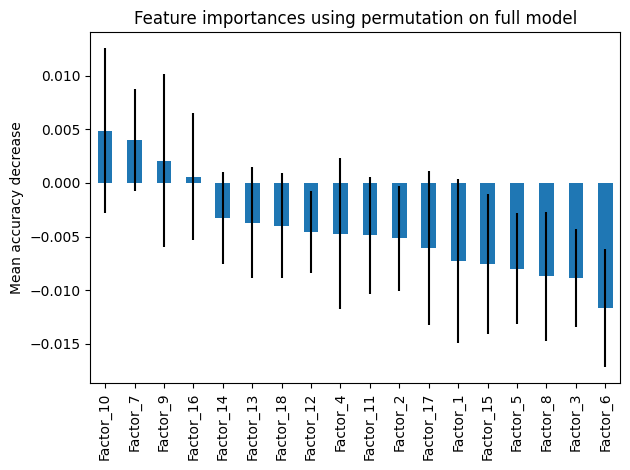

Factor_10    0.004882
Factor_7     0.003994
Factor_9     0.002071
Factor_16    0.000592
Factor_14   -0.003254
Factor_13   -0.003698
Factor_18   -0.003994
Factor_12   -0.004586
Factor_4    -0.004734
Factor_11   -0.004882
Factor_2    -0.005178
Factor_17   -0.006065
Factor_1    -0.007249
Factor_15   -0.007544
Factor_5    -0.007988
Factor_8    -0.008728
Factor_3    -0.008876
Factor_6    -0.011686
dtype: float64

In [12]:
plot_permutation_importance(rf_model, fa_test_X, fa_test_y)


In [13]:
# look at top loadings for factors 7, 9, 10, 16
# fa_loadings columns are 0-indexed ints, so Factor_N = index N-1
columns_of_interest = [6, 8, 9, 15]
fa_loadings_subset = fa_loadings[columns_of_interest]

n = 7
top_features = {}
for factor in fa_loadings_subset.columns:
    top = fa_loadings_subset[factor].abs().nlargest(n)
    top_features[f"Factor_{factor+1}"] = [f"{feat}  ({fa_loadings_subset.loc[feat, factor]:+.2f})" for feat in top.index]

pd.DataFrame(top_features, index=[f"#{i+1}" for i in range(n)])

,Factor_7,Factor_9,Factor_10,Factor_16
#1,troub_brth_nose (+0.84),family_history_of_psychiatric_treatment_mdhx ...,map_index_4_narcolepsy_like_symptoms_score (+...,latency_sw (+0.42)
#2,nasal_blockage_obstr_nose (+0.80),family_history_of_depression_mdhx (+0.64),hh_frequency_score (+0.73),diff_falling_asleep_isi (+0.34)
#3,nasal_congestion_stuffiness_nose (+0.74),family_history_of_anxiety_mdhx (+0.58),sleep_paralysis_frequency_score (+0.67),diff_falling_asleep_isq (+0.33)
#4,not_enough_air_excercise_nose (+0.62),family_history_of_other_psychiatric_illness_md...,fall_asleep_driving_map (+0.28),how_satisfied_with_curr_sleep_pattern_isi (-0...
#5,allergies_or_sinus_problems_mdhx (+0.42),family_history_of_insomnia_mdhx (+0.32),map_index_3_excessive_daytime_sleepiness_ (+0...,sex (+0.21)
#6,ear_nose_and_throat_problem_or_surgery_other_m...,family_history_of_fibromyalgia_or_chronic_fati...,morning_headache_map (+0.24),rmeq_total_score (-0.20)
#7,asthma_mdhx (+0.19),psychiatric_or_mental_health_problem_mdhx (+0...,fall_asleep_at_work_map (+0.18),sleep_problem_intereferes_with_daily_functioni...


### CFA Dataset Feature Importances

In [14]:
cfa_X = cfa_df.drop(columns=["ahi"])
cfa_y = cfa_df["ahi"]
cfa_y = convert_ahi(cfa_y, threshold=15)
cfa_X_train, cfa_test_X, cfa_train_y, cfa_test_y = train_test_split(cfa_X, cfa_y, test_size=0.2, random_state=42)
rf_model.fit(cfa_X_train, cfa_train_y)
cfa_importances = pd.Series(rf_model.feature_importances_, index=cfa_X.columns).sort_values(ascending=False)
display(cfa_importances)

F1     0.122963
F2     0.106314
F3     0.101586
F8     0.094358
F7     0.083305
F4     0.082814
F9     0.072517
F5     0.060466
F6     0.060063
F11    0.049931
F17    0.032628
F10    0.032281
F13    0.031367
F16    0.025472
F15    0.018228
F14    0.013250
F18    0.012455
dtype: float64

/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Elapsed time to compute the importances: 4.501 seconds
F1     0.017160
F8     0.016420
F2     0.012870
F10    0.006065
F9     0.005178
F4     0.005030
F11    0.004882
F3     0.004734
F6     0.003402
F17    0.003254
F13    0.002367
F14    0.002219
F15    0.001775
F5     0.001183
F16   -0.000888
F7    -0.001331
F18   -0.002219


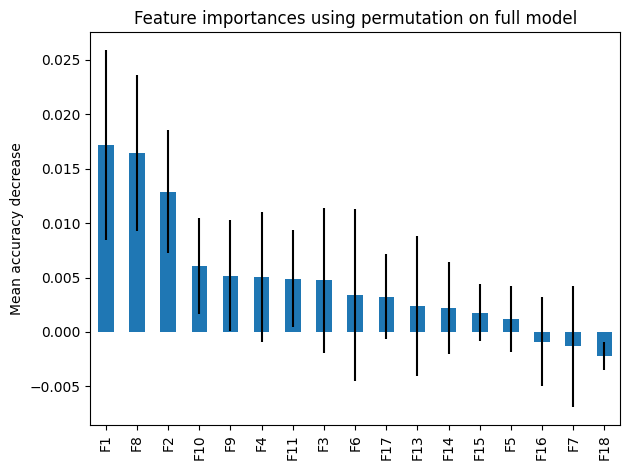

F1     0.017160
F8     0.016420
F2     0.012870
F10    0.006065
F9     0.005178
F4     0.005030
F11    0.004882
F3     0.004734
F6     0.003402
F17    0.003254
F13    0.002367
F14    0.002219
F15    0.001775
F5     0.001183
F16   -0.000888
F7    -0.001331
F18   -0.002219
dtype: float64

In [15]:
plot_permutation_importance(rf_model, cfa_test_X, cfa_test_y)


In [16]:
# show features that are important from cfa data

n = 7
top_features = {}
for factor in cfa_loadings.columns:
    top = cfa_loadings[factor].abs().nlargest(n)
    top_features[factor] = [f"{feat}  ({cfa_loadings.loc[feat, factor]:+.2f})" for feat in top.index]

pd.DataFrame(top_features, index=[f"#{i+1}" for i in range(n)])

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F13,F14,F15,F16,F17,F18
#1,bmi (+1.11),how_noticeable_is_sleep_problem_impacting_qual...,rmeq_total_score (+1.07),difficulty_being_active_in_evening_fosq (+1.03),trouble_focusing_freq_phq (+1.00),worry_too_much_diff_things_freq_gad (+0.98),i_am_easily_fati_fss (+1.21),fati_interferes_with_work_fam_social_fss (+1.26),family_history_of_depression_mdhx (+0.99),pain_or_fatigue_mdhx (+0.95),gastrointestinal_problem_or_surgery_mdhx (+0.97),dental_problems_mdhx (+0.95),tonsillectomy_or_adenoidectomy_mdhx (+0.86),allergies_or_sinus_problems_mdhx (+0.93),asthma_mdhx (+0.94),hypertension_mdhx (+0.96),dream_recall_frequency_rarely_or_never (+0.86)
#2,age (+1.09),map_likelihood_ration (+1.07),sleep_made_you_irritable_isq (+1.03),difficulty_watching_a_movie_fosq (+1.03),poor_appetite_overeat_freq_phq (+1.00),feeling_anxious_freq_gad (+0.98),lower_motivation_when_fati_fss (+1.13),fati_top_three_disabling_sympts_fss (+1.26),family_history_of_anxiety_mdhx (+0.99),psychiatric_or_mental_health_problem_mdhx (+0...,hypercholesterolemia_mdhx (+0.96),ear_nose_and_throat_problem_or_surgery_other_m...,age (+0.00),pulmonary_problem_other_mdhx (+0.88),cardiovascular_problem_other_mdhx (+0.93),dream_recall_frequency_infrequent (+0.95),age (+0.00)
#3,breathing_stops_map (+1.08),sleep_problem_intereferes_with_daily_functioni...,sleep_made_you_fatigued_isq (+1.02),effect_on_desire_for_intimacy_or_sex_fosq (+1...,feel_bad_abt_yourself_freq_phq (+1.00),not_able_to_control_worrying_freq_gad (+0.97),exercise_brings_fati_fss (+1.07),fati_causes_freq_probs_for_me_fss (+1.25),family_history_of_sleep_apnea_mdhx (+0.98),urologic_or_kidney_problem_mdhx (+0.91),endocrine_or_metabolic_problem_mdhx (+0.96),nasal_jaw_or_apnea_surgery_mdhx (+0.92),bmi (+0.00),age (+0.00),chronic_obstructive_pulmonary_disease_mdhx (+...,oophorectomy_bilateral_mdhx (+0.94),bmi (+0.00)
#4,snorting_gasping_map (+1.08),how_worried_about_current_sleep_problem_isi (...,sleep_affected_other_important_parts_of_life_i...,difficulty_being_active_in_morning_fosq (+1.02),slow_move_or_speak_freq_phq (+0.95),trouble_relaxing_freq_gad (+0.97),easily_annoyed_freq_gad (+0.88),fati_interferes_with_responsibilities_fss (+1...,family_history_of_insomnia_mdhx (+0.98),age (+0.00),type_2_diabetes_mdhx (+0.95),age (+0.00),sex (+0.00),bmi (+0.00),age (+0.00),congestive_heart_failure_mdhx (+0.93),sex (+0.00)
#5,frequent_tossing_turning_map (+1.07),how_satisfied_with_curr_sleep_pattern_isi (+1...,sleep_caused_trouble_concentrating_isq (+1.02),relationships_with_family_or_friends_affected_...,thought_you_would_be_better_dead_freq_phq (+0...,age (+0.00),cant_sit_still_freq_gad (+0.80),fati_interferes_with_phys_function_fss (+1.23),medical_problem_or_surgery_other_mdhx (+0.98),bmi (+0.00),neurologic_problem_mdhx (+0.95),bmi (+0.00),sw_9am_start_diff (+0.00),sex (+0.00),bmi (+0.00),age (+0.00),sw_9am_start_diff (+0.00)
#6,map_index_1_apnea_score (+1.07),diff_staying_asleep_isi (+1.02),how_sleepy_do_you_feel_during_the_day_isq (+1...,difficulty_visiting_family_or_friends_in_their...,age (+0.00),bmi (+0.00),feel_as_if_awful_might_happen_freq_gad (+0.80),fati_prevents_sustained_phys_func_fss (+1.23),family_history_of_fibromyalgia_or_chronic_fati...,sex (+0.00),age (+0.00),sex (+0.00),sw_5pm_end_diff (+0.00),sw_9am_start_diff (+0.00),sex (+0.00),bmi (+0.00),sw_5pm_end_diff (+0.00)
#7,frequent_wakenings_map (+1.07),problems_waking_up_too_early_isi (+0.99),difficulty_operating_motor_vehicles_for_short_...,difficulty_operating_motor_vehicles_for_long_d...,bmi (+0.00),sex (+0.00),age (+0.00),ess_chance_of_dozing_car_passenger_hr (+0.94),family_history_of_restless_leg_syndrome_mdhx ...,sw_9am_start_diff (+0.00),bmi (+0.00),sw_9am_start_diff (+0.00),nasal_congestion_stuffiness_nose (+0.00),sw_5pm_end_diff (+0.00),sw_9am_start_diff (+0.00),sex (+0.00),nasal_congestion_stuffiness_nose (+0.00)


### Top Feature Dataset Creation

Select the top-N features by absolute factor loading magnitude from both EFA and CFA results. These reduced datasets are saved to CSV and used as additional inputs in the MLflow comparison experiment.


In [17]:
top_n = 5   # top features per factor to include

fa_top_features  = list({f for col in fa_loadings.columns  for f in fa_loadings[col].abs().nlargest(top_n).index})
cfa_top_features = list({f for col in cfa_loadings.columns for f in cfa_loadings[col].abs().nlargest(top_n).index})

fa_top_df  = encoded_features[fa_top_features].assign(ahi=encoded_target.values)
cfa_top_df = encoded_features[cfa_top_features].assign(ahi=encoded_target.values)

print(f"EFA top df: {fa_top_df.shape}  ({len(fa_top_features)} unique features)")
print(f"CFA top df: {cfa_top_df.shape}  ({len(cfa_top_features)} unique features)")
display(fa_top_df.head())

fa_top_df.to_csv("../../data/processed/mlflow/mlflow_fa_top_features_dataset_v1.csv", index=False)
cfa_top_df.to_csv("../../data/processed/mlflow/mlflow_cfa_top_features_dataset_v1.csv", index=False)

EFA top df: (1687, 79)  (78 unique features)
CFA top df: (1687, 69)  (68 unique features)


,difficulty_watching_a_movie_fosq,worry_too_much_diff_things_freq_gad,medical_problem_or_surgery_other_mdhx,effect_on_desire_for_intimacy_or_sex_fosq,allergies_or_sinus_problems_mdhx,never_smoked,diff_falling_asleep_isi,map_index_3_excessive_daytime_sleepiness_,map_index_4_narcolepsy_like_symptoms_score,sleep_caused_trouble_concentrating_isq,...,exercise_amt_or_time,gastrointestinal_problem_or_surgery_mdhx,bmi,cardiovascular_problem_other_mdhx,dream_recall_frequency_rarely_or_never,morning_headache_map,difficulty_operating_motor_vehicles_for_short_distances_fosq,map_likelihood_ration,age,ahi
0,4.0,1.0,0.0,4.0,0.0,0.0,1.0,1.000000,0.0,2.0,...,1.0,0.0,30.7,0.0,1.0,1.0,4.0,0.959701,58.0,0.3
1,2.0,0.0,1.0,2.0,0.0,1.0,1.0,1.000000,0.0,4.0,...,1.0,0.0,29.4,0.0,0.0,1.0,3.0,0.105484,30.0,0.4
2,3.0,0.0,0.0,3.0,0.0,1.0,4.0,1.333330,0.0,4.0,...,1.0,0.0,25.8,0.0,1.0,2.0,4.0,0.050057,30.0,1.0
3,3.0,1.0,0.0,4.0,0.0,0.0,2.0,0.666667,2.0,1.0,...,1.0,1.0,26.8,0.0,1.0,2.0,4.0,0.447595,42.0,3.9
4,3.0,1.0,0.0,2.0,1.0,0.0,0.0,0.333333,0.0,3.0,...,0.0,0.0,45.2,0.0,1.0,0.0,4.0,5.142808,36.0,1.3


## **MLFlow Integrations**

Register all five datasets with MLflow and run a grid of (dataset × model) experiments — RF and HGB — across the encoded baseline, EFA factors, CFA factors, EFA top features, and CFA top features. Metrics (accuracy, AUC, F1, AUPRC), SHAP feature importances, and confusion matrices are logged as artifacts per run.


In [18]:
mlflow.set_tracking_uri(os.path.abspath("../../mlruns"))

_ds_specs = [
    ("encoded_dataset_v1",          encoded_df,  "../../data/processed/mlflow/mlflow_dataset_v1.csv"),
    ("fa_dataset_v1",               fa_df,       "../../data/processed/mlflow/mlflow_factor_dataset_v1.csv"),
    ("cfa_dataset_v1",              cfa_df,      "../../data/processed/mlflow/mlflow_cfa_dataset_v1.csv"),
    ("fa_top_features_dataset_v1",  fa_top_df,   "../../data/processed/mlflow/mlflow_fa_top_features_dataset_v1.csv"),
    ("cfa_top_features_dataset_v1", cfa_top_df,  "../../data/processed/mlflow/mlflow_cfa_top_features_dataset_v1.csv"),
]

enc_dataset, fa_dataset, cfa_dataset, fa_top_dataset, cfa_top_dataset = [
    mlflow.data.from_pandas(df, source=path, name=name, targets="ahi")
    for name, df, path in _ds_specs
]


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource s

In [19]:
enc_X = encoded_df.drop(columns=["ahi"])
enc_y = convert_ahi(encoded_df["ahi"], threshold=15)
enc_X_train, enc_test_X, enc_train_y, enc_test_y = train_test_split(enc_X, enc_y, test_size=0.2, random_state=42, stratify=enc_y)

fa_top_X = fa_top_df.drop(columns=["ahi"])
fa_top_y = convert_ahi(fa_top_df["ahi"], threshold=15)
fa_top_X_train, fa_top_test_X, fa_top_train_y, fa_top_test_y = train_test_split(fa_top_X, fa_top_y, test_size=0.2, random_state=42, stratify=fa_top_y)

cfa_top_X = cfa_top_df.drop(columns=["ahi"])
cfa_top_y = convert_ahi(cfa_top_df["ahi"], threshold=15)
cfa_top_X_train, cfa_top_test_X, cfa_top_train_y, cfa_top_test_y = train_test_split(cfa_top_X, cfa_top_y, test_size=0.2, random_state=42, stratify=cfa_top_y)

trials = [
    ("encoded_baseline",  enc_dataset,     enc_X_train,     enc_test_X,     enc_train_y,     enc_test_y),
    ("efa_factors",       fa_dataset,      fa_X_train,      fa_test_X,      fa_train_y,      fa_test_y),
    ("cfa_factors",       cfa_dataset,     cfa_X_train,     cfa_test_X,     cfa_train_y,     cfa_test_y),
    ("efa_top_features",  fa_top_dataset,  fa_top_X_train,  fa_top_test_X,  fa_top_train_y,  fa_top_test_y),
    ("cfa_top_features",  cfa_top_dataset, cfa_top_X_train, cfa_top_test_X, cfa_top_train_y, cfa_top_test_y),
]

model_configs = {
    "rf": (RandomForestClassifier, dict(
        n_estimators=500, max_depth=10, min_samples_leaf=5,
        class_weight="balanced_subsample", random_state=42, n_jobs=-1,
    )),
    "hgb": (HistGradientBoostingClassifier, dict(
        max_iter=1000, learning_rate=0.05, max_depth=4,
        min_samples_leaf=20, class_weight="balanced", random_state=42,
    )),
}

experiment = _setup_experiment("dataset-comparison-v1", {
    "description": "Compare encoded baseline vs EFA/CFA factor datasets across RF and HGB models",
})
_run_mlflow_trials(trials, model_configs)


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


encoded_baseline           rf       0.642   0.590   0.309   0.444         146
encoded_baseline           hgb      0.618   0.552   0.358   0.410         146
efa_factors                rf       0.497   0.485   0.370   0.316          18
efa_factors                hgb      0.521   0.507   0.413   0.330          18
cfa_factors                rf       0.609   0.512   0.205   0.333          17
cfa_factors                hgb      0.604   0.528   0.380   0.376          17


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


efa_top_features           rf       0.618   0.572   0.325   0.417          78
efa_top_features           hgb      0.583   0.563   0.319   0.373          78


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


cfa_top_features           rf       0.636   0.568   0.320   0.428          68
cfa_top_features           hgb      0.565   0.525   0.323   0.355          68


## **SMOTETomek Resampled Dataset Comparison**

Apply SMOTETomek to each dataset's **training split only** to address class imbalance.  
Test sets are kept identical to the baseline experiment for a fair AUPRC comparison.

In [20]:
from imblearn.combine import SMOTETomek

smotetomek = SMOTETomek(random_state=42)

# ── apply resampling to each training split; test sets are unchanged ──────────
smote_trials = []
print(f"{'dataset':<25}  {'before':>8}  {'after':>8}  {'pos_before':>12}  {'pos_after':>10}")
print("-" * 70)
for name, mlflow_ds, X_train, X_test, y_train, y_test in trials:
    X_res, y_res = smotetomek.fit_resample(X_train, y_train)
    # preserve DataFrame column names lost during resampling
    X_res = pd.DataFrame(X_res, columns=X_train.columns)
    y_res = pd.Series(y_res, name=y_train.name)
    smote_trials.append((name, mlflow_ds, X_res, X_test, y_res, y_test))
    print(f"{name:<25}  {len(y_train):>8}  {len(y_res):>8}  {int(y_train.sum()):>12}  {int(y_res.sum()):>10}")

dataset                      before     after    pos_before   pos_after
----------------------------------------------------------------------
encoded_baseline               1349      1732           461         866
efa_factors                    1349      1252           464         626
cfa_factors                    1349      1684           464         842
efa_top_features               1349      1728           461         864
cfa_top_features               1349      1730           461         865


In [21]:
model_configs_balanced = {
    "rf": (RandomForestClassifier, dict(
        n_estimators=500, max_depth=10, min_samples_leaf=2,
        random_state=42, n_jobs=-1,
    )),
    "hgb": (HistGradientBoostingClassifier, dict(
        max_iter=1000, learning_rate=0.05, max_depth=4,
        min_samples_leaf=10, random_state=42,
    )),
}

experiment_smote = _setup_experiment("dataset-comparison-smotetomek-v1", {
    "description": "Same datasets as dataset-comparison-v1 with SMOTETomek resampling on training splits",
    "resampling": "SMOTETomek",
})
_run_mlflow_trials(smote_trials, model_configs_balanced, extra_run_tags={"resampling": "SMOTETomek"})


dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------
encoded_baseline           rf       0.642   0.574   0.219   0.402         146
encoded_baseline           hgb      0.633   0.576   0.295   0.430         146
efa_factors                rf       0.485   0.463   0.370   0.302          18
efa_factors                hgb      0.521   0.494   0.367   0.315          18
cfa_factors                rf       0.609   0.502   0.175   0.333          17
cfa_factors                hgb      0.595   0.488   0.283   0.333          17
efa_top_features           rf       0.633   0.585   0.195   0.418          78
efa_top_features           hgb      0.651   0.596   0.344   0.415          78
cfa_top_features           rf       0.645   0.551   0.250   0.403          68
cfa_top_features           hgb      0.586   0.525   0.271   0.352          68


## Feature Selection Reprocessing

## IRT-Based Dataset

Replace each validated Likert-scale questionnaire with a single **IRT theta score** estimated via the **Graded Response Model (GRM)**. Theta is an information-weighted latent trait estimate — it accounts for each item's discrimination and threshold difficulty, unlike raw sum scores which weight all items equally.

GRM parameters are estimated per scale using marginal maximum likelihood (`grm_mml`). Person thetas are recovered with EAP (Expected A Posteriori) scoring using a N(0,1) prior.

| Feature | Scale | Items | Response categories |
|---|---|---|---|
| `theta_depression` | PHQ-9 | 9 | 0–3 |
| `theta_anxiety` | GAD-7 | 7 | 0–3 |
| `theta_fatigue` | FSS-9 | 9 | 1–7 (shifted to 0–6) |
| `theta_nasal_obstruction` | NOSE | 5 | 0–4 |
| `theta_osa_symptoms` | OSA items | 3 | 0–5 |

In [22]:
from girth import grm_mml

# ── scale definitions ─────────────────────────────────────────────────────────
IRT_SCALES = {
    "theta_depression":        [c for c in encoded_df.columns if c.endswith("_phq")],
    "theta_anxiety":           [c for c in encoded_df.columns if c.endswith("_gad")],
    "theta_fatigue":           [c for c in encoded_df.columns if c.endswith("_fss")],
    "theta_nasal_obstruction": [c for c in encoded_df.columns if c.endswith("_nose")],
    "theta_osa_symptoms":      [
        "heartburn_belching_after_bed_freq",
        "heavy_sweat_during_sleep_freq",
        "dry_irritated_eyes_freq",
    ],
}

all_scale_cols = [col for cols in IRT_SCALES.values() for col in cols]

# ── fit GRM per scale and score respondents ───────────────────────────────────
theta_scores = {}
print(f"{'scale':<30}  {'items':>5}  {'theta min':>10}  {'theta max':>10}")
print("-" * 60)
for theta_name, item_cols in IRT_SCALES.items():
    items = encoded_df[item_cols].values.astype(int)
    items = items - items.min()      # shift to 0-indexed (handles FSS 1–7 → 0–6)
    data_T = items.T                 # (n_items, n_persons)

    grm_params = grm_mml(data_T)
    theta = grm_score_eap(data_T, grm_params["Discrimination"], grm_params["Difficulty"])
    theta_scores[theta_name] = theta
    print(f"{theta_name:<30}  {len(item_cols):>5}  {theta.min():>10.3f}  {theta.max():>10.3f}")

# ── build IRT dataset: drop item columns, insert theta scores before ahi ──────
irt_df = encoded_df.drop(columns=all_scale_cols).copy()
ahi_loc = irt_df.columns.get_loc("ahi")
for theta_name, scores in theta_scores.items():
    irt_df.insert(ahi_loc, theta_name, scores)
    ahi_loc += 1   # keep new columns before ahi

irt_dataset_path = "../../data/processed/mlflow/mlflow_irt_dataset_v1.csv"
irt_df.to_csv(irt_dataset_path, index=False)

print(f"\nIRT dataset saved → {irt_dataset_path}")
print(f"Shape: {irt_df.shape}  (dropped {len(all_scale_cols)} item cols, added {len(IRT_SCALES)} theta cols)")
display(irt_df.head())


scale                           items   theta min   theta max
------------------------------------------------------------
theta_depression                    9      -1.587       3.006
theta_anxiety                       7      -1.261       2.615
theta_fatigue                       9      -2.024       2.189
theta_nasal_obstruction             5      -1.231       2.858


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/girth/unidimensional/polytomous/grm_mml.py:156: RuntimeWarning: invalid value encountered in log
  return -np.log(otpt).sum()
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/girth/unidimensional/polytomous/grm_mml.py:156: RuntimeWarning: invalid value encountered in log
  return -np.log(otpt).sum()


theta_osa_symptoms                  3      -1.043       2.928

IRT dataset saved → ../../data/processed/mlflow/mlflow_irt_dataset_v1.csv
Shape: (1687, 119)  (dropped 33 item cols, added 5 theta cols)


,age,bmi,sex,sw_9am_start_diff,sw_5pm_end_diff,exercise_amt_or_time,daily_caffeine_servings,eating_impact_alertness,never_smoked,never_feel_rested,...,hypertension_mdhx,oophorectomy_bilateral_mdhx,theta_depression,theta_anxiety,theta_fatigue,theta_nasal_obstruction,theta_osa_symptoms,ahi,dream_recall_frequency_infrequent,dream_recall_frequency_rarely_or_never
0,58.0,30.7,1.0,-1.00,0.0,1.0,2.0,2.0,0.0,0.0,...,0.0,0.0,-0.324279,0.083694,-0.040206,-0.418735,-0.013245,0.3,0.0,1.0
1,30.0,29.4,1.0,-1.00,0.0,1.0,3.0,2.0,1.0,1.0,...,0.0,0.0,0.567647,-0.458682,0.956447,-1.102886,0.726906,0.4,1.0,0.0
2,30.0,25.8,1.0,-2.00,2.0,1.0,1.0,2.0,1.0,0.0,...,0.0,0.0,-0.956219,-0.024499,0.170148,-0.897600,0.250793,1.0,0.0,1.0
3,42.0,26.8,0.0,-3.00,3.0,1.0,3.0,2.0,0.0,1.0,...,0.0,0.0,-0.264815,0.994030,-1.664292,-0.376366,0.066692,3.9,0.0,1.0
4,36.0,45.2,0.0,-0.75,0.5,0.0,2.0,2.0,0.0,0.0,...,1.0,0.0,0.119183,0.499408,-0.356772,0.615183,-1.043423,1.3,0.0,1.0


In [ ]:
irt_mlflow_ds = mlflow.data.from_pandas(
    irt_df, source=irt_dataset_path, name="irt_dataset_v1", targets="ahi"
)

irt_X = irt_df.drop(columns=["ahi"])
irt_y = convert_ahi(irt_df["ahi"], threshold=15)
irt_X_train, irt_test_X, irt_train_y, irt_test_y = train_test_split(
    irt_X, irt_y, test_size=0.2, random_state=42, stratify=irt_y
)

irt_trials = [
    ("encoded_baseline", enc_dataset,   enc_X_train,  enc_test_X,  enc_train_y,  enc_test_y),
    ("irt_dataset_v1",   irt_mlflow_ds, irt_X_train,  irt_test_X,  irt_train_y,  irt_test_y),
]

experiment_irt = _setup_experiment("dataset-comparison-irt-v1", {
    "description": "IRT-scored dataset vs encoded baseline — RF and HGB",
    "feature_engineering": "GRM-EAP",
})
_run_mlflow_trials(irt_trials, model_configs)


dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


encoded_baseline           rf       0.642   0.590   0.309   0.444         146


## IRT Hybrid Experiments

Two hybrid variants tested against the encoded baseline and the pure IRT replacement dataset:

- **`irt_augmented`** — all 146 original encoded features *plus* the 5 theta scores (151 features total). Lets the model exploit both raw items and latent traits.
- **`irt_augmented` + SMOTETomek** — same augmented dataset with SMOTETomek oversampling on the training split only, using the balanced model configs.

In [ ]:
irt_aug_df = encoded_df.copy()
for theta_name, scores in theta_scores.items():
    irt_aug_df[theta_name] = scores

irt_aug_path = "../../data/processed/mlflow/mlflow_irt_augmented_dataset_v1.csv"
irt_aug_df.to_csv(irt_aug_path, index=False)
print(f"IRT augmented dataset: {irt_aug_df.shape}  ({encoded_df.shape[1] - 1} original + {len(theta_scores)} theta cols)")

irt_aug_mlflow_ds = mlflow.data.from_pandas(irt_aug_df, source=irt_aug_path, name="irt_augmented_v1", targets="ahi")

irt_aug_X = irt_aug_df.drop(columns=["ahi"])
irt_aug_y = convert_ahi(irt_aug_df["ahi"], threshold=15)
irt_aug_X_train, irt_aug_test_X, irt_aug_train_y, irt_aug_test_y = train_test_split(
    irt_aug_X, irt_aug_y, test_size=0.2, random_state=42, stratify=irt_aug_y
)

hybrid_trials = [
    ("encoded_baseline", enc_dataset,      enc_X_train,     enc_test_X,     enc_train_y,     enc_test_y),
    ("irt_replacement",  irt_mlflow_ds,    irt_X_train,     irt_test_X,     irt_train_y,     irt_test_y),
    ("irt_augmented",    irt_aug_mlflow_ds, irt_aug_X_train, irt_aug_test_X, irt_aug_train_y, irt_aug_test_y),
]

experiment_irt_hybrid = _setup_experiment("dataset-comparison-irt-hybrid-v1", {
    "description": "IRT augmented (items + thetas) vs IRT replacement vs encoded baseline",
    "feature_engineering": "GRM-EAP",
})
_run_mlflow_trials(hybrid_trials, model_configs)


IRT augmented dataset: (1687, 152)  (146 original + 5 theta cols)


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------
encoded_baseline           rf       0.642   0.590   0.309   0.444         146
encoded_baseline           hgb      0.618   0.552   0.358   0.410         146
irt_replacement            rf       0.639   0.569   0.282   0.421         118
irt_replacement            hgb      0.586   0.544   0.320   0.379         118


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


irt_augmented              rf       0.651   0.600   0.289   0.460         151
irt_augmented              hgb      0.612   0.544   0.367   0.395         151


In [ ]:
irt_smote_trials = []
print(f"{'dataset':<25}  {'before':>8}  {'after':>8}  {'pos_before':>12}  {'pos_after':>10}")
print("-" * 70)
for name, mlflow_ds, X_train, X_test, y_train, y_test in hybrid_trials:
    X_res, y_res = smotetomek.fit_resample(X_train, y_train)
    X_res = pd.DataFrame(X_res, columns=X_train.columns)
    y_res = pd.Series(y_res, name=y_train.name)
    irt_smote_trials.append((name, mlflow_ds, X_res, X_test, y_res, y_test))
    print(f"{name:<25}  {len(y_train):>8}  {len(y_res):>8}  {int(y_train.sum()):>12}  {int(y_res.sum()):>10}")

experiment_irt_smote = _setup_experiment("dataset-comparison-irt-smotetomek-v1", {
    "description": "IRT hybrid datasets with SMOTETomek resampling on training splits",
    "feature_engineering": "GRM-EAP",
    "resampling": "SMOTETomek",
})
_run_mlflow_trials(irt_smote_trials, model_configs_balanced, extra_run_tags={"resampling": "SMOTETomek"})


dataset                      before     after    pos_before   pos_after
----------------------------------------------------------------------
encoded_baseline               1349      1732           461         866
irt_replacement                1349      1728           461         864
irt_augmented                  1349      1734           461         867
dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------
encoded_baseline           rf       0.642   0.574   0.219   0.402         146
encoded_baseline           hgb      0.633   0.576   0.295   0.430         146
irt_replacement            rf       0.645   0.558   0.231   0.390         118
irt_replacement            hgb      0.615   0.558   0.261   0.385         118
irt_augmented              rf       0.648   0.567   0.232   0.410         151
irt_augmented              hgb      0.618   0.566   0.295   0.412         151


─── Mean |SHAP| for theta scores (irt_augmented, both models) ───
theta_fatigue              0.111321
theta_anxiety              0.100561
theta_osa_symptoms         0.089104
theta_nasal_obstruction    0.082247
theta_depression           0.049196

Ranks out of 151 features:
theta_fatigue               5
theta_anxiety               8
theta_osa_symptoms         10
theta_nasal_obstruction    12
theta_depression           27


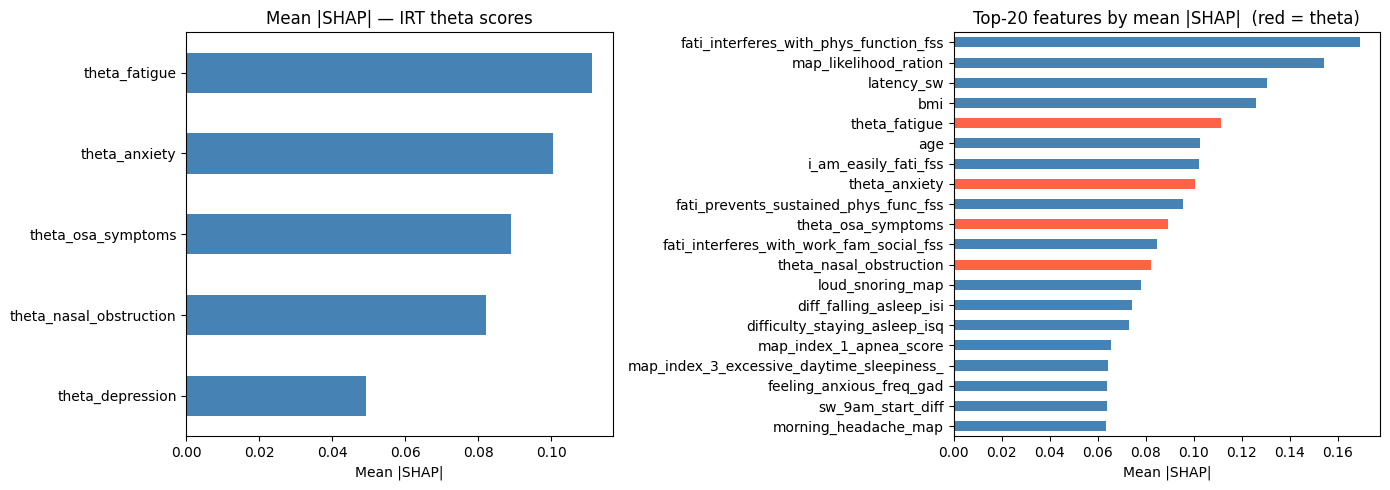

In [ ]:
# ── theta SHAP contribution analysis ─────────────────────────────────────────
# Pull SHAP metrics logged for irt_augmented runs from MLflow
theta_cols = list(theta_scores.keys())

runs_df = mlflow.search_runs(
    experiment_ids=[experiment_irt_hybrid.experiment_id],
    filter_string="tags.dataset = 'irt_augmented'",
)

shap_cols = [c for c in runs_df.columns if c.startswith("metrics.shap_")]
shap_summary = runs_df[["tags.model_type"] + shap_cols].copy()
shap_summary.columns = [c.replace("metrics.shap_", "") for c in shap_summary.columns]
shap_summary = shap_summary.rename(columns={"tags.model_type": "model"}).set_index("model")

# Mean SHAP across models for every feature
mean_shap_all = shap_summary.mean(axis=0).sort_values(ascending=False)
theta_shap = mean_shap_all[mean_shap_all.index.isin(theta_cols)].sort_values(ascending=False)

print("─── Mean |SHAP| for theta scores (irt_augmented, both models) ───")
print(theta_shap.to_string())

# Rank of each theta among all 151 features
ranks = mean_shap_all.rank(ascending=False).astype(int)
print(f"\nRanks out of {len(mean_shap_all)} features:")
print(ranks[theta_cols].sort_values().to_string())

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: theta SHAP values
theta_shap.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Mean |SHAP| — IRT theta scores")
axes[0].set_xlabel("Mean |SHAP|")
axes[0].invert_yaxis()

# Right: top-20 features overall with thetas highlighted
top20 = mean_shap_all.head(20)
colors = ["tomato" if f in theta_cols else "steelblue" for f in top20.index]
top20.plot.barh(ax=axes[1], color=colors)
axes[1].set_title("Top-20 features by mean |SHAP|  (red = theta)")
axes[1].set_xlabel("Mean |SHAP|")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## SHAP-Selected Feature Dataset

Build a reduced version of `irt_augmented` by keeping the top-30 features by mean |SHAP| (all 5 theta scores are force-included). This reduces dimensionality from 151 → ~30 features for a ~1350-sample training set, improving the sample-to-feature ratio and reducing noise for the subsequent hyperparameter tuning step.

In [ ]:
TOP_N_SHAP = 30

top_shap_features = mean_shap_all.head(TOP_N_SHAP).index.tolist()
selected_features = list(dict.fromkeys(top_shap_features + theta_cols))

irt_shap_df = irt_aug_df[selected_features + ["ahi"]].copy()
irt_shap_path = "../../data/processed/mlflow/mlflow_irt_shap_selected_v1.csv"
irt_shap_df.to_csv(irt_shap_path, index=False)
print(f"SHAP-selected dataset: {irt_shap_df.shape}  ({len(selected_features)} features)")
print(f"Features: {selected_features}")

irt_shap_mlflow_ds = mlflow.data.from_pandas(irt_shap_df, source=irt_shap_path, name="irt_shap_selected_v1", targets="ahi")

irt_shap_X = irt_shap_df.drop(columns=["ahi"])
irt_shap_y = convert_ahi(irt_shap_df["ahi"], threshold=15)
irt_shap_X_train, irt_shap_test_X, irt_shap_train_y, irt_shap_test_y = train_test_split(
    irt_shap_X, irt_shap_y, test_size=0.2, random_state=42, stratify=irt_shap_y
)

shap_sel_trials = [
    ("irt_augmented_full",       irt_aug_mlflow_ds,  irt_aug_X_train,   irt_aug_test_X,   irt_aug_train_y,   irt_aug_test_y),
    (f"irt_shap_top{TOP_N_SHAP}", irt_shap_mlflow_ds, irt_shap_X_train, irt_shap_test_X, irt_shap_train_y, irt_shap_test_y),
]

experiment_shap_sel = _setup_experiment("dataset-comparison-shap-selected-v1", {
    "description": f"irt_augmented top-{TOP_N_SHAP} SHAP features vs full augmented",
    "feature_selection": f"shap_top_{TOP_N_SHAP}",
})
_run_mlflow_trials(shap_sel_trials, model_configs)


SHAP-selected dataset: (1687, 31)  (30 features)
Features: ['fati_interferes_with_phys_function_fss', 'map_likelihood_ration', 'latency_sw', 'bmi', 'theta_fatigue', 'age', 'i_am_easily_fati_fss', 'theta_anxiety', 'fati_prevents_sustained_phys_func_fss', 'theta_osa_symptoms', 'fati_interferes_with_work_fam_social_fss', 'theta_nasal_obstruction', 'loud_snoring_map', 'diff_falling_asleep_isi', 'difficulty_staying_asleep_isq', 'map_index_1_apnea_score', 'map_index_3_excessive_daytime_sleepiness_', 'feeling_anxious_freq_gad', 'sw_9am_start_diff', 'morning_headache_map', 'rmeq_total_score', 'ess_chance_of_dozing_sitting_quietly_after_lunch_without_alcohol', 'neurologic_problem_mdhx', 'difficulty_watching_a_movie_fosq', 'never_feel_rested', 'difficulty_operating_motor_vehicles_for_long_distances_fosq', 'theta_depression', 'poor_appetite_overeat_freq_phq', 'ess_chance_of_dozing_inactive_public', 'frequent_wakenings_map']
dataset                    model      acc     auc      f1   auprc  n_feat

/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


irt_augmented_full         rf       0.651   0.600   0.289   0.460         151
irt_augmented_full         hgb      0.612   0.544   0.367   0.395         151
irt_shap_top30             rf       0.645   0.584   0.388   0.447          30
irt_shap_top30             hgb      0.589   0.562   0.398   0.397          30


## Hyperparameter Tuning — RF on SHAP-Selected Dataset

`RandomizedSearchCV` with `StratifiedKFold(5)` on the SHAP-selected `irt_augmented` dataset. Optimises for AUPRC (average precision) — more informative than AUC for this imbalanced problem. Best parameters are then evaluated on the held-out test set and logged to MLflow.

In [ ]:
param_dist = {
    "n_estimators":    [200, 300, 500, 750, 1000],
    "max_depth":       [5, 7, 10, 13, None],
    "min_samples_leaf":[2, 5, 10, 20],
    "max_features":    ["sqrt", "log2", 0.3, 0.5],
    "class_weight":    ["balanced", "balanced_subsample"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=60,
    scoring="average_precision",
    cv=cv,
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(irt_shap_X_train, irt_shap_train_y)

print(f"Best CV AUPRC: {search.best_score_:.4f}")
print(f"Best params:   {search.best_params_}")

# ── evaluate best model on held-out test set ──────────────────────────────────
best_rf = search.best_estimator_
y_pred  = best_rf.predict(irt_shap_test_X)
y_prob  = best_rf.predict_proba(irt_shap_test_X)[:, 1]

test_acc   = accuracy_score(irt_shap_test_y, y_pred)
test_auc   = roc_auc_score(irt_shap_test_y, y_prob)
test_f1    = f1_score(irt_shap_test_y, y_pred)
test_auprc = average_precision_score(irt_shap_test_y, y_prob)

print(f"\nTest  acc={test_acc:.3f}  auc={test_auc:.3f}  f1={test_f1:.3f}  auprc={test_auprc:.3f}")

# ── log to MLflow ─────────────────────────────────────────────────────────────
experiment_tuned = _setup_experiment("rf-tuned-shap-selected-v1", {
    "description": "RandomizedSearchCV tuned RF on SHAP-selected irt_augmented dataset",
    "feature_selection": f"shap_top_{TOP_N_SHAP}",
    "tuning": "RandomizedSearchCV_n60_cv5",
})

with mlflow.start_run(run_name="rf_tuned_shap_selected"):
    mlflow.set_tags({"dataset": f"irt_shap_top{TOP_N_SHAP}", "model_type": "rf", "tuning": "RandomizedSearchCV"})
    mlflow.log_input(irt_shap_mlflow_ds, context="training")
    mlflow.log_params(search.best_params_)
    mlflow.log_param("n_features", irt_shap_X_train.shape[1])
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("n_iter", 60)
    mlflow.log_metric("cv_best_auprc", search.best_score_)
    mlflow.log_metrics({
        "test_accuracy": test_acc,
        "test_roc_auc":  test_auc,
        "test_f1":       test_f1,
        "test_auprc":    test_auprc,
    })

    explainer = shap.TreeExplainer(best_rf)
    shap_vals = explainer(irt_shap_test_X)
    sv = shap_vals[..., 1] if shap_vals.values.ndim == 3 else shap_vals

    mean_shap_tuned = pd.Series(np.abs(sv.values).mean(axis=0), index=irt_shap_test_X.columns)
    mlflow.log_metrics({f"shap_{col}": float(v) for col, v in mean_shap_tuned.items()})

    shap.plots.bar(sv, max_display=15, show=False)
    mlflow.log_figure(plt.gcf(), "shap_bar.png")
    plt.close("all")

    cm_fig, cm_ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(irt_shap_test_y, y_pred, ax=cm_ax, colorbar=False)
    cm_ax.set_title(f"RF tuned — irt_shap_top{TOP_N_SHAP}")
    mlflow.log_figure(cm_fig, "confusion_matrix.png")
    plt.close(cm_fig)

    cv_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
    mlflow.log_text(cv_results.to_csv(index=False), "cv_results.csv")

print("\nLogged to MLflow experiment: rf-tuned-shap-selected-v1")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV AUPRC: 0.4204
Best params:   {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}

Test  acc=0.604  auc=0.583  f1=0.464  auprc=0.429

Logged to MLflow experiment: rf-tuned-shap-selected-v1


## Return to Factor Analysis

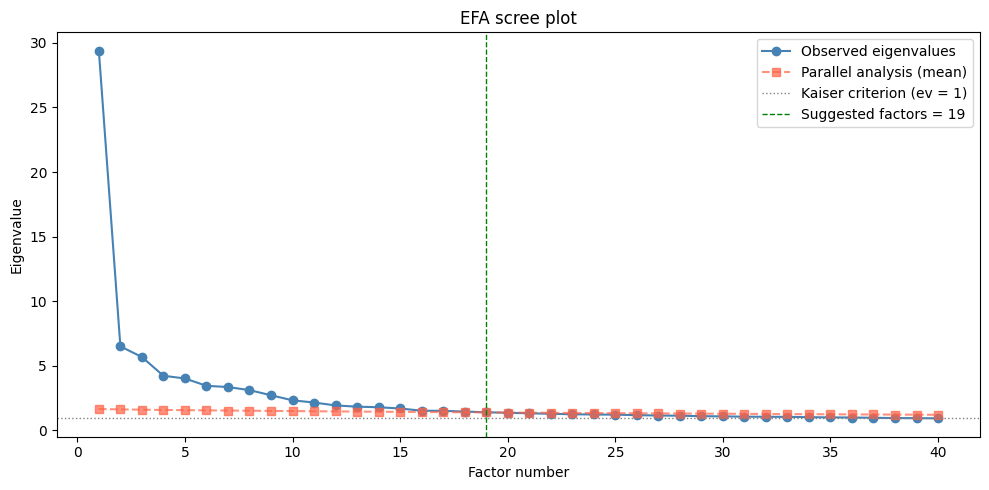

In [ ]:
# efa_elbow_plot imported from src.visualization.plots
efa_elbow_plot(irt_aug_X, max_factors=40)
plt.show()


In [ ]:
# factors from dataset
fa_var = FactorAnalyzer(n_factors=19, rotation="varimax")
fa_quartimax = FactorAnalyzer(n_factors=19, rotation="quartimax")
fa_var.fit(irt_aug_X)
fa_quartimax.fit(irt_aug_X)

_factor_cols = [f"Factor_{i+1}" for i in range(19)]
fa_var_loadings = pd.DataFrame(
    fa_var.loadings_, index=irt_aug_X.columns, columns=_factor_cols
)
fa_quartimax_loadings = pd.DataFrame(
    fa_quartimax.loadings_, index=irt_aug_X.columns, columns=_factor_cols
)

In [ ]:
top_n = 5

top_var = {
    f"Varimax_{i+1}": fa_var_loadings[f"Factor_{i+1}"].abs().nlargest(top_n).index.tolist()
    for i in range(19)
}
top_quartimax = {
    f"Quartimax_{i+1}": fa_quartimax_loadings[f"Factor_{i+1}"].abs().nlargest(top_n).index.tolist()
    for i in range(19)
}

print("Top features per factor — Varimax")
display(
    pd.DataFrame(top_var, index=[f"#{i+1}" for i in range(top_n)])
    .style.set_properties(**{"text-align": "left", "white-space": "nowrap"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
)

print("\nTop features per factor — Quartimax")
display(
    pd.DataFrame(top_quartimax, index=[f"#{i+1}" for i in range(top_n)])
    .style.set_properties(**{"text-align": "left", "white-space": "nowrap"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
)


Top features per factor — Varimax


,Varimax_1,Varimax_2,Varimax_3,Varimax_4,Varimax_5,Varimax_6,Varimax_7,Varimax_8,Varimax_9,Varimax_10,Varimax_11,Varimax_12,Varimax_13,Varimax_14,Varimax_15,Varimax_16,Varimax_17,Varimax_18,Varimax_19
#1,theta_fatigue,theta_anxiety,ess_chance_of_dozing_inactive_public,diff_staying_asleep_isi,theta_nasal_obstruction,sleep_affected_your_social_life_isq,map_index_1_apnea_score,age,family_history_of_depression_mdhx,feel_sleep_not_sound_isq,map_index_4_narcolepsy_like_symptoms_score,theta_osa_symptoms,bmi,rmeq_total_score,dream_recall_frequency_rarely_or_never,sex,latency_sw,ess_chance_of_dozing_lying_down_in_afternoon_when_circumstances_permit,little_interest_or_pleasure_freq_phq
#2,fati_interferes_with_phys_function_fss,not_able_to_control_worrying_freq_gad,ess_chance_of_dozing_sitting_quietly_after_lunch_without_alcohol,troub_slp_nose,troub_brth_nose,sleep_affected_other_important_parts_of_life_isq,snorting_gasping_map,hypercholesterolemia_mdhx,family_history_of_psychiatric_treatment_mdhx,difficulty_staying_asleep_isq,hh_frequency_score,heavy_sweat_during_sleep_freq,map_score,usual_nap_duration,dream_recall_frequency_infrequent,ess_chance_of_dozing_tv,diff_falling_asleep_isi,difficulty_operating_motor_vehicles_for_short_distances_fosq,feel_depressed_freq_phq
#3,fati_causes_freq_probs_for_me_fss,worry_too_much_diff_things_freq_gad,map_index_3_excessive_daytime_sleepiness_,how_satisfied_with_curr_sleep_pattern_isi,nasal_blockage_obstr_nose,sleep_affected_work_isq,breathing_stops_map,medical_problem_or_surgery_other_mdhx,family_history_of_anxiety_mdhx,multiple_awakenings_isq,sleep_paralysis_frequency_score,dry_irritated_eyes_freq,map_likelihood_ration,age,never_smoked,map_score,diff_falling_asleep_isq,frequent_naps,theta_depression
#4,fati_top_three_disabling_sympts_fss,feeling_anxious_freq_gad,ess_chance_of_dozing_in_a_car_while_stopped_for_few_minutes_in_traffic,diff_falling_asleep_isi,nasal_congestion_stuffiness_nose,sleep_caused_trouble_concentrating_isq,loud_snoring_map,hypertension_mdhx,family_history_of_other_psychiatric_illness_mdhx,feel_sleep_unrefreshing_isq,fall_asleep_driving_map,heartburn_belching_after_bed_freq,hypertension_mdhx,map_index_3_excessive_daytime_sleepiness_,frequent_naps,morning_headache_map,how_satisfied_with_curr_sleep_pattern_isi,difficulty_operating_motor_vehicles_for_long_distances_fosq,feel_bad_abt_yourself_freq_phq
#5,fati_prevents_sustained_phys_func_fss,trouble_relaxing_freq_gad,ess_chance_of_dozing_car_passenger_hr,diff_falling_asleep_isq,not_enough_air_excercise_nose,sleep_made_you_irritable_isq,map_score,gastrointestinal_problem_or_surgery_mdhx,family_history_of_insomnia_mdhx,sleep_made_you_fatigued_isq,map_index_3_excessive_daytime_sleepiness_,gastrointestinal_problem_or_surgery_mdhx,exercise_amt_or_time,excessive_sleepiness_map,frequent_daytime_sleepiness,ess_chance_of_dozing_car_passenger_hr,hrs_awake_night_sw,ess_chance_of_dozing_sitting_and_reading,difficulty_visiting_family_or_friends_in_their_home_fosq



Top features per factor — Quartimax


,Quartimax_1,Quartimax_2,Quartimax_3,Quartimax_4,Quartimax_5,Quartimax_6,Quartimax_7,Quartimax_8,Quartimax_9,Quartimax_10,Quartimax_11,Quartimax_12,Quartimax_13,Quartimax_14,Quartimax_15,Quartimax_16,Quartimax_17,Quartimax_18,Quartimax_19
#1,theta_fatigue,theta_anxiety,diff_staying_asleep_isi,ess_chance_of_dozing_inactive_public,theta_nasal_obstruction,map_index_1_apnea_score,feel_sleep_not_sound_isq,age,family_history_of_psychiatric_treatment_mdhx,map_index_4_narcolepsy_like_symptoms_score,theta_osa_symptoms,sleep_affected_your_social_life_isq,bmi,dream_recall_frequency_rarely_or_never,sex,feel_depressed_freq_phq,how_satisfied_with_curr_sleep_pattern_isi,rmeq_total_score,difficulty_operating_motor_vehicles_for_short_distances_fosq
#2,fati_causes_freq_probs_for_me_fss,worry_too_much_diff_things_freq_gad,diff_falling_asleep_isi,ess_chance_of_dozing_sitting_quietly_after_lunch_without_alcohol,troub_brth_nose,snorting_gasping_map,difficulty_staying_asleep_isq,hypercholesterolemia_mdhx,family_history_of_depression_mdhx,hh_frequency_score,heavy_sweat_during_sleep_freq,sleep_affected_other_important_parts_of_life_isq,map_score,dream_recall_frequency_infrequent,endocrine_or_metabolic_problem_mdhx,little_interest_or_pleasure_freq_phq,how_noticeable_is_sleep_problem_impacting_quality_of_life_isi,ess_chance_of_dozing_tv,difficulty_operating_motor_vehicles_for_long_distances_fosq
#3,fati_interferes_with_work_fam_social_fss,not_able_to_control_worrying_freq_gad,diff_falling_asleep_isq,ess_chance_of_dozing_in_a_car_while_stopped_for_few_minutes_in_traffic,nasal_blockage_obstr_nose,breathing_stops_map,multiple_awakenings_isq,hypertension_mdhx,family_history_of_anxiety_mdhx,sleep_paralysis_frequency_score,dry_irritated_eyes_freq,sleep_affected_work_isq,map_likelihood_ration,never_smoked,gastrointestinal_problem_or_surgery_mdhx,feel_bad_abt_yourself_freq_phq,sleep_problem_intereferes_with_daily_functioning_isi,map_index_3_excessive_daytime_sleepiness_,ess_chance_of_dozing_lying_down_in_afternoon_when_circumstances_permit
#4,fati_interferes_with_responsibilities_fss,feeling_anxious_freq_gad,troub_slp_nose,ess_chance_of_dozing_car_passenger_hr,nasal_congestion_stuffiness_nose,loud_snoring_map,feel_sleep_unrefreshing_isq,cardiovascular_problem_other_mdhx,family_history_of_other_psychiatric_illness_mdhx,fall_asleep_driving_map,heartburn_belching_after_bed_freq,sleep_made_you_irritable_isq,hypertension_mdhx,frequent_naps,map_score,theta_depression,exercise_brings_fati_fss,difficulty_watching_a_movie_fosq,frequent_naps
#5,fati_top_three_disabling_sympts_fss,trouble_relaxing_freq_gad,latency_sw,ess_chance_of_dozing_sitting_and_reading,not_enough_air_excercise_nose,map_score,sleep_made_you_fatigued_isq,medical_problem_or_surgery_other_mdhx,family_history_of_insomnia_mdhx,map_index_3_excessive_daytime_sleepiness_,gastrointestinal_problem_or_surgery_mdhx,sleep_caused_trouble_concentrating_isq,exercise_amt_or_time,frequent_daytime_sleepiness,dental_problems_mdhx,thought_you_would_be_better_dead_freq_phq,never_feel_rested,usual_nap_duration,ess_chance_of_dozing_in_a_car_while_stopped_for_few_minutes_in_traffic


In [ ]:
# ── Varimax vs Quartimax loading comparison ───────────────────────────────────
# Note: factor *ordering* can differ between rotations, so raw element-wise
# diffs (col 1 vs col 1) may mix different factors. The safest comparisons are:
#   (a) per-feature primary factor assignment (rotation-agnostic)
#   (b) per-feature max |loading| — how concentrated is each feature?

# (a) primary factor assignment per rotation
var_primary = fa_var_loadings.abs().idxmax(axis=1)
qmax_primary = fa_quartimax_loadings.abs().idxmax(axis=1)

reassigned = var_primary[var_primary != qmax_primary]
reassignment_df = pd.DataFrame({
    "varimax_primary":    var_primary[reassigned.index],
    "varimax_peak_load":  fa_var_loadings.abs().max(axis=1)[reassigned.index].round(3),
    "quartimax_primary":  qmax_primary[reassigned.index],
    "quartimax_peak_load": fa_quartimax_loadings.abs().max(axis=1)[reassigned.index].round(3),
}).sort_values("varimax_peak_load", ascending=False)

"""
print(f"{len(reassigned)} / {len(var_primary)} features change primary factor between rotations\n")
display(
    reassignment_df.style
    .set_caption("Features with different primary factor under Varimax vs Quartimax")
    .set_properties(**{"text-align": "left"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
)
"""
# (b) per-feature: how much does the peak loading change?
peak_diff = (
    fa_var_loadings.abs().max(axis=1) - fa_quartimax_loadings.abs().max(axis=1)
).rename("peak_loading_diff").sort_values(key=abs, ascending=False)

print("\nTop 20 features by absolute change in peak loading (Varimax − Quartimax):")
display(
    peak_diff.head(20).to_frame()
    .assign(
        varimax_peak=fa_var_loadings.abs().max(axis=1),
        quartimax_peak=fa_quartimax_loadings.abs().max(axis=1),
    )
    .round(3)
    .style.background_gradient(subset=["peak_loading_diff"], cmap="RdBu", vmin=-0.3, vmax=0.3)
    .set_properties(**{"text-align": "right"})
)

"""# (c) heatmap of element-wise absolute diff (acknowledges ordering caveat)
diff_abs = (fa_var_loadings - fa_quartimax_loadings).abs()

fig, ax = plt.subplots(figsize=(14, max(6, len(diff_abs) * 0.18)))
im = ax.imshow(diff_abs.values, aspect="auto", cmap="Oranges", vmin=0, vmax=0.5)
ax.set_xticks(range(len(_factor_cols)))
ax.set_xticklabels(_factor_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(diff_abs)))
ax.set_yticklabels(diff_abs.index, fontsize=7)
ax.set_title("|Varimax loading − Quartimax loading|  (element-wise; factor ordering may differ)")
plt.colorbar(im, ax=ax, label="|Δ loading|")
plt.tight_layout()
plt.show()
"""


Top 20 features by absolute change in peak loading (Varimax − Quartimax):


,peak_loading_diff,varimax_peak,quartimax_peak
how_worried_about_current_sleep_problem_isi,-0.207000,0.441000,0.648000
how_noticeable_is_sleep_problem_impacting_quality_of_life_isi,-0.203000,0.539000,0.742000
excessive_sleepiness_map,-0.197000,0.456000,0.652000
theta_depression,-0.192000,0.590000,0.782000
how_sleepy_do_you_feel_during_the_day_isq,-0.191000,0.488000,0.680000
difficulty_visiting_family_or_friends_in_their_home_fosq,-0.185000,0.404000,0.589000
relationships_with_family_or_friends_affected_fosq,-0.181000,0.501000,0.682000
trouble_focusing_freq_phq,-0.181000,0.463000,0.644000
difficulty_concentrating_fosq,-0.179000,0.587000,0.766000
difficulty_remembering_fosq,-0.177000,0.555000,0.732000


'# (c) heatmap of element-wise absolute diff (acknowledges ordering caveat)\ndiff_abs = (fa_var_loadings - fa_quartimax_loadings).abs()\n\nfig, ax = plt.subplots(figsize=(14, max(6, len(diff_abs) * 0.18)))\nim = ax.imshow(diff_abs.values, aspect="auto", cmap="Oranges", vmin=0, vmax=0.5)\nax.set_xticks(range(len(_factor_cols)))\nax.set_xticklabels(_factor_cols, rotation=45, ha="right", fontsize=8)\nax.set_yticks(range(len(diff_abs)))\nax.set_yticklabels(diff_abs.index, fontsize=7)\nax.set_title("|Varimax loading − Quartimax loading|  (element-wise; factor ordering may differ)")\nplt.colorbar(im, ax=ax, label="|Δ loading|")\nplt.tight_layout()\nplt.show()\n'

## Confirmatory Factor Analysis (CFA)

Verify the 19-factor Varimax structure on the IRT-augmented dataset using CFA. Each observed variable is constrained to load on exactly one latent factor — the one with its highest absolute Varimax loading — cross-loadings are fixed to zero.

Analyses:
1. **Model fit + loadings** — fit the CFA, inspect AIC/BIC, and visualise the block-diagonal loading heatmap
2. **EFA vs CFA loading comparison** — quantify how much the orthogonality constraint tightens each variable's peak loading
3. **Global fit indices** — RMSEA, CFI, SRMR computed from the ML discrepancy function; assess whether the imposed structure is adequate
4. **Residual correlations** — heatmap and table of (observed − model-implied) correlations; large off-diagonal values flag missing cross-loadings
5. **Per-factor reliability** — Cronbach's α and McDonald's ω (composite reliability) for each factor's item set

In [ ]:
# ── derive factor assignments from Varimax EFA on IRT-augmented data ─────────
var_factor_assignments = fa_var_loadings.abs().idxmax(axis=1)  # feature → "Factor_N"

irt_model_dict = {}
for factor_name in fa_var_loadings.columns:
    assigned = var_factor_assignments[var_factor_assignments == factor_name].index.tolist()
    if assigned:
        irt_model_dict[factor_name] = assigned

irt_model_spec = ModelSpecificationParser.parse_model_specification_from_dict(
    irt_aug_X, irt_model_dict
)

irt_cfa = ConfirmatoryFactorAnalyzer(irt_model_spec, disp=False, max_iter=1000)
irt_cfa.fit(irt_aug_X.values)

print(f"CFA fitted: {len(irt_model_dict)} factors over {irt_aug_X.shape[1]} variables")
print(f"Free loading parameters : {sum(len(v) for v in irt_model_dict.values())} (one per variable, no cross-loadings)")
print(f"\nLog-likelihood : {irt_cfa.log_likelihood_:.2f}")
print(f"AIC            : {irt_cfa.aic_:.2f}")
print(f"BIC            : {irt_cfa.bic_:.2f}")

CFA fitted: 18 factors over 151 variables
Free loading parameters : 151 (one per variable, no cross-loadings)

Log-likelihood : -506415.45
AIC            : 1019212.89
BIC            : 1036542.28


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/factor_analyzer/confirmatory_factor_analyzer.py:753: UserWarning: The optimization routine failed to converge: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
  warnings.warn(


In [ ]:
irt_cfa_loadings = pd.DataFrame(
    irt_cfa.loadings_,
    index=irt_aug_X.columns,
    columns=list(irt_model_dict.keys()),
)

# sort features by factor assignment → block-diagonal structure in heatmap
irt_sort_order = var_factor_assignments.map({col: i for i, col in enumerate(fa_var_loadings.columns)})
irt_sorted_features = irt_sort_order.sort_values().index
irt_cfa_loadings_sorted = irt_cfa_loadings.loc[irt_sorted_features]

"""fig, ax = plt.subplots(figsize=(18, max(10, len(irt_aug_X.columns) // 3)))
sns.heatmap(
    irt_cfa_loadings_sorted,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2,
    ax=ax,
)
ax.set_title("CFA Factor Loadings — IRT-augmented dataset (Varimax-informed structure, features sorted by factor)")
ax.set_xlabel("Factor")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()"""

'fig, ax = plt.subplots(figsize=(18, max(10, len(irt_aug_X.columns) // 3)))\nsns.heatmap(\n    irt_cfa_loadings_sorted,\n    cmap="coolwarm",\n    center=0,\n    vmin=-1,\n    vmax=1,\n    linewidths=0.2,\n    ax=ax,\n)\nax.set_title("CFA Factor Loadings — IRT-augmented dataset (Varimax-informed structure, features sorted by factor)")\nax.set_xlabel("Factor")\nax.set_ylabel("Feature")\nplt.tight_layout()\nplt.show()'

In [ ]:
# ── EFA Varimax vs CFA peak loading comparison ────────────────────────────────
efa_var_peaks = fa_var_loadings.abs().max(axis=1).rename("efa_varimax_peak")
irt_cfa_peaks = irt_cfa_loadings.abs().max(axis=1).rename("cfa_peak")

comparison = pd.concat([efa_var_peaks, irt_cfa_peaks], axis=1)
comparison["delta"] = (comparison["cfa_peak"] - comparison["efa_varimax_peak"]).round(3)

print(f"Mean |Δ| peak loading (EFA → CFA): {comparison['delta'].abs().mean():.4f}")
print(f"Max  |Δ| peak loading:             {comparison['delta'].abs().max():.4f}")
print("\nTop 20 features by absolute change in peak loading (Varimax EFA − CFA):")
display(
    comparison
    .reindex(comparison["delta"].abs().sort_values(ascending=False).index)
    .head(20)
    .round(3)
    .style.background_gradient(subset=["delta"], cmap="RdBu", vmin=-0.4, vmax=0.4)
    .set_properties(**{"text-align": "right"})
)

Mean |Δ| peak loading (EFA → CFA): 0.4757
Max  |Δ| peak loading:             0.9120

Top 20 features by absolute change in peak loading (Varimax EFA − CFA):


,efa_varimax_peak,cfa_peak,delta
sw_5pm_end_diff,0.103000,1.015000,0.912000
daily_caffeine_servings,0.112000,1.013000,0.901000
trigger_for_slp_disorder_mdhx,0.112000,0.989000,0.877000
sw_9am_start_diff,0.131000,0.997000,0.866000
family_history_of_narcolepsy_mdhx,0.118000,0.977000,0.859000
congestive_heart_failure_mdhx,0.155000,0.972000,0.817000
eating_impact_alertness,0.173000,0.972000,0.799000
genetic_testing_mdhx,0.183000,0.981000,0.798000
family_history_of_other_sleep_disorder_mdhx,0.194000,0.988000,0.794000
asthma_mdhx,0.207000,0.988000,0.781000


In [ ]:
from src.modeling.cfa_utils import cfa_fit_indices, mardia_sb_scale, print_fit_indices

_fi = cfa_fit_indices(irt_cfa)

# ── unpack for downstream cells (freed residuals, INT comparison) ──────────────
chi2       = _fi["chi2"]
df         = _fi["df"]
chi2_null  = _fi["chi2_null"]
df_null    = _fi["df_null"]
rmsea      = _fi["rmsea"]
cfi        = _fi["cfi"]
srmr       = _fi["srmr"]
R_obs      = _fi["R_obs"]
R_res      = _fi["R_res"]
lt_i       = _fi["lt_i"]
lt_j       = _fi["lt_j"]
p_vars     = _fi["n_vars"]

print_fit_indices(_fi, label="IRT-augmented, 19-factor Varimax-informed structure")
print(f"  AIC = {irt_cfa.aic_:.1f}   BIC = {irt_cfa.bic_:.1f}")


CFA Global Fit Indices — IRT-augmented, 19-factor Varimax-informed structure
  χ²(11021) =  581782.52   (χ²/df = 52.79)
  RMSEA      = 0.1752   (good ≤ 0.06, acceptable ≤ 0.08)
  CFI        = 0.0000   (good ≥ 0.95)
  SRMR       = 1.6093   (good ≤ 0.08)

  n_obs = 1687   p = 151   df = 11021   n_free = 455
  AIC = 1019212.9   BIC = 1036542.3


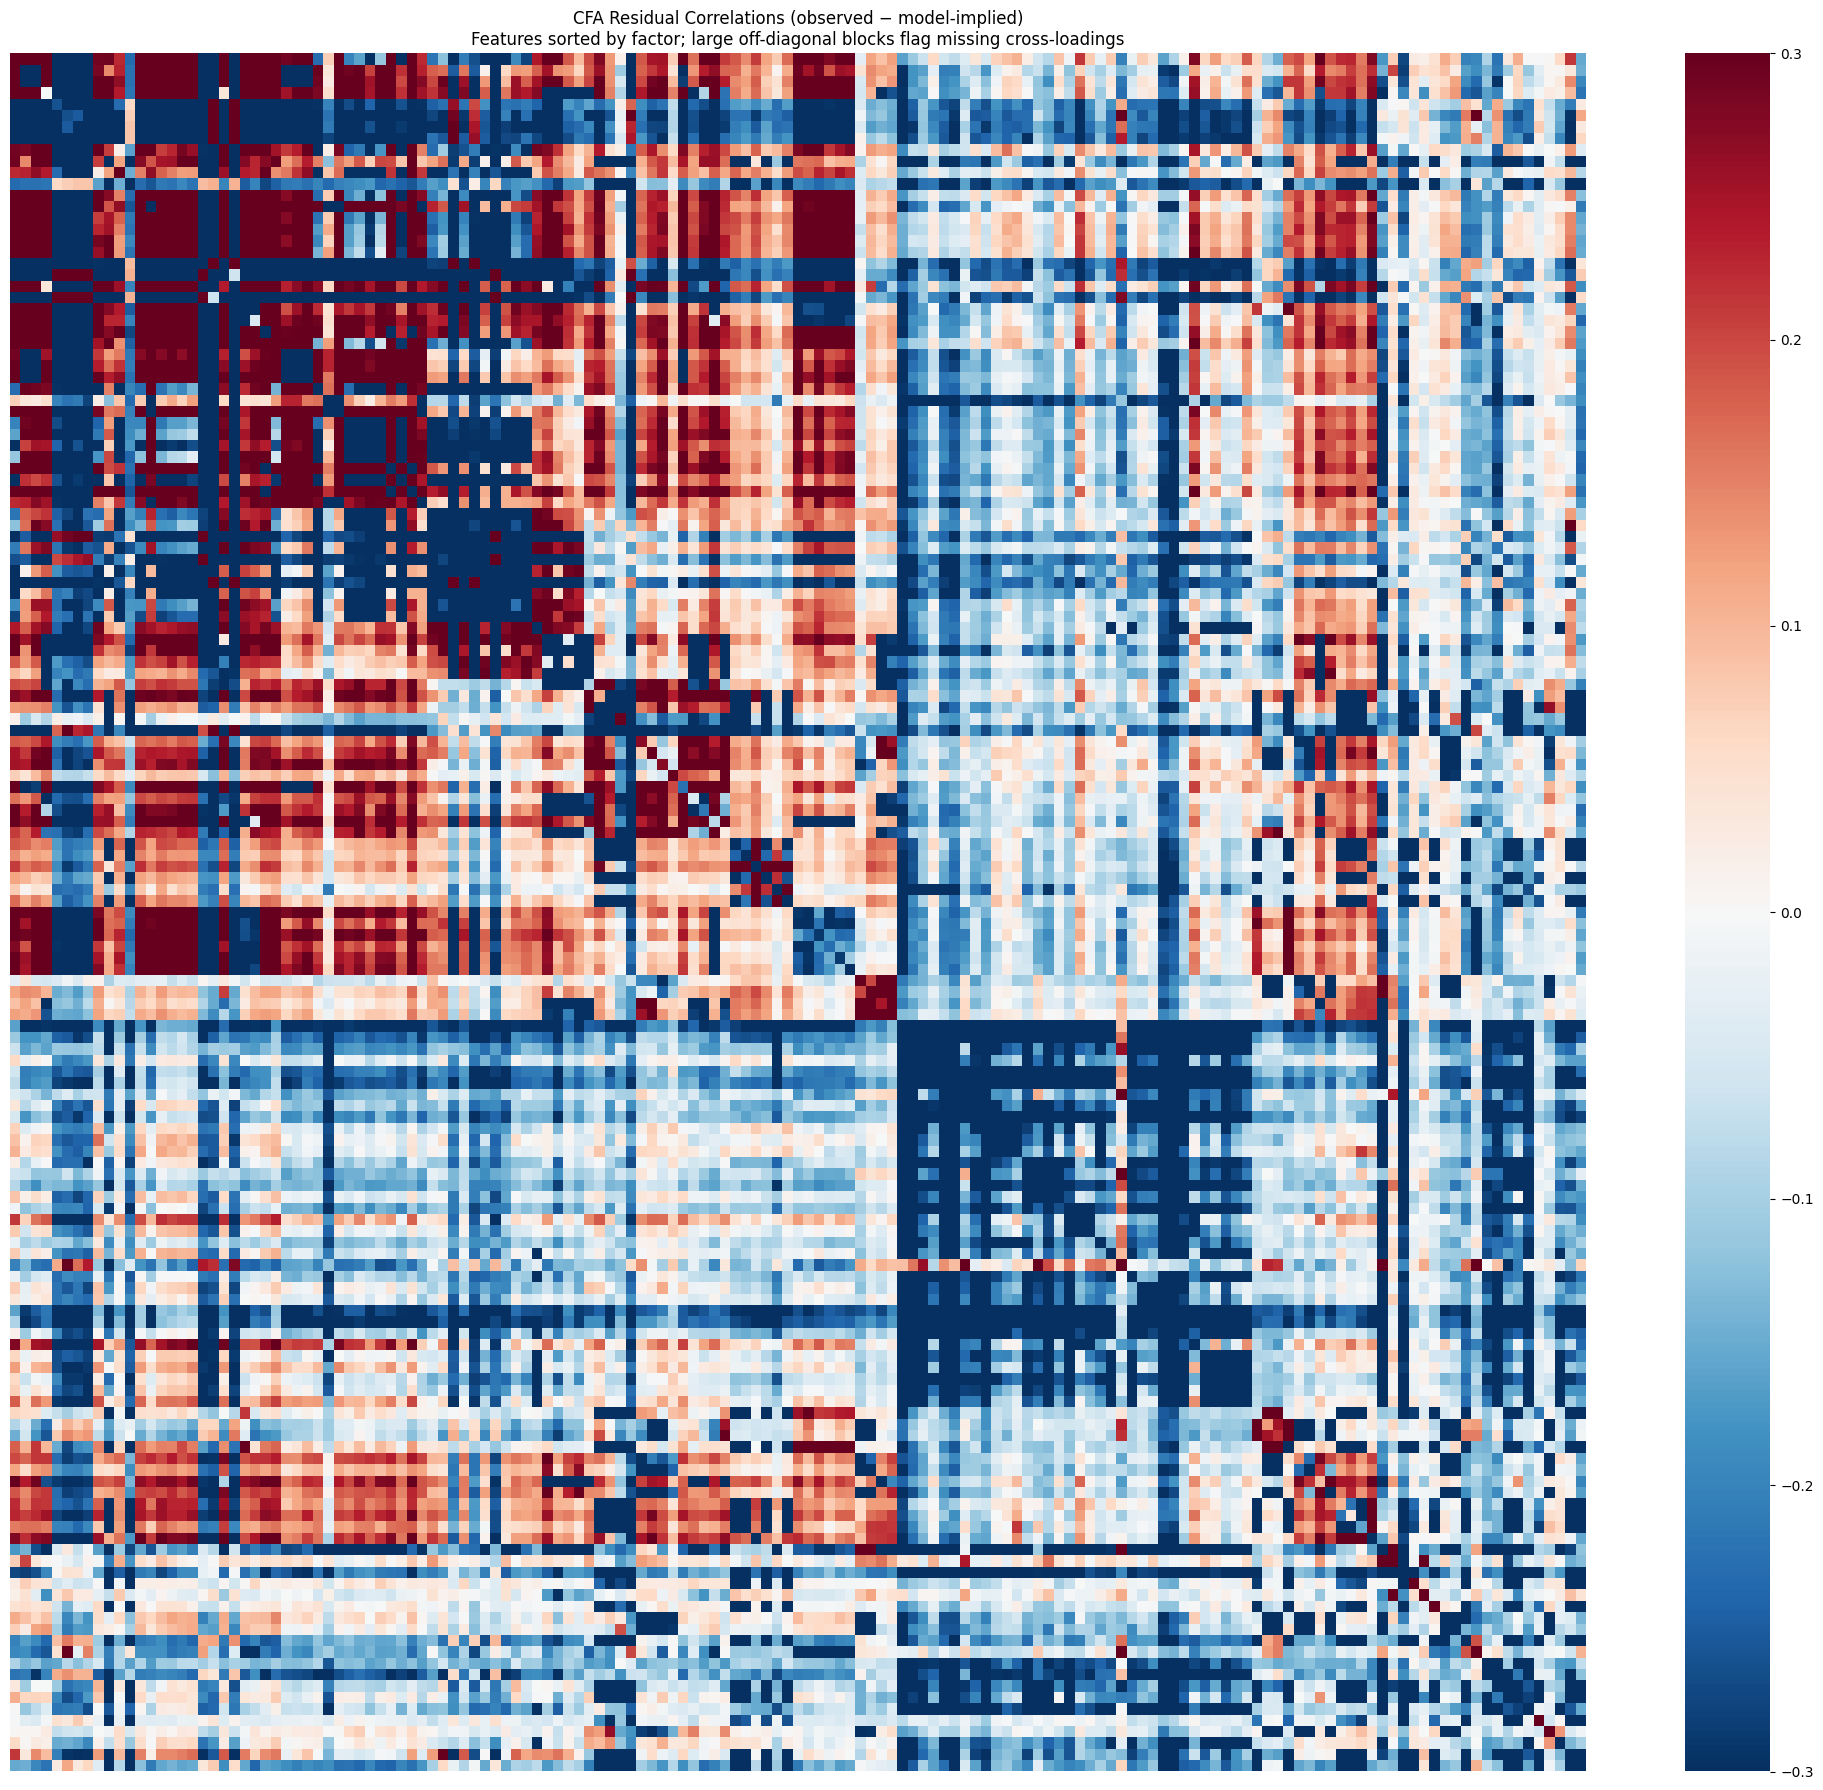

Off-diagonal residual correlations |r| > 0.10: 7053 / 11325 pairs  (62.3%)


,var1,var2,resid_r
10294,oophorectomy_bilateral_mdhx,congestive_heart_failure_mdhx,-32.055
9590,chronic_obstructive_pulmonary_disease_mdhx,pulmonary_problem_other_mdhx,-25.144
7500,genetic_testing_mdhx,family_history_of_narcolepsy_mdhx,-19.996
6902,family_history_of_other_sleep_disorder_mdhx,family_history_of_sleepwalking_mdhx,-19.558
6898,family_history_of_other_sleep_disorder_mdhx,family_history_of_other_psychiatric_illness_mdhx,-19.077
6895,family_history_of_other_sleep_disorder_mdhx,trigger_for_slp_disorder_mdhx,-18.387
7020,family_history_of_restless_leg_syndrome_mdhx,family_history_of_other_sleep_disorder_mdhx,-17.051
6901,family_history_of_other_sleep_disorder_mdhx,family_history_of_fibromyalgia_or_chronic_fati...,-16.567
7379,family_history_of_insomnia_mdhx,family_history_of_narcolepsy_mdhx,-16.346
9867,cardiovascular_problem_other_mdhx,pulmonary_problem_other_mdhx,-15.634


In [ ]:
# ── Residual correlation heatmap ──────────────────────────────────────────────
# R_res defined in the fit-indices cell above; irt_sorted_features from heatmap cell
R_resid_df     = pd.DataFrame(R_res, index=irt_aug_X.columns, columns=irt_aug_X.columns)
R_resid_sorted = R_resid_df.loc[irt_sorted_features, irt_sorted_features]

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    R_resid_sorted,
    cmap="RdBu_r",
    center=0,
    vmin=-0.3,
    vmax=0.3,
    linewidths=0,
    ax=ax,
    xticklabels=False,
    yticklabels=False,
)
ax.set_title(
    "CFA Residual Correlations (observed − model-implied)\n"
    "Features sorted by factor; large off-diagonal blocks flag missing cross-loadings"
)
plt.tight_layout()
plt.show()

# ── table: worst off-diagonal residuals ───────────────────────────────────────
cols_       = list(irt_aug_X.columns)
lt_i_off, lt_j_off = np.tril_indices(p_vars, k=-1)   # strictly lower triangle
pairs_ = [(cols_[i], cols_[j], R_res[i, j]) for i, j in zip(lt_i_off, lt_j_off)]
resid_pairs = (
    pd.DataFrame(pairs_, columns=["var1", "var2", "resid_r"])
    .assign(abs_resid=lambda d: d["resid_r"].abs())
    .sort_values("abs_resid", ascending=False)
)
n_large = (resid_pairs["abs_resid"] > 0.10).sum()
print(f"Off-diagonal residual correlations |r| > 0.10: {n_large} / {len(resid_pairs)} pairs  "
      f"({n_large / len(resid_pairs) * 100:.1f}%)")
display(resid_pairs[resid_pairs["abs_resid"] > 0.10].drop(columns="abs_resid").head(20).round(3))

## Item pruning: keep top-N loaders per factor

With n=131 every extra variable costs degrees of freedom directly. Dropping weak indicators (h² < 0.30) and keeping only the strongest 2–3 items per factor reduces χ² without removing real structure.

In [ ]:
# ── Item pruning: keep top-N strongest loaders per factor ─────────────────────
TOP_PER_FACTOR   = 2     # max items retained per factor
H2_MIN           = 0.30  # drop items with communality below this threshold

# communalities from the baseline Varimax CFA
h2 = pd.Series(
    (irt_cfa.loadings_ ** 2).sum(axis=1),
    index=irt_aug_X.columns,
    name="h2",
)
n_low_h2 = (h2 < H2_MIN).sum()
print(f"Items with h² < {H2_MIN}: {n_low_h2} / {len(h2)}")
print(f"  → {h2[h2 < H2_MIN].sort_values().round(3).to_dict()}")

# per factor: keep top-N by |loading| among items that pass the h² threshold
pruned_model_dict = {}
dropped = []
for factor_name, items in irt_model_dict.items():
    # peak loading for each item on its assigned factor
    col_idx  = list(irt_model_dict.keys()).index(factor_name)
    loadings = pd.Series(
        np.abs(irt_cfa.loadings_[:, col_idx]),
        index=irt_aug_X.columns,
    )
    candidates = [v for v in items if h2[v] >= H2_MIN]
    kept = (
        loadings[candidates]
        .sort_values(ascending=False)
        .head(TOP_PER_FACTOR)
        .index.tolist()
    )
    removed = [v for v in items if v not in kept]
    if kept:
        pruned_model_dict[factor_name] = kept
    dropped.extend(removed)

p_pruned   = sum(len(v) for v in pruned_model_dict.values())
k_pruned   = len(pruned_model_dict)
print(f"\nPruned model: {k_pruned} factors, {p_pruned} items  "
      f"(dropped {len(dropped)} of {len(irt_aug_X.columns)})")

# ── refit CFA on pruned item set ───────────────────────────────────────────────
pruned_cols   = [v for vlist in pruned_model_dict.values() for v in vlist]
irt_aug_X_pr  = irt_aug_X[pruned_cols]

pruned_spec   = ModelSpecificationParser.parse_model_specification_from_dict(
    irt_aug_X_pr, pruned_model_dict
)
irt_cfa_pr    = ConfirmatoryFactorAnalyzer(pruned_spec, disp=False, max_iter=1000)
irt_cfa_pr.fit(irt_aug_X_pr.values)

# ── fit indices for pruned model ──────────────────────────────────────────────
_fi_pr   = cfa_fit_indices(irt_cfa_pr)
rmsea_pr = _fi_pr["rmsea"]
cfi_pr   = _fi_pr["cfi"]
srmr_pr  = _fi_pr["srmr"]

print("\nFit index comparison — Full Varimax vs Pruned CFA")
print("=" * 65)
print(f"\n{'Index':<8}  {'Full':>10}  {'Pruned':>10}  {'Δ':>10}")
print("-" * 50)
print(f"{'RMSEA':<8}  {rmsea:>10.4f}  {rmsea_pr:>10.4f}  {rmsea_pr - rmsea:>+10.4f}")
print(f"{'CFI':<8}  {cfi:>10.4f}  {cfi_pr:>10.4f}  {cfi_pr - cfi:>+10.4f}")
print(f"{'SRMR':<8}  {srmr:>10.4f}  {srmr_pr:>10.4f}  {srmr_pr - srmr:>+10.4f}")
print(f"\n  Variables : {len(irt_aug_X.columns):>4d}  →  {_fi_pr['n_vars']:>4d}")
print(f"  df        : {df:>4d}  →  {_fi_pr['df']:>4d}")
print(f"  AIC       : {irt_cfa.aic_:>10.1f}  →  {irt_cfa_pr.aic_:>10.1f}")
print(f"  BIC       : {irt_cfa.bic_:>10.1f}  →  {irt_cfa_pr.bic_:>10.1f}")


Items with h² < 0.3: 0 / 151
  → {}

Pruned model: 18 factors, 35 items  (dropped 116 of 151)

Fit index comparison — Full Varimax vs Pruned CFA

Index           Full      Pruned           Δ
--------------------------------------------------
RMSEA         0.1752      0.1974     +0.0222
CFI           0.0000      0.0000     +0.0000
SRMR          1.6093      0.2744     -1.3349

  Variables :  151  →    35
  df        : 11021  →   407
  AIC       :  1019212.9  →         nan
  BIC       :  1036542.3  →         nan


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/factor_analyzer/confirmatory_factor_analyzer.py:753: UserWarning: The optimization routine failed to converge: ABNORMAL: 
  warnings.warn(


## CFA with freed correlated residuals

`factor_analyzer` does not support off-diagonal error covariances, so the refitted model is implemented via direct ML minimisation with `scipy`. Loadings and factor covariance (Φ = I, Varimax) are held fixed; only the error covariance matrix Θ gains free off-diagonal entries for the top residual pairs identified above.

In [ ]:
# ── CFA with freed correlated residuals ──────────────────────────────────────
# Selects the worst off-diagonal residual pairs from `resid_pairs`, adds them
# as free off-diagonal entries in Θ, then refits via scipy ML minimisation
# with the loading matrix (Λ) and factor covariances (Φ = I) held fixed.

RESID_FREE_THRESHOLD = 0.10  # |resid_r| cutoff — pairs above this are freed
MAX_FREED_PAIRS      = 20    # cap to avoid over-parameterisation

# ── select pairs to free ──────────────────────────────────────────────────────
freed_pairs_df = (
    resid_pairs[resid_pairs["abs_resid"] > RESID_FREE_THRESHOLD]
    .head(MAX_FREED_PAIRS)
)
_cols = list(irt_aug_X.columns)
freed_idxs = [
    (_cols.index(r.var1), _cols.index(r.var2))
    for _, r in freed_pairs_df.iterrows()
]
print(f"Freeing {len(freed_idxs)} error covariances  (|resid_r| > {RESID_FREE_THRESHOLD})")

# ── fixed quantities from the baseline Varimax CFA ───────────────────────────
Lambda_fix = irt_cfa.loadings_             # (p, k) — held fixed
Phi_fix    = np.eye(Lambda_fix.shape[1])   # orthogonal factors (Varimax)
S_fix      = irt_cfa.cov_
n_fix      = irt_cfa.n_obs
p_fix      = S_fix.shape[0]

# initial values: current error variances + residual-correlation-implied covs
err_var0 = irt_cfa.error_vars_.flatten().copy()
err_cov0 = np.array([
    R_res[i, j] * np.sqrt(S_fix[i, i] * S_fix[j, j])
    for i, j in freed_idxs
])
x0 = np.concatenate([err_var0, err_cov0])


def _build_theta(x):
    """Assemble Θ: diagonal error variances + freed off-diagonal covariances."""
    theta = np.diag(np.abs(x[:p_fix]))   # abs() keeps variances positive
    for k_idx, (i, j) in enumerate(freed_idxs):
        theta[i, j] = x[p_fix + k_idx]
        theta[j, i] = x[p_fix + k_idx]
    return theta


def _ml_loss(x):
    """ML discrepancy F = log|Σ| − log|S| + tr(Σ⁻¹ S) − p."""
    theta = _build_theta(x)
    Sigma = Lambda_fix @ Phi_fix @ Lambda_fix.T + theta
    sign, ld_Sig = np.linalg.slogdet(Sigma)
    if sign <= 0:
        return 1e10
    _, ld_S = np.linalg.slogdet(S_fix)
    return float(ld_Sig - ld_S + np.trace(np.linalg.inv(Sigma) @ S_fix) - p_fix)


result = minimize(
    _ml_loss,
    x0,
    method="L-BFGS-B",
    bounds=[(1e-6, None)] * p_fix + [(None, None)] * len(freed_idxs),
    options={"maxiter": 3000, "ftol": 1e-12},
)

# ── fit indices for the freed-residuals model ─────────────────────────────────
Theta_freed  = _build_theta(result.x)
Sigma_freed  = Lambda_fix @ Phi_fix @ Lambda_fix.T + Theta_freed
chi2_freed   = n_fix * result.fun

n_free_freed = n_free + len(freed_idxs)
df_freed     = p_fix * (p_fix + 1) // 2 - n_free_freed

rmsea_freed = np.sqrt(max(chi2_freed - df_freed, 0.0) / (n_fix * df_freed))
cfi_freed   = float(np.clip(
    1.0 - max(chi2_freed - df_freed, 0.0) / max(chi2_null - df_null, 1e-10),
    0.0, 1.0,
))
D_fr       = np.diag(1.0 / np.sqrt(np.diag(S_fix)))
R_mod_fr   = D_fr @ Sigma_freed @ D_fr
R_res_fr   = R_obs - R_mod_fr   # R_obs from the fit-indices cell
srmr_freed = np.sqrt(np.mean((R_res_fr[lt_i, lt_j]) ** 2))

print("\nFit index comparison — Varimax CFA vs freed-residuals CFA")
print("=" * 65)
print(f"\n{'Index':<8}  {'Varimax':>10}  {'Freed Θ':>10}  {'Δ':>10}")
print("-" * 50)
print(f"{'RMSEA':<8}  {rmsea:>10.4f}  {rmsea_freed:>10.4f}  {rmsea_freed - rmsea:>+10.4f}")
print(f"{'CFI':<8}  {cfi:>10.4f}  {cfi_freed:>10.4f}  {cfi_freed - cfi:>+10.4f}")
print(f"{'SRMR':<8}  {srmr:>10.4f}  {srmr_freed:>10.4f}  {srmr_freed - srmr:>+10.4f}")
print(f"\n  df        : {df:>8d}  →  {df_freed:>8d}  ({len(freed_idxs)} extra free params)")
print(f"  converged : {result.success}  ({result.message})")
print(f"\nFreed pairs:")
display(freed_pairs_df[["var1", "var2", "resid_r"]].round(3).reset_index(drop=True))


Freeing 20 error covariances  (|resid_r| > 0.1)


NameError: name 'n_free' is not defined

In [ ]:
# ── Per-factor reliability: Cronbach's α and McDonald's ω ────────────────────
# α: from observed sub-covariance matrix (scale-free reliability estimate)
# ω: composite reliability from CFA loadings + error variances
#    ω = (Σλ_i)² / ((Σλ_i)² + Σθ_i)   — proportion of factor-explained variance

S_obs_df  = pd.DataFrame(irt_cfa.cov_, index=irt_aug_X.columns, columns=irt_aug_X.columns)
err_vars  = irt_cfa.error_vars_.flatten()   # (n_variables,)
all_vars  = list(irt_aug_X.columns)
fac_names = list(irt_model_dict.keys())

rel_rows = []
for factor_name, items in irt_model_dict.items():
    k          = len(items)
    factor_idx = fac_names.index(factor_name)
    item_idxs  = [all_vars.index(v) for v in items]

    # Cronbach's α
    if k >= 2:
        S_sub     = S_obs_df.loc[items, items].values
        total_var = S_sub.sum()
        item_var  = np.diag(S_sub).sum()
        alpha = (k / (k - 1)) * (1 - item_var / total_var) if total_var > 0 else np.nan
    else:
        alpha = np.nan

    # McDonald's ω (composite reliability)
    lam       = irt_cfa.loadings_[item_idxs, factor_idx]   # (k,) loadings on this factor
    theta     = err_vars[item_idxs]                         # (k,) error variances
    sum_lam_sq = lam.sum() ** 2
    denom      = sum_lam_sq + theta.sum()
    omega      = float(sum_lam_sq / denom) if denom > 0 else np.nan

    rel_rows.append({
        "factor":         factor_name,
        "n_items":        k,
        "cronbach_alpha": round(float(alpha), 3) if not np.isnan(alpha) else np.nan,
        "mcdonald_omega": round(omega, 3) if not np.isnan(omega) else np.nan,
    })

rel_df = pd.DataFrame(rel_rows).sort_values("mcdonald_omega", ascending=False)

print("Per-factor reliability  (acceptable ≥ 0.70, good ≥ 0.80)")
display(
    rel_df.style
    .background_gradient(subset=["cronbach_alpha", "mcdonald_omega"], cmap="RdYlGn", vmin=0, vmax=1)
    .format({"cronbach_alpha": "{:.3f}", "mcdonald_omega": "{:.3f}"})
    .set_properties(**{"text-align": "right"})
)
print(f"\nMedian α = {rel_df['cronbach_alpha'].median():.3f}   "
      f"Median ω = {rel_df['mcdonald_omega'].median():.3f}")
print(f"Factors with ω < 0.70: {(rel_df['mcdonald_omega'] < 0.70).sum()} / {len(rel_df)}")

Per-factor reliability  (acceptable ≥ 0.70, good ≥ 0.80)


,factor,n_items,cronbach_alpha,mcdonald_omega
8,Factor_9,12,0.729,0.922
2,Factor_3,15,0.719,0.647
0,Factor_1,26,0.848,0.199
3,Factor_4,14,0.745,0.100
11,Factor_12,4,0.757,0.000
16,Factor_17,4,0.009,0.000
15,Factor_16,1,nan,0.000
14,Factor_15,3,-1.394,0.000
13,Factor_14,5,-0.362,0.000
12,Factor_13,5,0.386,0.000



Median α = 0.745   Median ω = 0.000
Factors with ω < 0.70: 17 / 18


In [ ]:
# ── CFA factor scores → dataset ───────────────────────────────────────────────
irt_cfa_scores = irt_cfa.transform(irt_aug_X.values)
_irt_cfa_cols  = list(irt_model_dict.keys())

irt_cfa_df = pd.DataFrame(irt_cfa_scores, index=irt_aug_X.index, columns=_irt_cfa_cols)
irt_cfa_df["ahi"] = irt_aug_df["ahi"].values

irt_cfa_dataset_path = "../../data/processed/mlflow/mlflow_irt_cfa_dataset_v1.csv"
irt_cfa_df.to_csv(irt_cfa_dataset_path, index=False)

irt_cfa_mlflow_ds = mlflow.data.from_pandas(
    irt_cfa_df, source=irt_cfa_dataset_path, name="irt_cfa_dataset_v1", targets="ahi"
)

irt_cfa_X = irt_cfa_df.drop(columns=["ahi"])
irt_cfa_y = convert_ahi(irt_cfa_df["ahi"], threshold=15)
irt_cfa_X_train, irt_cfa_test_X, irt_cfa_train_y, irt_cfa_test_y = train_test_split(
    irt_cfa_X, irt_cfa_y, test_size=0.2, random_state=42, stratify=irt_cfa_y
)

print(f"IRT-CFA factor scores dataset saved → {irt_cfa_dataset_path}")
print(f"Shape: {irt_cfa_df.shape}  ({len(_irt_cfa_cols)} CFA factor score cols)")
print(f"Train: {irt_cfa_X_train.shape}   Test: {irt_cfa_test_X.shape}")
display(irt_cfa_df.head())

IRT-CFA factor scores dataset saved → ../../data/processed/mlflow/mlflow_irt_cfa_dataset_v1.csv
Shape: (1687, 19)  (18 CFA factor score cols)
Train: (1349, 18)   Test: (338, 18)


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15,Factor_16,Factor_17,Factor_18,ahi
0,-0.035985,-0.119327,-0.319899,0.112377,0.657765,-0.437184,-0.038584,-0.144171,-0.158529,-0.170646,-0.280938,-0.172899,-0.255635,-0.163046,-0.132092,-0.292254,0.042470,-0.220729,0.3
1,-0.269670,-1.032645,-0.374181,0.475102,-1.695846,0.257965,-0.288199,0.564182,0.203455,0.334235,0.737152,-0.172899,-0.255635,-0.163046,-0.132092,0.758988,0.173210,-0.191596,0.4
2,-0.265498,0.243830,0.505065,0.818293,-0.010257,-0.925272,0.214737,-0.186480,-0.130857,-0.170646,-0.280938,-0.172899,0.352551,-0.163046,-0.132092,-0.292254,-0.102364,-0.330237,1.0
3,-0.055565,0.497297,-0.363268,-0.368785,-0.014422,-0.600052,1.234773,-0.874005,0.114302,-0.170646,0.226913,-0.172899,-0.054719,-0.163046,-0.132092,-0.292254,-0.119688,-0.158215,3.9
4,-0.257284,-0.617979,-0.522842,0.085575,-0.336464,-0.251583,-0.038584,-0.275592,0.182537,0.334235,-0.027190,-0.172899,-0.054848,0.035751,0.204968,-0.292254,0.189649,-0.219564,1.3


In [ ]:
irt_cfa_trials = [
    ("irt_augmented_full", irt_aug_mlflow_ds, irt_aug_X_train,  irt_aug_test_X,  irt_aug_train_y,  irt_aug_test_y),
    ("irt_cfa_factors",    irt_cfa_mlflow_ds, irt_cfa_X_train, irt_cfa_test_X,  irt_cfa_train_y, irt_cfa_test_y),
]

experiment_irt_cfa = _setup_experiment("dataset-comparison-irt-cfa-v1", {
    "description": "IRT-augmented CFA factor scores vs IRT-augmented full dataset — RF and HGB",
    "feature_engineering": "CFA-varimax-19-factors-irt",
})
_run_mlflow_trials(irt_cfa_trials, model_configs, log_shap=False)


dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------
irt_augmented_full         rf       0.651   0.600   0.289   0.460         151
irt_augmented_full         hgb      0.612   0.544   0.367   0.395         151
irt_cfa_factors            rf       0.624   0.541   0.314   0.393          18
irt_cfa_factors            hgb      0.598   0.560   0.419   0.391          18


## Oblique CFA — Promax rotation + freed cross-loadings

The simple-structure Varimax CFA constrains each variable to one factor and forces orthogonality. Two improvements:

1. **Promax rotation** (oblique) — refits the EFA allowing factors to correlate, giving factor assignments that reflect natural clinical clusters rather than enforcing independence
2. **Freed cross-loadings** — variables with a secondary Promax loading ≥ 0.32 are allowed to load on that factor too, reducing residual correlations

Expected effects: lower RMSEA/SRMR, higher CFI, and lower AIC (better likelihood per free parameter).

In [ ]:
# ── Promax EFA ────────────────────────────────────────────────────────────────
CROSS_THRESHOLD = 0.2   # |λ| cutoff for freeing secondary loadings

fa_promax = FactorAnalyzer(n_factors=19, rotation="promax")
fa_promax.fit(irt_aug_X)
fa_promax_loadings = pd.DataFrame(
    fa_promax.loadings_, index=irt_aug_X.columns, columns=_factor_cols
)

# ── build loading indicator matrix: primary always free; secondary freed if ≥ threshold
loadings_mask = (fa_promax_loadings.abs() >= CROSS_THRESHOLD).astype(int).values
primary_fac_idx = fa_promax_loadings.abs().values.argmax(axis=1)
for var_i, fac_j in enumerate(primary_fac_idx):
    loadings_mask[var_i, fac_j] = 1      # guarantee primary is always free

n_cross = int(loadings_mask.sum()) - irt_aug_X.shape[1]
print(f"Promax structure: {n_cross} cross-loadings freed (|λ| ≥ {CROSS_THRESHOLD})")
print(f"Total free loading params: {int(loadings_mask.sum())}  "
      f"(simple structure had {irt_aug_X.shape[1]})")

# ── fit oblique CFA ────────────────────────────────────────────────────────────
promax_spec = ModelSpecification(
    loadings=loadings_mask,
    n_factors=19,
    n_variables=irt_aug_X.shape[1],
    factor_names=_factor_cols,
    variable_names=list(irt_aug_X.columns),
)

irt_cfa_oblique = ConfirmatoryFactorAnalyzer(promax_spec, disp=False, max_iter=2000)
irt_cfa_oblique.fit(irt_aug_X.values)

print(f"\n{'Model':<38}  {'Log-lik':>12}  {'AIC':>12}  {'BIC':>12}")
print("-" * 78)
print(f"{'Varimax simple-structure CFA':<38}  {irt_cfa.log_likelihood_:>12.2f}  "
      f"{irt_cfa.aic_:>12.1f}  {irt_cfa.bic_:>12.1f}")
print(f"{'Promax oblique CFA':<38}  {irt_cfa_oblique.log_likelihood_:>12.2f}  "
      f"{irt_cfa_oblique.aic_:>12.1f}  {irt_cfa_oblique.bic_:>12.1f}")
print("\n(Lower AIC = better fit adjusted for complexity; lower BIC penalises params more)")


Promax structure: 83 cross-loadings freed (|λ| ≥ 0.2)
Total free loading params: 234  (simple structure had 151)

Model                                        Log-lik           AIC           BIC
------------------------------------------------------------------------------
Varimax simple-structure CFA              -506415.45     1019212.9     1036542.3
Promax oblique CFA                        -469990.84      946703.7      964956.3

(Lower AIC = better fit adjusted for complexity; lower BIC penalises params more)


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/factor_analyzer/confirmatory_factor_analyzer.py:753: UserWarning: The optimization routine failed to converge: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
  warnings.warn(


In [ ]:
# ── Global fit indices: oblique CFA vs Varimax CFA ───────────────────────────
# Reuse chi2_null / df_null already computed in the earlier fit-indices cell

S_obl   = irt_cfa_oblique.cov_
Sig_obl = irt_cfa_oblique.get_model_implied_cov()
n_obl   = irt_cfa_oblique.n_obs
p_obl   = S_obl.shape[0]

_, ld_S_obl   = slogdet(S_obl)
_, ld_Sig_obl = slogdet(Sig_obl)
F_obl    = ld_Sig_obl - ld_S_obl + np.trace(np.linalg.inv(Sig_obl) @ S_obl) - p_obl
chi2_obl = n_obl * F_obl

n_free_obl = (len(irt_cfa_oblique.model.loadings_free)
              + len(irt_cfa_oblique.model.error_vars_free)
              + len(irt_cfa_oblique.model.factor_covs_free))
df_obl = p_obl * (p_obl + 1) // 2 - n_free_obl

rmsea_obl = np.sqrt(max(chi2_obl - df_obl, 0.0) / (n_obl * df_obl))
cfi_obl   = float(np.clip(
    1.0 - max(chi2_obl - df_obl, 0.0) / max(chi2_null - df_null, 1e-10), 0.0, 1.0
))

D_obl     = np.diag(1.0 / np.sqrt(np.diag(S_obl)))
R_obs_obl = D_obl @ S_obl   @ D_obl
R_mod_obl = D_obl @ Sig_obl @ D_obl
R_res_obl = R_obs_obl - R_mod_obl
lt_i_obl, lt_j_obl = np.tril_indices(p_obl, k=0)
srmr_obl = np.sqrt(np.mean(R_res_obl[lt_i_obl, lt_j_obl] ** 2))

print("Fit index comparison — Varimax simple-structure vs Promax oblique CFA")
print("=" * 70)
print(f"\n{'Index':<8}  {'Varimax':>10}  {'Promax':>10}  {'Change':>12}  {'Interpretation'}")
print("-" * 70)

def _arrow(better_when, val_new, val_old):
    improved = val_new < val_old if better_when == 'lower' else val_new > val_old
    return f"{'↓' if better_when=='lower' else '↑'} {'better' if improved else 'worse'}"

print(f"{'RMSEA':<8}  {rmsea:>10.4f}  {rmsea_obl:>10.4f}  "
      f"{rmsea_obl - rmsea:>+12.4f}  {_arrow('lower', rmsea_obl, rmsea)}")
print(f"{'CFI':<8}  {cfi:>10.4f}  {cfi_obl:>10.4f}  "
      f"{cfi_obl - cfi:>+12.4f}  {_arrow('higher', cfi_obl, cfi)}")
print(f"{'SRMR':<8}  {srmr:>10.4f}  {srmr_obl:>10.4f}  "
      f"{srmr_obl - srmr:>+12.4f}  {_arrow('lower', srmr_obl, srmr)}")
print(f"\n  df  :  {df:>8d}     {df_obl:>8d}   ({n_free_obl - n_free} additional free params)")
print(f"  AIC :  {irt_cfa.aic_:>10.1f}  {irt_cfa_oblique.aic_:>10.1f}")


Fit index comparison — Varimax simple-structure vs Promax oblique CFA

Index        Varimax      Promax        Change  Interpretation
----------------------------------------------------------------------
RMSEA         0.1752      0.1644       -0.0108  ↓ better
CFI           0.0000      0.0000       +0.0000  ↑ worse
SRMR          1.6093      2.2942       +0.6849  ↓ worse

  df  :     11021        10920   (101 additional free params)
  AIC :   1019212.9    946703.7


Factor merge candidates (|Φ| ≥ 0.7): 0 pair(s)
  No factor pairs exceed the threshold — current factor count is well-differentiated.


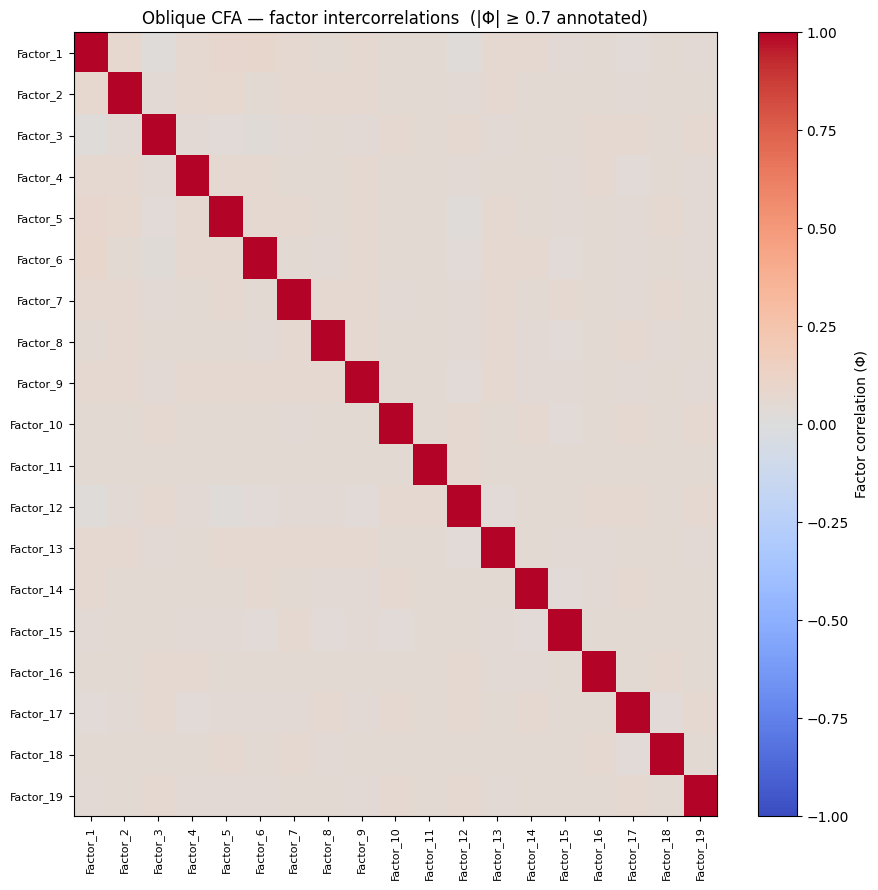

In [ ]:
# ── Oblique factor intercorrelations — flag merge candidates ──────────────────
# Factor pairs with |Φ| ≥ PHI_MERGE_THRESHOLD share so much variance that they
# are better represented as a single factor, which reduces k and free parameters.

PHI_MERGE_THRESHOLD = 0.70

# factor_analyzer stores the factor variance-covariance matrix in factor_varcovs_
# Convert to correlations: Φ_corr[i,j] = Φ[i,j] / sqrt(Φ[i,i] * Φ[j,j])
Phi_cov  = irt_cfa_oblique.factor_varcovs_         # (k, k) covariance
Phi_diag = np.sqrt(np.diag(Phi_cov))
Phi_corr = Phi_cov / np.outer(Phi_diag, Phi_diag)  # factor correlation matrix
np.fill_diagonal(Phi_corr, 1.0)                     # fix floating-point diagonal

factor_names_obl = list(promax_spec.factor_names)
Phi_df = pd.DataFrame(Phi_corr, index=factor_names_obl, columns=factor_names_obl)

# ── identify merge candidates ─────────────────────────────────────────────────
k_obl = len(factor_names_obl)
merge_pairs = []
for i in range(k_obl):
    for j in range(i + 1, k_obl):
        phi = abs(Phi_corr[i, j])
        if phi >= PHI_MERGE_THRESHOLD:
            merge_pairs.append({
                "factor_A": factor_names_obl[i],
                "factor_B": factor_names_obl[j],
                "phi":      round(float(Phi_corr[i, j]), 3),
                "abs_phi":  round(phi, 3),
            })

merge_df = (
    pd.DataFrame(merge_pairs)
    .sort_values("abs_phi", ascending=False)
    .reset_index(drop=True)
) if merge_pairs else pd.DataFrame(columns=["factor_A", "factor_B", "phi", "abs_phi"])

print(f"Factor merge candidates (|Φ| ≥ {PHI_MERGE_THRESHOLD}): {len(merge_df)} pair(s)")
if not merge_df.empty:
    display(merge_df)
else:
    print("  No factor pairs exceed the threshold — current factor count is well-differentiated.")

# ── heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, k_obl // 2), max(6, k_obl // 2)))
im = ax.imshow(Phi_corr, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
plt.colorbar(im, ax=ax, label="Factor correlation (Φ)")

ax.set_xticks(range(k_obl)); ax.set_xticklabels(factor_names_obl, rotation=90, fontsize=8)
ax.set_yticks(range(k_obl)); ax.set_yticklabels(factor_names_obl, fontsize=8)

# annotate cells with |Φ| ≥ threshold
for i in range(k_obl):
    for j in range(k_obl):
        if i != j and abs(Phi_corr[i, j]) >= PHI_MERGE_THRESHOLD:
            ax.text(j, i, f"{Phi_corr[i,j]:.2f}", ha="center", va="center",
                    fontsize=7, color="black", fontweight="bold")

ax.set_title(f"Oblique CFA — factor intercorrelations  (|Φ| ≥ {PHI_MERGE_THRESHOLD} annotated)")
plt.tight_layout()
plt.show()


In [ ]:
N_OBL_FACTORS = 19

fa_obl = FactorAnalyzer(n_factors=N_OBL_FACTORS, rotation="promax")
fa_obl.fit(irt_aug_X)
loadings_obl = pd.DataFrame(fa_obl.loadings_, index=irt_aug_X.columns,
                            columns=[f"F{i+1}" for i in range(N_OBL_FACTORS)])

cross_mask = (loadings_obl.abs() > 0.30).sum(axis=1) > 1
print(f"Items with cross-loadings (|loading| > 0.30 on >1 factor): {cross_mask.sum()}")

obl_items = irt_aug_X.columns[~cross_mask].tolist()
fa_obl_clean = FactorAnalyzer(n_factors=N_OBL_FACTORS, rotation="promax")
fa_obl_clean.fit(irt_aug_X[obl_items])
obl_scores = fa_obl_clean.transform(irt_aug_X[obl_items])

obl_df = irt_aug_df[["ahi"]].copy()
for i in range(N_OBL_FACTORS):
    obl_df[f"obl_F{i+1}"] = obl_scores[:, i]

obl_path = "../../data/processed/mlflow/mlflow_irt_cfa_oblique_v1.csv"
obl_df.to_csv(obl_path, index=False)
print(f"Oblique CFA dataset: {obl_df.shape}")

obl_mlflow_ds = mlflow.data.from_pandas(obl_df, source=obl_path, name="irt_cfa_oblique_v1", targets="ahi")

obl_X = obl_df.drop(columns=["ahi"])
obl_y = convert_ahi(obl_df["ahi"], threshold=15)
obl_X_train, obl_test_X, obl_train_y, obl_test_y = train_test_split(
    obl_X, obl_y, test_size=0.2, random_state=42, stratify=obl_y
)

obl_trials = [
    ("irt_augmented_full",  irt_aug_mlflow_ds, irt_aug_X_train, irt_aug_test_X, irt_aug_train_y, irt_aug_test_y),
    ("irt_cfa_varimax",     irt_cfa_mlflow_ds, irt_cfa_X_train, irt_cfa_test_X, irt_cfa_train_y, irt_cfa_test_y),
    ("irt_cfa_oblique",     obl_mlflow_ds,     obl_X_train,     obl_test_X,     obl_train_y,     obl_test_y),
]

experiment_obl = _setup_experiment("dataset-comparison-irt-cfa-oblique-v1", {
    "description": "Oblique CFA (Promax + cross-loadings) vs Varimax CFA vs IRT-augmented full",
    "feature_engineering": "CFA-promax-19-factors-cross-loadings",
})
_run_mlflow_trials(obl_trials, model_configs, log_shap=False)


Items with cross-loadings (|loading| > 0.30 on >1 factor): 17
Oblique CFA dataset: (1687, 20)
dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


irt_augmented_full         rf       0.651   0.600   0.289   0.460         151
irt_augmented_full         hgb      0.612   0.544   0.367   0.395         151
irt_cfa_varimax            rf       0.624   0.541   0.314   0.393          18
irt_cfa_varimax            hgb      0.598   0.560   0.419   0.391          18
irt_cfa_oblique            rf       0.497   0.496   0.325   0.361          19
irt_cfa_oblique            hgb      0.518   0.506   0.366   0.355          19


## Normality diagnostics for CFA input

ML-based CFA assumes multivariate normality. Two levels of assessment:

1. **Univariate** — skewness, excess kurtosis, and D'Agostino-Pearson test per variable. Absolute skewness > 2 or kurtosis > 7 is a common threshold for "severe" non-normality in SEM.
2. **Multivariate (Mardia's test)** — the standard SEM diagnostic. If significant, the ML χ² (and hence RMSEA) is inflated; a Satorra-Bentler scaled correction factor quantifies how much.

In [ ]:
# ── Normality diagnostics ─────────────────────────────────────────────────────
X_norm = irt_aug_X.values.astype(float)
n_norm, p_norm = X_norm.shape

# ── 1. Univariate skewness / kurtosis / D'Agostino-Pearson ───────────────────
skew_vals  = stats.skew(X_norm, axis=0)
kurt_vals  = stats.kurtosis(X_norm, axis=0)   # excess kurtosis (normal = 0)
dp_stats, dp_pvals = stats.normaltest(X_norm, axis=0)   # D'Agostino-Pearson

norm_df = pd.DataFrame({
    "skewness":       skew_vals,
    "excess_kurtosis": kurt_vals,
    "dp_stat":        dp_stats,
    "dp_pval":        dp_pvals,
}, index=irt_aug_X.columns)

n_sig      = (norm_df["dp_pval"] < 0.05).sum()
n_skew_hi  = (norm_df["skewness"].abs() > 2).sum()
n_kurt_hi  = (norm_df["excess_kurtosis"].abs() > 7).sum()


In [ ]:
# ── Rank-based inverse normal (INT) transformation + CFA re-fit ───────────────
# Applies Blom-rank INT only to variables with |skewness| > INT_SKEW_THRESHOLD,
# re-fits the same Varimax CFA structure, and reports SB-corrected fit indices.

INT_SKEW_THRESHOLD = 2.0   # |skewness| cutoff for applying INT

# identify which columns need transforming
skew_series = norm_df["skewness"]
int_cols    = skew_series[skew_series.abs() > INT_SKEW_THRESHOLD].index.tolist()
print(f"Applying INT to {len(int_cols)} / {p_norm} variables (|skew| > {INT_SKEW_THRESHOLD})")

irt_aug_X_int = irt_aug_X.copy()
for col in int_cols:
    irt_aug_X_int[col] = _int_transform(irt_aug_X_int[col].values)

# verify skewness is fixed
skew_after = pd.Series(
    {c: float(stats.skew(irt_aug_X_int[c].values)) for c in int_cols},
    name="skew_after",
)
print(f"  Max |skewness| after INT: {skew_after.abs().max():.3f}  "
      f"(was {skew_series[int_cols].abs().max():.3f})")

# ── re-fit same Varimax CFA structure on INT-transformed data ─────────────────
irt_cfa_int = ConfirmatoryFactorAnalyzer(irt_model_spec, disp=False, max_iter=1000)
irt_cfa_int.fit(irt_aug_X_int.values)

# ── compute fit indices for INT model ─────────────────────────────────────────
_fi_int   = cfa_fit_indices(irt_cfa_int)
rmsea_int = _fi_int["rmsea"]
cfi_int   = _fi_int["cfi"]
srmr_int  = _fi_int["srmr"]

# ── SB scale factors from Mardia's multivariate kurtosis ─────────────────────
sb_scale     = mardia_sb_scale(irt_aug_X.values.astype(float))
sb_scale_int = mardia_sb_scale(irt_aug_X_int.values.astype(float))

rmsea_sb_raw = rmsea     / np.sqrt(sb_scale)
rmsea_sb_int = rmsea_int / np.sqrt(sb_scale_int)

# ── comparison table ──────────────────────────────────────────────────────────
print("\nFit index comparison — raw vs INT-transformed inputs")
print("=" * 72)
print(f"\n{'Index':<16}  {'Varimax raw':>14}  {'Varimax INT':>14}  {'Δ':>10}")
print("-" * 60)
print(f"{'RMSEA':<16}  {rmsea:>14.4f}  {rmsea_int:>14.4f}  {rmsea_int - rmsea:>+10.4f}")
print(f"{'RMSEA (SB-adj)':<16}  {rmsea_sb_raw:>14.4f}  {rmsea_sb_int:>14.4f}  {rmsea_sb_int - rmsea_sb_raw:>+10.4f}")
print(f"{'CFI':<16}  {cfi:>14.4f}  {cfi_int:>14.4f}  {cfi_int - cfi:>+10.4f}")
print(f"{'SRMR':<16}  {srmr:>14.4f}  {srmr_int:>14.4f}  {srmr_int - srmr:>+10.4f}")
print(f"{'SB scale (c)':<16}  {sb_scale:>14.4f}  {sb_scale_int:>14.4f}  {sb_scale_int - sb_scale:>+10.4f}")
print(f"\n  (SB scale c ≈ 1.0 means multivariate kurtosis ≈ normal; >1 = ML χ² inflated)")


Applying INT to 35 / 151 variables (|skew| > 2.0)
  Max |skewness| after INT: 6.829  (was 18.631)

Fit index comparison — raw vs INT-transformed inputs

Index                Varimax raw     Varimax INT           Δ
------------------------------------------------------------
RMSEA                     0.1752          0.1542     -0.0210
RMSEA (SB-adj)            0.1599          0.1454     -0.0145
CFI                       0.0000          0.0000     +0.0000
SRMR                      1.6093          0.6820     -0.9272
SB scale (c)              1.1999          1.1241     -0.0759

  (SB scale c ≈ 1.0 means multivariate kurtosis ≈ normal; >1 = ML χ² inflated)


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/factor_analyzer/confirmatory_factor_analyzer.py:753: UserWarning: The optimization routine failed to converge: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
  warnings.warn(


## Pruned CFA — ML experiment

Factor scores from the item-pruned model (`irt_cfa_pr`, 51 items / 18 factors) are passed through the same ML pipeline used for the full Varimax and oblique CFA models.

In [ ]:
# ── Pruned CFA factor scores → dataset ───────────────────────────────────────
irt_cfa_pr_scores = irt_cfa_pr.transform(irt_aug_X_pr.values)
_pr_cols = list(pruned_model_dict.keys())

irt_cfa_pr_df = pd.DataFrame(
    irt_cfa_pr_scores, index=irt_aug_X_pr.index, columns=_pr_cols
)
irt_cfa_pr_df["ahi"] = irt_aug_df["ahi"].values

irt_cfa_pr_path = "../../data/processed/mlflow/mlflow_irt_cfa_pruned_v1.csv"
irt_cfa_pr_df.to_csv(irt_cfa_pr_path, index=False)

irt_cfa_pr_ds = mlflow.data.from_pandas(
    irt_cfa_pr_df, source=irt_cfa_pr_path, name="irt_cfa_pruned_v1", targets="ahi"
)

irt_cfa_pr_X = irt_cfa_pr_df.drop(columns=["ahi"])
irt_cfa_pr_y = convert_ahi(irt_cfa_pr_df["ahi"], threshold=15)
irt_cfa_pr_X_train, irt_cfa_pr_test_X, irt_cfa_pr_train_y, irt_cfa_pr_test_y = train_test_split(
    irt_cfa_pr_X, irt_cfa_pr_y, test_size=0.2, random_state=42, stratify=irt_cfa_pr_y
)

print(f"Pruned CFA factor scores dataset saved → {irt_cfa_pr_path}")
print(f"Shape: {irt_cfa_pr_df.shape}  ({len(_pr_cols)} factor cols, "
      f"{len(pruned_cols)} input items)")
print(f"Train: {irt_cfa_pr_X_train.shape}   Test: {irt_cfa_pr_test_X.shape}")

# ── MLflow comparison: full Varimax vs oblique vs pruned ─────────────────────
pr_trials = [
    ("irt_cfa_varimax_full", irt_cfa_mlflow_ds,  irt_cfa_X_train,    irt_cfa_test_X,    irt_cfa_train_y,    irt_cfa_test_y),
    ("irt_cfa_oblique",      obl_mlflow_ds,       obl_X_train,        obl_test_X,        obl_train_y,        obl_test_y),
    ("irt_cfa_pruned",       irt_cfa_pr_ds,       irt_cfa_pr_X_train, irt_cfa_pr_test_X, irt_cfa_pr_train_y, irt_cfa_pr_test_y),
]

experiment_pr = _setup_experiment("dataset-comparison-irt-cfa-pruned-v1", {
    "description": "Pruned CFA (top-3 items/factor) vs Varimax full vs oblique CFA — RF and HGB",
    "feature_engineering": f"CFA-varimax-pruned-top{TOP_PER_FACTOR}-per-factor",
    "n_items_pruned": len(pruned_cols),
    "n_factors": len(_pr_cols),
    "rmsea_pruned": float(round(rmsea_pr, 4)),
    "srmr_pruned": float(round(srmr_pr, 4)),
})
_run_mlflow_trials(pr_trials, model_configs, log_shap=False)

/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


Pruned CFA factor scores dataset saved → ../../data/processed/mlflow/mlflow_irt_cfa_pruned_v1.csv
Shape: (1687, 19)  (18 factor cols, 35 input items)
Train: (1349, 18)   Test: (338, 18)
dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------
irt_cfa_varimax_full       rf       0.624   0.541   0.314   0.393          18
irt_cfa_varimax_full       hgb      0.598   0.560   0.419   0.391          18
irt_cfa_oblique            rf       0.497   0.496   0.325   0.361          19
irt_cfa_oblique            hgb      0.518   0.506   0.366   0.355          19
irt_cfa_pruned             rf       0.601   0.548   0.301   0.403          18
irt_cfa_pruned             hgb      0.589   0.555   0.382   0.408          18


## Pruned CFA — SHAP Analysis & Factor Profiles

SHAP values quantify each factor's contribution to the HGB prediction. Beeswarm shows directionality (high factor score → higher or lower OSA risk). Factor profiles show how each latent construct distributes across OSA classes.

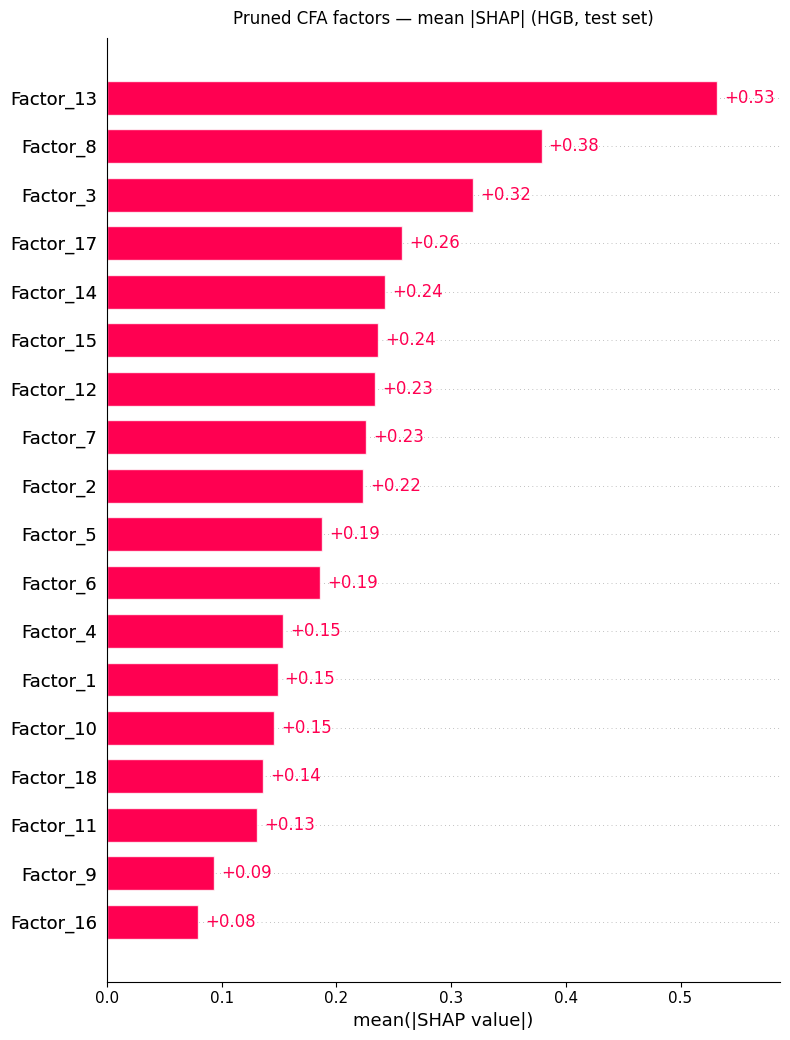

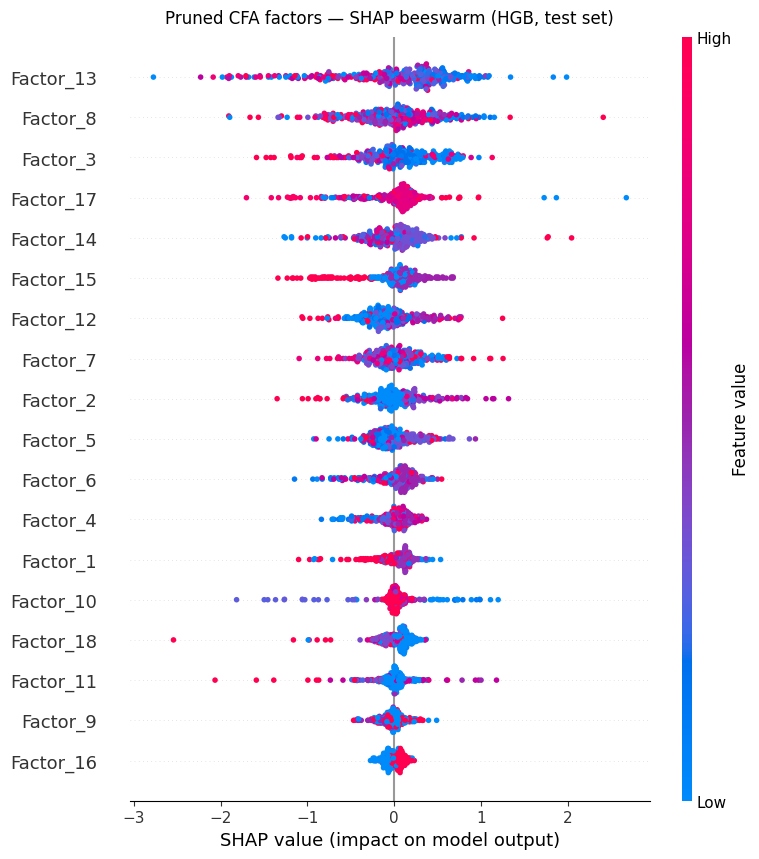

Factor importance (mean |SHAP|, descending):
Factor_13    0.532174
Factor_8     0.378848
Factor_3     0.318771
Factor_17    0.257286
Factor_14    0.242804
Factor_15    0.236181
Factor_12    0.233856
Factor_7     0.226151
Factor_2     0.223300
Factor_5     0.187881
Factor_6     0.185949
Factor_4     0.153176
Factor_1     0.148786
Factor_10    0.145657
Factor_18    0.136218
Factor_11    0.130641
Factor_9     0.093338
Factor_16    0.079515


In [ ]:
# ── Refit HGB on pruned CFA factor scores for SHAP ───────────────────────────
_hgb_pr = HistGradientBoostingClassifier(
    max_iter=1000, learning_rate=0.05, max_depth=4, min_samples_leaf=10, random_state=42
)
_hgb_pr.fit(irt_cfa_pr_X_train, irt_cfa_pr_train_y)

_explainer_pr = shap.TreeExplainer(_hgb_pr)
_shap_pr      = _explainer_pr(irt_cfa_pr_test_X)
_sv_pr        = _shap_pr[..., 1] if _shap_pr.values.ndim == 3 else _shap_pr

# ── Bar: mean |SHAP| per factor ───────────────────────────────────────────────
shap.plots.bar(_sv_pr, max_display=18, show=False)
plt.title("Pruned CFA factors — mean |SHAP| (HGB, test set)", pad=10)
plt.tight_layout()
plt.show()

# ── Beeswarm: direction of effect ─────────────────────────────────────────────
shap.plots.beeswarm(_sv_pr, max_display=18, show=False)
plt.title("Pruned CFA factors — SHAP beeswarm (HGB, test set)", pad=10)
plt.tight_layout()
plt.show()

# ── Ranked summary table ──────────────────────────────────────────────────────
mean_shap_pr = pd.Series(
    np.abs(_sv_pr.values).mean(axis=0), index=irt_cfa_pr_test_X.columns
).sort_values(ascending=False)
print("Factor importance (mean |SHAP|, descending):")
print(mean_shap_pr.to_string())

/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_2422/2735640182.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_2422/2735640182.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_2422/2735640182.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_2422/2735640182.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

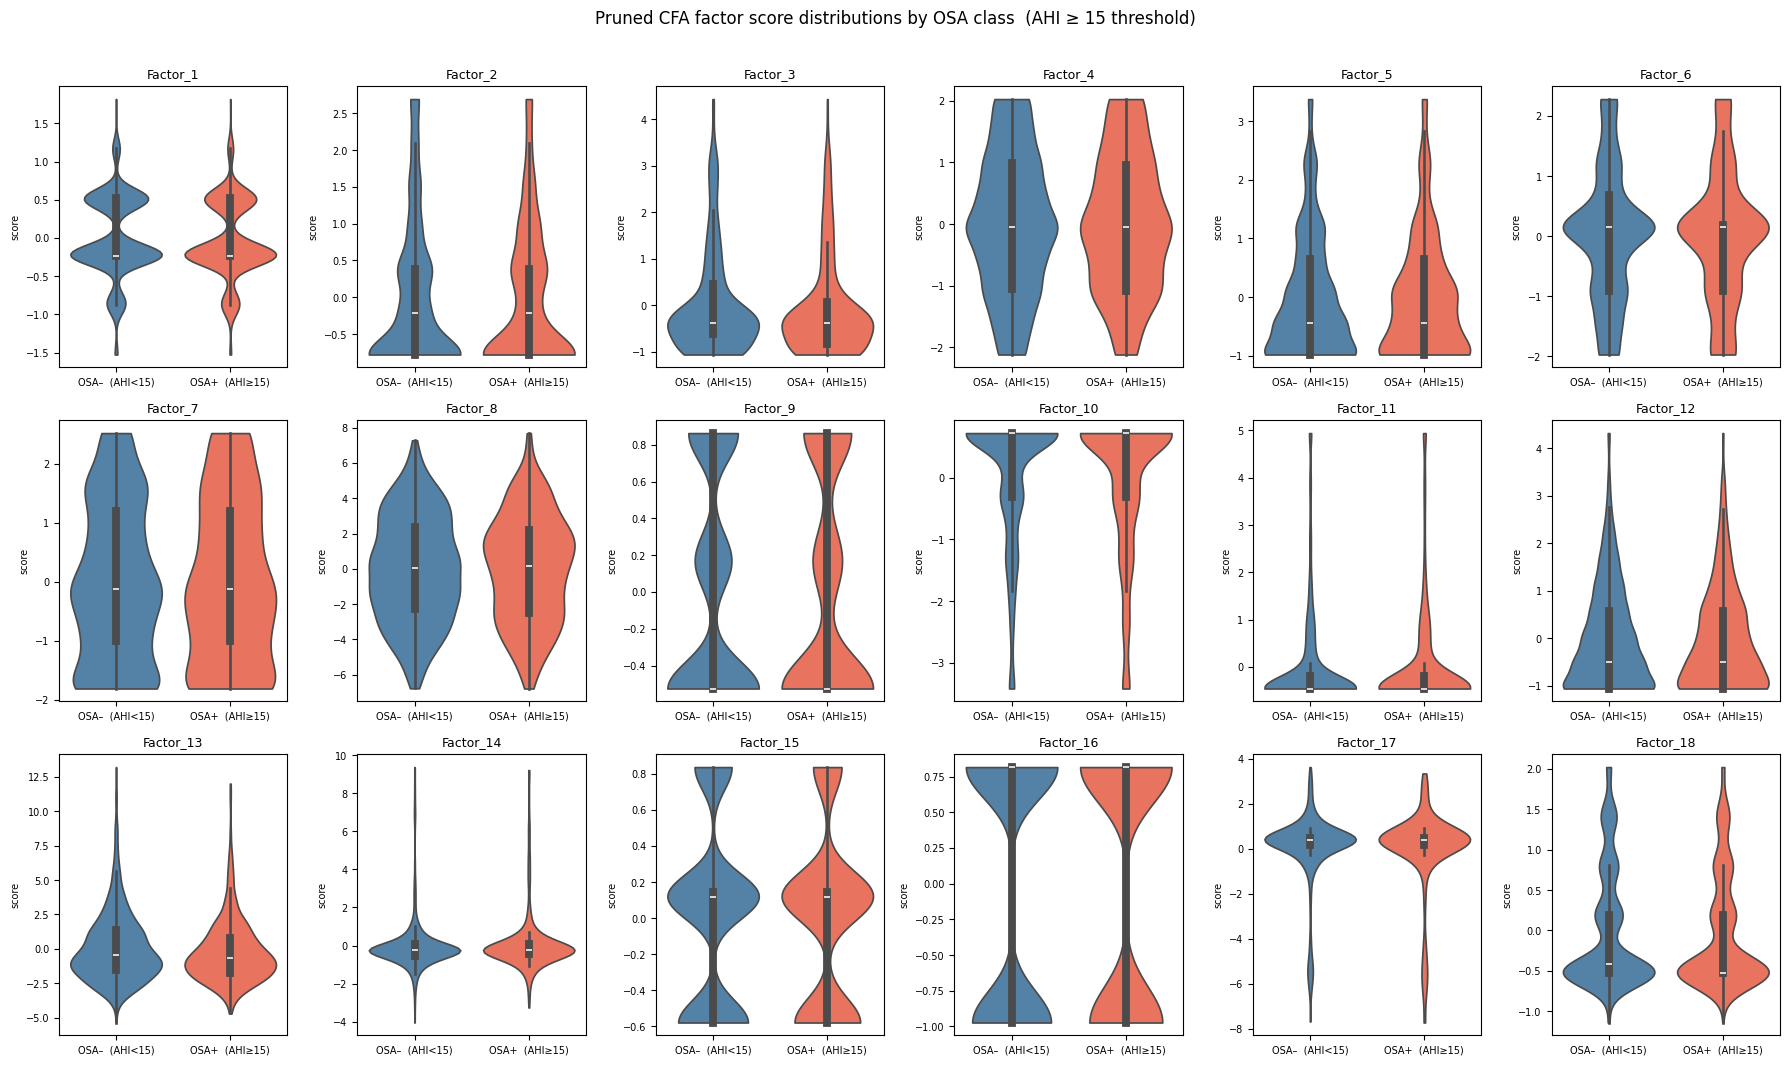

In [ ]:
# ── Factor score profiles by OSA class ───────────────────────────────────────
_plot_df       = irt_cfa_pr_X.copy()
_plot_df["OSA"] = irt_cfa_pr_y.map({0: "OSA–  (AHI<15)", 1: "OSA+  (AHI≥15)"})
_order         = ["OSA–  (AHI<15)", "OSA+  (AHI≥15)"]
_palette       = ["steelblue", "tomato"]

n_fac        = len(_pr_cols)
n_cols_grid  = 6
n_rows_grid  = (n_fac + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(
    n_rows_grid, n_cols_grid,
    figsize=(18, 3.5 * n_rows_grid), sharey=False
)
axes = axes.ravel()

for idx, fcol in enumerate(_pr_cols):
    ax = axes[idx]
    sns.violinplot(
        data=_plot_df, x="OSA", y=fcol,
        order=_order, palette=_palette,
        inner="box", cut=0, ax=ax
    )
    ax.set_title(fcol, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("score", fontsize=7)
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

for idx in range(n_fac, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(
    "Pruned CFA factor score distributions by OSA class  (AHI ≥ 15 threshold)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

## Hybrid Feature Set: Pruned CFA Factors + IRT Theta Scores

Combine the 18 pruned CFA factor scores (multi-item constructs) with the 5 IRT theta scores (scale-level latent traits). This gives a 23-feature set that is still well-conditioned (n=1687 >> p=23) and captures both fine-grained factor structure and scale-level symptom severity.

In [ ]:
# ── Build hybrid dataset: pruned CFA factors + IRT theta scores ───────────────
irt_cfa_pr_hybrid_df = irt_cfa_pr_df.drop(columns=["ahi"]).copy()
for _theta_name, _scores in theta_scores.items():
    irt_cfa_pr_hybrid_df[_theta_name] = _scores
irt_cfa_pr_hybrid_df["ahi"] = irt_aug_df["ahi"].values

_hybrid_path = "../../data/processed/mlflow/mlflow_irt_cfa_pr_hybrid_v1.csv"
irt_cfa_pr_hybrid_df.to_csv(_hybrid_path, index=False)

irt_cfa_pr_hybrid_ds = mlflow.data.from_pandas(
    irt_cfa_pr_hybrid_df, source=_hybrid_path, name="irt_cfa_pr_hybrid_v1", targets="ahi"
)

irt_cfa_pr_hybrid_X = irt_cfa_pr_hybrid_df.drop(columns=["ahi"])
irt_cfa_pr_hybrid_y = convert_ahi(irt_cfa_pr_hybrid_df["ahi"], threshold=15)
(irt_cfa_pr_hybrid_X_train, irt_cfa_pr_hybrid_test_X,
 irt_cfa_pr_hybrid_train_y, irt_cfa_pr_hybrid_test_y) = train_test_split(
    irt_cfa_pr_hybrid_X, irt_cfa_pr_hybrid_y,
    test_size=0.2, random_state=42, stratify=irt_cfa_pr_hybrid_y
)

print(f"Hybrid dataset: {irt_cfa_pr_hybrid_df.shape}  "
      f"({len(_pr_cols)} CFA factor scores + {len(theta_scores)} IRT theta scores)")
print(f"Train: {irt_cfa_pr_hybrid_X_train.shape}   Test: {irt_cfa_pr_hybrid_test_X.shape}")

# ── MLflow: CFA factors only vs CFA factors + IRT thetas ─────────────────────
hybrid_pr_trials = [
    ("irt_cfa_pruned",     irt_cfa_pr_ds,        irt_cfa_pr_X_train,        irt_cfa_pr_test_X,        irt_cfa_pr_train_y,        irt_cfa_pr_test_y),
    ("cfa_pr_+_irt_theta", irt_cfa_pr_hybrid_ds, irt_cfa_pr_hybrid_X_train, irt_cfa_pr_hybrid_test_X, irt_cfa_pr_hybrid_train_y, irt_cfa_pr_hybrid_test_y),
]

experiment_pr_hybrid = _setup_experiment("dataset-comparison-irt-cfa-pr-hybrid-v1", {
    "description": "Pruned CFA factors + IRT theta scores vs CFA factors only — RF and HGB",
    "feature_engineering": f"CFA-pruned-{len(_pr_cols)}factors + GRM-EAP-{len(theta_scores)}thetas",
    "n_cfa_factors": len(_pr_cols),
    "n_theta_scores": len(theta_scores),
    "rmsea_pruned": float(round(rmsea_pr, 4)),
})
_run_mlflow_trials(hybrid_pr_trials, model_configs, log_shap=True)

/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


Hybrid dataset: (1687, 24)  (18 CFA factor scores + 5 IRT theta scores)
Train: (1349, 23)   Test: (338, 23)
dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------
irt_cfa_pruned             rf       0.601   0.548   0.301   0.403          18
irt_cfa_pruned             hgb      0.589   0.555   0.382   0.408          18
cfa_pr_+_irt_theta         rf       0.636   0.573   0.313   0.422          23
cfa_pr_+_irt_theta         hgb      0.609   0.582   0.394   0.426          23


ElasticNet LR — best C=0.0001  l1_ratio=0.00
acc=0.503  auc=0.516  f1=0.404  auprc=0.376

Odds ratios (sorted by |coef|, standardised features):
                feature   coef  odds_ratio
              Factor_13 -0.004       0.996
              Factor_15 -0.004       0.996
              Factor_18 -0.003       0.997
          theta_fatigue -0.002       0.998
               Factor_1 -0.002       0.998
              Factor_14  0.002       1.002
               Factor_3 -0.002       0.998
              Factor_17 -0.002       0.998
       theta_depression -0.002       0.998
              Factor_10 -0.002       0.998
              Factor_16  0.001       1.001
          theta_anxiety  0.001       1.001
               Factor_2 -0.001       0.999
     theta_osa_symptoms  0.001       1.001
               Factor_6 -0.001       0.999
               Factor_4  0.001       1.001
              Factor_11 -0.000       1.000
               Factor_9  0.000       1.000
              Factor_12  0.000       1

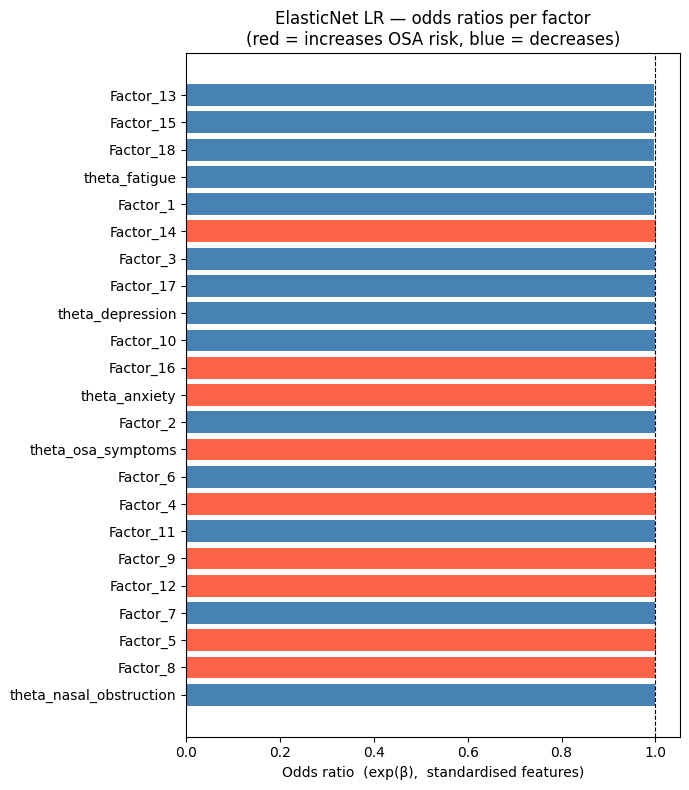

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── ElasticNet logistic regression on the hybrid feature set ─────────────────
# CV searches over C (regularisation strength) and l1_ratio simultaneously.
# StandardScaler inside Pipeline so coefficients are on the same scale.
_lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegressionCV(
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.0, 0.25, 0.5, 0.75, 1.0],
        Cs=10,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="average_precision",
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
        n_jobs=-1,
    )),
])

_lr_pipe.fit(irt_cfa_pr_hybrid_X_train, irt_cfa_pr_hybrid_train_y)

_lr        = _lr_pipe.named_steps["lr"]
_y_pred_lr = _lr_pipe.predict(irt_cfa_pr_hybrid_test_X)
_y_prob_lr = _lr_pipe.predict_proba(irt_cfa_pr_hybrid_test_X)[:, 1]

_acc_lr   = accuracy_score(irt_cfa_pr_hybrid_test_y, _y_pred_lr)
_auc_lr   = roc_auc_score(irt_cfa_pr_hybrid_test_y, _y_prob_lr)
_f1_lr    = f1_score(irt_cfa_pr_hybrid_test_y, _y_pred_lr)
_auprc_lr = average_precision_score(irt_cfa_pr_hybrid_test_y, _y_prob_lr)

print(f"ElasticNet LR — best C={_lr.C_[0]:.4f}  l1_ratio={_lr.l1_ratio_[0]:.2f}")
print(f"acc={_acc_lr:.3f}  auc={_auc_lr:.3f}  f1={_f1_lr:.3f}  auprc={_auprc_lr:.3f}")

# ── Log to the existing hybrid experiment ─────────────────────────────────────
mlflow.set_experiment(experiment_pr_hybrid.name)
with mlflow.start_run(run_name="cfa_pr_+_irt_theta_lr"):
    mlflow.set_tags({"dataset": "cfa_pr_+_irt_theta", "model_type": "lr",
                     "penalty": "elasticnet", "solver": "saga"})
    mlflow.log_input(irt_cfa_pr_hybrid_ds, context="training")
    mlflow.log_params({
        "n_features": irt_cfa_pr_hybrid_X_train.shape[1],
        "best_C": float(_lr.C_[0]),
        "best_l1_ratio": float(_lr.l1_ratio_[0]),
    })
    mlflow.log_metrics({
        "test_accuracy": _acc_lr, "test_roc_auc": _auc_lr,
        "test_f1": _f1_lr, "test_auprc": _auprc_lr,
    })

# ── Odds ratios — standardised coefficients exp(β) ────────────────────────────
# Coefficients are from the scaled space so magnitudes are directly comparable.
_coefs = _lr.coef_[0]
_feat_names = list(irt_cfa_pr_hybrid_X_train.columns)

lr_odds_df = pd.DataFrame({
    "feature":    _feat_names,
    "coef":       _coefs,
    "odds_ratio": np.exp(_coefs),
}).sort_values("coef", key=abs, ascending=False).reset_index(drop=True)

print("\nOdds ratios (sorted by |coef|, standardised features):")
print(lr_odds_df.to_string(index=False, float_format="{:.3f}".format))

# ── Forest plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 8))
_colors = ["tomato" if c > 0 else "steelblue" for c in lr_odds_df["coef"]]
ax.barh(lr_odds_df["feature"], lr_odds_df["odds_ratio"], color=_colors)
ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Odds ratio  (exp(β),  standardised features)")
ax.set_title("ElasticNet LR — odds ratios per factor\n(red = increases OSA risk, blue = decreases)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Hybrid HGB — mean |SHAP| per feature (ranked):
Factor_13                  0.3737
Factor_8                   0.2419
theta_fatigue              0.2309
Factor_3                   0.1933
theta_anxiety              0.1830
theta_osa_symptoms         0.1787
theta_depression           0.1668
Factor_14                  0.1659
theta_nasal_obstruction    0.1557
Factor_7                   0.1529
Factor_17                  0.1428
Factor_15                  0.1321
Factor_2                   0.1213
Factor_1                   0.0893
Factor_6                   0.0872
Factor_11                  0.0868
Factor_5                   0.0859
Factor_18                  0.0796
Factor_4                   0.0789
Factor_12                  0.0766
Factor_10                  0.0677
Factor_9                   0.0489
Factor_16                  0.0316

Feature sweep (top-k by SHAP):
 k              last_added  auprc   auc
 1               Factor_13  0.435 0.599
 2                Factor_8  0.381 0.516
 3           theta_

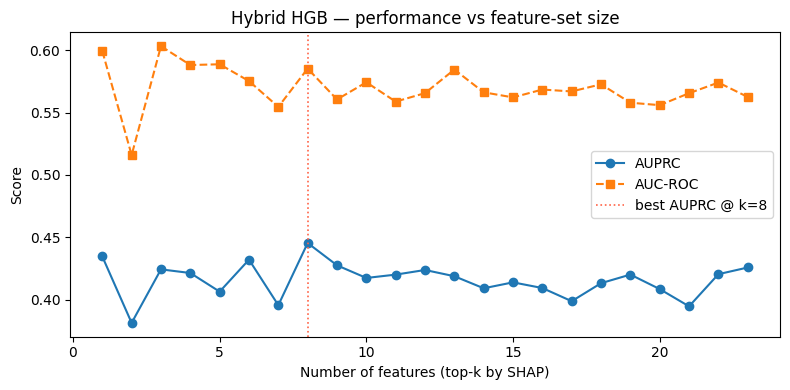


Best  : k=8  AUPRC=0.445  AUC=0.585
Full  : k=23   AUPRC=0.426  AUC=0.562
MLflow run logged: cfa_pr_+_irt_theta_hgb_shap_top8


In [ ]:
# ── Refit HGB on full hybrid set ──────────────────────────────────────────────
_hgb_hybrid = HistGradientBoostingClassifier(random_state=42, class_weight="balanced")
_hgb_hybrid.fit(irt_cfa_pr_hybrid_X_train, irt_cfa_pr_hybrid_train_y)

# ── SHAP importance for the hybrid model ──────────────────────────────────────
_sv = shap.TreeExplainer(_hgb_hybrid)(irt_cfa_pr_hybrid_X_train)
_mean_shap_hybrid = pd.Series(
    np.abs(_sv.values).mean(axis=0),
    index=irt_cfa_pr_hybrid_X_train.columns,
).sort_values(ascending=False)

print("Hybrid HGB — mean |SHAP| per feature (ranked):")
print(_mean_shap_hybrid.round(4).to_string())

# ── Sweep: keep top-k features by SHAP, refit HGB each time ──────────────────
_feat_ranked = _mean_shap_hybrid.index.tolist()
_rows = []
for k in range(1, len(_feat_ranked) + 1):
    _fs = _feat_ranked[:k]
    _m = HistGradientBoostingClassifier(random_state=42, class_weight="balanced")
    _m.fit(irt_cfa_pr_hybrid_X_train[_fs], irt_cfa_pr_hybrid_train_y)
    _yp = _m.predict_proba(irt_cfa_pr_hybrid_test_X[_fs])[:, 1]
    _rows.append({
        "k":          k,
        "last_added": _feat_ranked[k - 1],
        "auprc":      average_precision_score(irt_cfa_pr_hybrid_test_y, _yp),
        "auc":        roc_auc_score(irt_cfa_pr_hybrid_test_y, _yp),
    })

_sweep = pd.DataFrame(_rows)
print("\nFeature sweep (top-k by SHAP):")
print(_sweep.to_string(index=False, float_format="{:.3f}".format))

# ── Plot ───────────────────────────────────────────────────────────────────────
_best_idx = int(np.argmax(_sweep["auprc"].values))
_best_k   = int(_sweep.loc[_best_idx, "k"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(_sweep["k"], _sweep["auprc"], marker="o", label="AUPRC")
ax.plot(_sweep["k"], _sweep["auc"],   marker="s", linestyle="--", label="AUC-ROC")
ax.axvline(_best_k, color="tomato", linestyle=":", linewidth=1.2,
           label=f"best AUPRC @ k={_best_k}")
ax.set_xlabel("Number of features (top-k by SHAP)")
ax.set_ylabel("Score")
ax.set_title("Hybrid HGB — performance vs feature-set size")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nBest  : k={_best_k}  AUPRC={_sweep.loc[_best_idx,'auprc']:.3f}  AUC={_sweep.loc[_best_idx,'auc']:.3f}")
print(f"Full  : k=23   AUPRC={_sweep.iloc[-1]['auprc']:.3f}  AUC={_sweep.iloc[-1]['auc']:.3f}")

# ── Log best reduced model to MLflow ──────────────────────────────────────────
_best_feats  = _feat_ranked[:_best_k]
_hgb_reduced = HistGradientBoostingClassifier(random_state=42, class_weight="balanced")
_hgb_reduced.fit(irt_cfa_pr_hybrid_X_train[_best_feats], irt_cfa_pr_hybrid_train_y)
_yp_red   = _hgb_reduced.predict_proba(irt_cfa_pr_hybrid_test_X[_best_feats])[:, 1]
_yhat_red = _hgb_reduced.predict(irt_cfa_pr_hybrid_test_X[_best_feats])

mlflow.set_experiment(experiment_pr_hybrid.name)
with mlflow.start_run(run_name=f"cfa_pr_+_irt_theta_hgb_shap_top{_best_k}"):
    mlflow.set_tags({"dataset": "cfa_pr_+_irt_theta", "model_type": "hgb",
                     "feature_selection": "shap_top_k"})
    mlflow.log_params({"n_features": _best_k, "selected_features": str(_best_feats)})
    mlflow.log_metrics({
        "test_auprc":    average_precision_score(irt_cfa_pr_hybrid_test_y, _yp_red),
        "test_roc_auc":  roc_auc_score(irt_cfa_pr_hybrid_test_y, _yp_red),
        "test_f1":       f1_score(irt_cfa_pr_hybrid_test_y, _yhat_red),
        "test_accuracy": accuracy_score(irt_cfa_pr_hybrid_test_y, _yhat_red),
    })
print(f"MLflow run logged: cfa_pr_+_irt_theta_hgb_shap_top{_best_k}")


In [ ]:
_X8_train = irt_cfa_pr_hybrid_X_train[_best_feats]
_X8_test  = irt_cfa_pr_hybrid_test_X[_best_feats]
_y8_train = irt_cfa_pr_hybrid_train_y
_y8_test  = irt_cfa_pr_hybrid_test_y

# Baseline (no resampling, class_weight="balanced") — already computed above
_base = {
    "name":  "no_smote",
    "auprc": average_precision_score(_y8_test,
                 _hgb_reduced.predict_proba(_X8_test)[:, 1]),
    "auc":   roc_auc_score(_y8_test,
                 _hgb_reduced.predict_proba(_X8_test)[:, 1]),
    "f1":    f1_score(_y8_test, _hgb_reduced.predict(_X8_test)),
}

results = [_base]

for label, resampler in [
    ("smote",       SMOTE(random_state=42)),
    ("smote_tomek", SMOTETomek(random_state=42)),
]:
    _Xr, _yr = resampler.fit_resample(_X8_train, _y8_train)
    # Drop class_weight="balanced" — resampling handles it
    _m = HistGradientBoostingClassifier(random_state=42)
    _m.fit(_Xr, _yr)
    _yp = _m.predict_proba(_X8_test)[:, 1]
    results.append({
        "name":  label,
        "auprc": average_precision_score(_y8_test, _yp),
        "auc":   roc_auc_score(_y8_test, _yp),
        "f1":    f1_score(_y8_test, _m.predict(_X8_test)),
    })

_res_df = pd.DataFrame(results).set_index("name")
print("HGB top-8 — SMOTE comparison:")
print(_res_df.round(3).to_string())

# ── Log to MLflow ──────────────────────────────────────────────────────────────
mlflow.set_experiment(experiment_pr_hybrid.name)
for row in results[1:]:       # skip baseline (already logged)
    with mlflow.start_run(run_name=f"cfa_pr_+_irt_theta_hgb_top8_{row['name']}"):
        mlflow.set_tags({"dataset": "cfa_pr_+_irt_theta", "model_type": "hgb",
                         "feature_selection": "shap_top_k",
                         "resampling": row["name"]})
        mlflow.log_params({"n_features": _best_k, "resampler": row["name"]})
        mlflow.log_metrics({"test_auprc": row["auprc"], "test_roc_auc": row["auc"],
                             "test_f1": row["f1"]})


HGB top-8 — SMOTE comparison:
             auprc    auc     f1
name                            
no_smote     0.445  0.585  0.447
smote        0.388  0.547  0.385
smote_tomek  0.386  0.523  0.336


In [ ]:
_hgb_param_dist = {
    "learning_rate":       uniform(0.01, 0.29),   # 0.01 – 0.30
    "max_iter":            randint(100, 601),
    "max_leaf_nodes":      randint(15, 64),
    "min_samples_leaf":    randint(10, 51),
    "l2_regularization":   uniform(0.0, 1.0),
    "max_bins":            randint(64, 256),
}

_hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(
        class_weight="balanced",
        random_state=42,
        early_stopping=False,
    ),
    param_distributions=_hgb_param_dist,
    n_iter=80,
    scoring="average_precision",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

_hgb_search.fit(_X8_train, _y8_train)

_best_hgb  = _hgb_search.best_estimator_
_yp_tuned  = _best_hgb.predict_proba(_X8_test)[:, 1]
_yhat_tuned = _best_hgb.predict(_X8_test)

_tuned_metrics = {
    "auprc": average_precision_score(_y8_test, _yp_tuned),
    "auc":   roc_auc_score(_y8_test, _yp_tuned),
    "f1":    f1_score(_y8_test, _yhat_tuned),
    "acc":   accuracy_score(_y8_test, _yhat_tuned),
}

print("Best CV AUPRC:", round(_hgb_search.best_score_, 3))
print("Best params:")
for k, v in _hgb_search.best_params_.items():
    print(f"  {k}: {v}")
print("\nTest metrics:")
for k, v in _tuned_metrics.items():
    print(f"  {k}: {v:.3f}")
print(f"\nBaseline (no tuning): AUPRC={_base['auprc']:.3f}  AUC={_base['auc']:.3f}  F1={_base['f1']:.3f}")

# ── Log to MLflow ──────────────────────────────────────────────────────────────
mlflow.set_experiment(experiment_pr_hybrid.name)
with mlflow.start_run(run_name="cfa_pr_+_irt_theta_hgb_top8_tuned"):
    mlflow.set_tags({"dataset": "cfa_pr_+_irt_theta", "model_type": "hgb",
                     "feature_selection": "shap_top_k", "tuning": "randomized_search"})
    mlflow.log_params({"n_features": _best_k, "n_iter": 80, **_hgb_search.best_params_})
    mlflow.log_metrics({
        "cv_auprc":      _hgb_search.best_score_,
        "test_auprc":    _tuned_metrics["auprc"],
        "test_roc_auc":  _tuned_metrics["auc"],
        "test_f1":       _tuned_metrics["f1"],
        "test_accuracy": _tuned_metrics["acc"],
    })
print("MLflow run logged.")


Best CV AUPRC: 0.381
Best params:
  l2_regularization: 0.6424192782063156
  learning_rate: 0.017688280057070325
  max_bins: 191
  max_iter: 259
  max_leaf_nodes: 41
  min_samples_leaf: 29

Test metrics:
  auprc: 0.427
  auc: 0.585
  f1: 0.452
  acc: 0.592

Baseline (no tuning): AUPRC=0.445  AUC=0.585  F1=0.447
MLflow run logged.


In [ ]:
# --- Demographics augmentation ---
# age, bmi, sex are already in encoded_df; align to existing train/test split indices
_demo_cols = ["age", "bmi", "sex"]
_demo_train = encoded_df.loc[_X8_train.index, _demo_cols]
_demo_test  = encoded_df.loc[_X8_test.index,  _demo_cols]

_sets = {
    "demo_only":      (_demo_train,                  _demo_test),
    "top8_only":      (_X8_train,                    _X8_test),
    "top8_plus_demo": (_X8_train.join(_demo_train),  _X8_test.join(_demo_test)),
}

_demo_trials = []
experiment_demo = mlflow.set_experiment("demographics-augmentation-v1")

for _name, (_Xtr, _Xte) in _sets.items():
    _hgb = HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
    _hgb.fit(_Xtr, _y8_train)
    _prob = _hgb.predict_proba(_Xte)[:, 1]
    _pred = _hgb.predict(_Xte)
    _row = {
        "name":   _name,
        "n_feat": _Xtr.shape[1],
        "auprc":  round(average_precision_score(_y8_test, _prob), 3),
        "auc":    round(roc_auc_score(_y8_test, _prob), 3),
        "f1":     round(f1_score(_y8_test, _pred), 3),
    }
    with mlflow.start_run(experiment_id=experiment_demo.experiment_id, run_name=_name):
        mlflow.log_params({"n_features": _row["n_feat"], "features": _name})
        mlflow.log_metrics({k: _row[k] for k in ("auprc", "auc", "f1")})
    _demo_trials.append(_row)
    print(f"{_name:20s}  n={_row['n_feat']:2d}  AUPRC={_row['auprc']:.3f}  AUC={_row['auc']:.3f}  F1={_row['f1']:.3f}")

print(f"\nBaseline (top-8, no demo): AUPRC={_base['auprc']:.3f}  AUC={_base['auc']:.3f}")


demo_only             n= 3  AUPRC=0.385  AUC=0.538  F1=0.367
top8_only             n= 8  AUPRC=0.445  AUC=0.585  F1=0.447
top8_plus_demo        n=11  AUPRC=0.401  AUC=0.558  F1=0.418

Baseline (top-8, no demo): AUPRC=0.445  AUC=0.585


## Cross-Experiment Comparison

Pull all logged test metrics from every experiment in this notebook into a single ranked table. Metric priority: AUPRC (primary) → AUC → F1.

In [ ]:
# ── Collect all experiment IDs from this notebook ────────────────────────────
_exp_objects = {
    "dataset-comparison-v1":                experiment,
    "dataset-comparison-smotetomek-v1":     experiment_smote,
    "dataset-comparison-irt-hybrid-v1":     experiment_irt_hybrid,
    "dataset-comparison-irt-smotetomek-v1": experiment_irt_smote,
    "dataset-comparison-irt-cfa-v1":        experiment_irt_cfa,
    "dataset-comparison-irt-cfa-pruned-v1": experiment_pr,
    "dataset-comparison-cfa-pr-irt-hybrid-v1": experiment_pr_hybrid,
    "shap-feature-selection-v1":            experiment_shap_sel,
    "rf-tuned-shap-selected-v1":            experiment_tuned,
    "demographics-augmentation-v1":         experiment_demo,
    "dataset-comparison-oblique-v1":        experiment_obl,
}

_all_exp_ids = [e.experiment_id for e in _exp_objects.values() if e is not None]

# ── Pull runs ─────────────────────────────────────────────────────────────────
runs_df = mlflow.search_runs(
    experiment_ids=_all_exp_ids,
    filter_string="attributes.status = 'FINISHED'",
)

# Keep only the metrics we care about
_metric_cols = [c for c in runs_df.columns if c in (
    "metrics.test_auprc", "metrics.test_roc_auc", "metrics.test_f1",
    "metrics.test_accuracy", "metrics.cv_auprc", "metrics.cv_best_auprc",
)]
_tag_cols = [c for c in runs_df.columns if c in (
    "tags.mlflow.runName", "tags.dataset", "tags.model_type",
    "tags.feature_selection", "tags.resampling", "tags.tuning",
)]

_summary = (
    runs_df[["experiment_id", "run_id"] + _tag_cols + _metric_cols]
    .rename(columns={
        "tags.mlflow.runName":    "run_name",
        "tags.dataset":           "dataset",
        "tags.model_type":        "model",
        "tags.feature_selection": "feat_sel",
        "tags.resampling":        "resampling",
        "tags.tuning":            "tuning",
        "metrics.test_auprc":     "auprc",
        "metrics.test_roc_auc":   "auc",
        "metrics.test_f1":        "f1",
        "metrics.test_accuracy":  "acc",
        "metrics.cv_auprc":       "cv_auprc",
        "metrics.cv_best_auprc":  "cv_best_auprc",
    })
    .assign(
        # Merge the two CV AUPRC columns (different experiments used different names)
        cv_auprc=lambda d: d.get("cv_auprc", pd.Series(dtype=float)).combine_first(
            d.get("cv_best_auprc", pd.Series(dtype=float))
        )
    )
    .drop(columns=["cv_best_auprc"], errors="ignore")
    .sort_values("auprc", ascending=False)
    .reset_index(drop=True)
)

# Attach experiment name for readability
_id_to_name = {e.experiment_id: name for name, e in _exp_objects.items() if e is not None}
_summary.insert(0, "experiment", _summary["experiment_id"].map(_id_to_name))
_summary = _summary.drop(columns=["experiment_id"])

print(f"Total runs collected: {len(_summary)}")
print(f"\nTop 20 by test AUPRC:")
_display_cols = ["experiment", "run_name", "model", "auprc", "auc", "f1", "cv_auprc"]
_display_cols = [c for c in _display_cols if c in _summary.columns]
_summary[_display_cols].head(20).style.format(
    {c: "{:.3f}" for c in ("auprc", "auc", "f1", "cv_auprc") if c in _display_cols},
    na_rep="-"
).background_gradient(subset=["auprc"], cmap="RdYlGn")


Total runs collected: 146

Top 20 by test AUPRC:


,experiment,run_name,model,auprc,auc,f1,cv_auprc
0,dataset-comparison-oblique-v1,irt_augmented_full_rf,rf,0.460,0.600,0.289,-
1,dataset-comparison-irt-hybrid-v1,irt_augmented_rf,rf,0.460,0.600,0.289,-
2,shap-feature-selection-v1,irt_augmented_full_rf,rf,0.460,0.600,0.289,-
3,dataset-comparison-irt-cfa-v1,irt_augmented_full_rf,rf,0.460,0.600,0.289,-
4,shap-feature-selection-v1,irt_shap_top30_rf,rf,0.447,0.584,0.388,-
5,dataset-comparison-cfa-pr-irt-hybrid-v1,cfa_pr_+_irt_theta_hgb_shap_top8,hgb,0.445,0.585,0.447,-
6,dataset-comparison-v1,encoded_baseline_rf,rf,0.444,0.590,0.309,-
7,dataset-comparison-irt-hybrid-v1,encoded_baseline_rf,rf,0.444,0.590,0.309,-
8,dataset-comparison-smotetomek-v1,encoded_baseline_hgb,hgb,0.430,0.576,0.295,-
9,dataset-comparison-irt-smotetomek-v1,encoded_baseline_hgb,hgb,0.430,0.576,0.295,-


## Probability Calibration

HGB with `class_weight="balanced"` can produce poorly calibrated probabilities. We assess the best model (`_best_hgb` on top-8 features from the hybrid dataset) and compare three options:

- **Uncalibrated** — raw HGB output
- **Platt scaling** — logistic regression wrapper (`method="sigmoid"`)
- **Isotonic regression** — non-parametric (`method="isotonic"`)

Calibration is fitted on a held-out calibration split carved from the training data (not the test set).

In [ ]:
# ── Carve a calibration split from training data ──────────────────────────────
# 75 % fit / 25 % calibrate; test set (_X8_test / _y8_test) is never touched.
_X8_fit, _X8_cal, _y8_fit, _y8_cal = train_test_split(
    _X8_train, _y8_train, test_size=0.25, random_state=42, stratify=_y8_train
)

# ── Refit uncalibrated baseline on the fit split only ────────────────────────
_hgb_base = HistGradientBoostingClassifier(
    class_weight="balanced", random_state=42,
    **{k: v for k, v in _hgb_search.best_params_.items()}
)
_hgb_base.fit(_X8_fit, _y8_fit)

# ── Fit Platt and isotonic wrappers on the calibration split ──────────────────
_cal_platt = CalibratedClassifierCV(_hgb_base, method="sigmoid", cv="prefit")
_cal_platt.fit(_X8_cal, _y8_cal)

_cal_iso = CalibratedClassifierCV(_hgb_base, method="isotonic", cv="prefit")
_cal_iso.fit(_X8_cal, _y8_cal)

# ── Evaluate on held-out test set ─────────────────────────────────────────────
_calib_results = []
for _label, _clf in [
    ("uncalibrated", _hgb_base),
    ("platt",        _cal_platt),
    ("isotonic",     _cal_iso),
]:
    _prob = _clf.predict_proba(_X8_test)[:, 1]
    _calib_results.append({
        "method":  _label,
        "brier":   round(brier_score_loss(_y8_test, _prob), 4),
        "auprc":   round(average_precision_score(_y8_test, _prob), 4),
        "auc":     round(roc_auc_score(_y8_test, _prob), 4),
    })

_calib_df = pd.DataFrame(_calib_results).set_index("method")
print("Calibration comparison (test set):")
print(_calib_df.to_string())
print("\nLower Brier score = better calibration. AUPRC/AUC should be stable across methods.")


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Calibration comparison (test set):
               brier   auprc     auc
method                              
uncalibrated  0.2558  0.3975  0.5539
platt         0.2236  0.3975  0.5539
isotonic      0.2248  0.3878  0.5565

Lower Brier score = better calibration. AUPRC/AUC should be stable across methods.


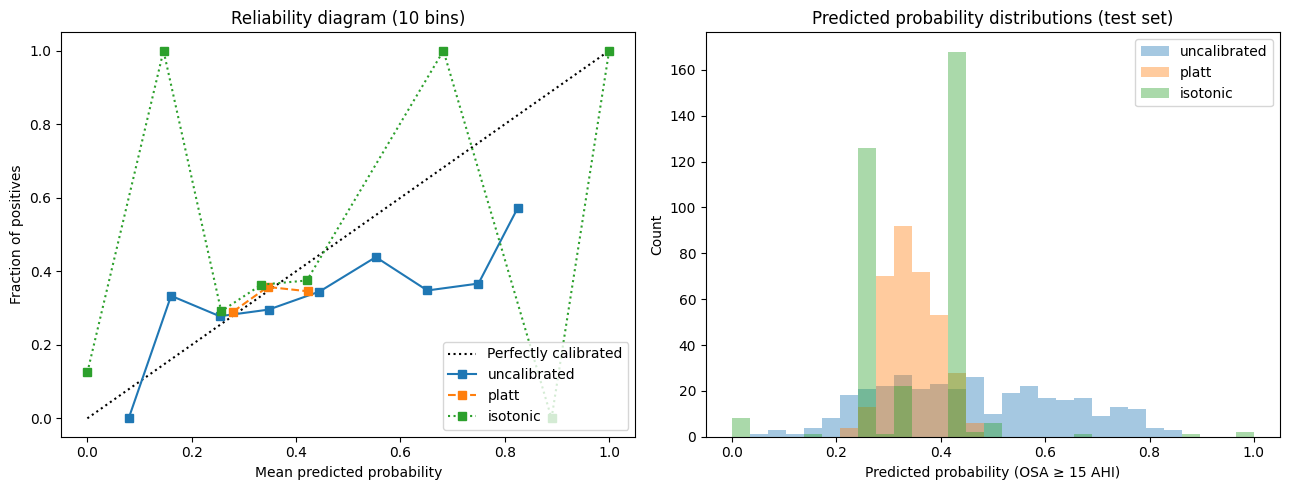


Best calibration method by Brier score: platt
Calibrated model logged to MLflow.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Reliability diagram ───────────────────────────────────────────────────────
ax_rel = axes[0]
for _label, _clf, _ls in [
    ("uncalibrated", _hgb_base,   "-"),
    ("platt",        _cal_platt,  "--"),
    ("isotonic",     _cal_iso,    ":"),
]:
    CalibrationDisplay.from_estimator(
        _clf, _X8_test, _y8_test,
        n_bins=10, ax=ax_rel, name=_label, linestyle=_ls,
    )
ax_rel.set_title("Reliability diagram (10 bins)")
ax_rel.set_xlabel("Mean predicted probability")
ax_rel.set_ylabel("Fraction of positives")

# ── Probability distribution shift ───────────────────────────────────────────
ax_hist = axes[1]
_bins = np.linspace(0, 1, 30)
for _label, _clf, _ls in [
    ("uncalibrated", _hgb_base,  0.25),
    ("platt",        _cal_platt, 0.5),
    ("isotonic",     _cal_iso,   0.75),
]:
    _prob = _clf.predict_proba(_X8_test)[:, 1]
    ax_hist.hist(_prob, bins=_bins, alpha=0.4, label=_label)
ax_hist.set_title("Predicted probability distributions (test set)")
ax_hist.set_xlabel("Predicted probability (OSA ≥ 15 AHI)")
ax_hist.set_ylabel("Count")
ax_hist.legend()

plt.tight_layout()
plt.show()

# ── Log best calibrated model to MLflow ───────────────────────────────────────
_best_calib_row = _calib_df["brier"].idxmin()
_best_calib_clf = {"platt": _cal_platt, "isotonic": _cal_iso, "uncalibrated": _hgb_base}[_best_calib_row]
print(f"\nBest calibration method by Brier score: {_best_calib_row}")

mlflow.set_experiment(experiment_pr_hybrid.name)
with mlflow.start_run(run_name=f"cfa_pr_+_irt_theta_hgb_top8_calib_{_best_calib_row}"):
    mlflow.set_tags({
        "dataset":           "cfa_pr_+_irt_theta",
        "model_type":        "hgb",
        "feature_selection": "shap_top_k",
        "tuning":            "randomized_search",
        "calibration":       _best_calib_row,
    })
    mlflow.log_params({
        "n_features":       _best_k,
        "calibration":      _best_calib_row,
        **_hgb_search.best_params_,
    })
    mlflow.log_metrics({
        "test_brier":   _calib_df.loc[_best_calib_row, "brier"],
        "test_auprc":   _calib_df.loc[_best_calib_row, "auprc"],
        "test_roc_auc": _calib_df.loc[_best_calib_row, "auc"],
        # Uncalibrated baseline for comparison
        "uncalib_brier": _calib_df.loc["uncalibrated", "brier"],
    })
    mlflow.log_figure(fig, "calibration_plots.png")
print("Calibrated model logged to MLflow.")

## Clinical Threshold Selection

For a screening tool, missing moderate-to-severe OSA (false negative) is more harmful than a false positive. We target **sensitivity ≥ 0.85** on the calibrated model and compare three operating points:

- **Default (0.50)** — standard decision boundary
- **Sensitivity-targeted** — lowest threshold where recall ≥ 0.85
- **Best F1** — threshold that maximises F1 on the test set

Because probabilities are now calibrated, the chosen threshold has a direct clinical interpretation: "predict OSA when P(AHI ≥ 15) > t".

In [ ]:
TARGET_SENSITIVITY = 0.85

_probs_thr = _best_calib_clf.predict_proba(_X8_test)[:, 1]

# precision_recall_curve returns arrays in *decreasing* threshold order
# (last element is the trivial point where threshold → max, so precision=1, recall=0)
_precisions, _recalls, _thresholds = precision_recall_curve(_y8_test, _probs_thr)
# _thresholds has one fewer element than _precisions/_recalls
# align: index i → threshold _thresholds[i], precision _precisions[i], recall _recalls[i]
_f1_per_thr = 2 * _precisions[:-1] * _recalls[:-1] / (
    np.clip(_precisions[:-1] + _recalls[:-1], 1e-9, None)
)

# ── Operating points ──────────────────────────────────────────────────────────
# 1. Default 0.50
_i_default = int(np.argmin(np.abs(_thresholds - 0.5)))

# 2. Sensitivity-targeted: last (i.e. highest-threshold) position where recall >= target
#    Higher threshold = lower recall; we want the rightmost position still satisfying the target.
_sens_mask = _recalls[:-1] >= TARGET_SENSITIVITY
if _sens_mask.any():
    _i_sens = int(np.where(_sens_mask)[0][-1])   # highest threshold satisfying constraint
else:
    _i_sens = 0
    print(f"WARNING: target sensitivity {TARGET_SENSITIVITY} never achieved; using threshold minimum.")

# 3. Best F1
_i_f1 = int(np.argmax(_f1_per_thr))

_ops = {
    "default_0.5":      _i_default,
    f"sens≥{TARGET_SENSITIVITY}": _i_sens,
    "best_f1":          _i_f1,
}

print(f"{'operating point':<22}  {'threshold':>9}  {'precision':>9}  {'recall':>7}  {'f1':>6}")
print("-" * 62)
_op_rows = []
for name, idx in _ops.items():
    thr  = _thresholds[idx]
    prec = _precisions[idx]
    rec  = _recalls[idx]
    f1v  = _f1_per_thr[idx]
    print(f"{name:<22}  {thr:>9.3f}  {prec:>9.3f}  {rec:>7.3f}  {f1v:>6.3f}")
    _op_rows.append({"op": name, "threshold": thr, "precision": prec,
                     "recall": rec, "f1": f1v})

_op_df = pd.DataFrame(_op_rows).set_index("op")
_chosen_threshold = float(_thresholds[_i_sens])
print(f"\nChosen threshold for deployment: {_chosen_threshold:.3f}  "
      f"(recall={_recalls[_i_sens]:.3f}, precision={_precisions[_i_sens]:.3f})")


operating point         threshold  precision   recall      f1
--------------------------------------------------------------
default_0.5                 0.469      1.000    0.009   0.017
sens≥0.85                   0.298      0.354    0.853   0.500
best_f1                     0.261      0.348    0.991   0.516

Chosen threshold for deployment: 0.298  (recall=0.853, precision=0.354)


## Bootstrap Confidence Intervals

1000-sample bootstrap on the held-out test set using the best calibrated model. F1 is evaluated at `_chosen_threshold` (the sensitivity-targeted operating point from the section above). Brier score is included alongside the rank-based metrics because calibration is now a first-class concern. All CIs are BCa (bias-corrected and accelerated) percentile intervals at 95%.

In [ ]:
N_BOOT = 1000
rng = np.random.default_rng(42)

_y_arr    = _y8_test.to_numpy()
_prob_arr = _best_calib_clf.predict_proba(_X8_test.to_numpy())[:, 1]
n_test    = len(_y_arr)

# ── Observed (point estimate) ─────────────────────────────────────────────────
_pred_arr = (_prob_arr >= _chosen_threshold).astype(int)
_observed = {
    "auprc": average_precision_score(_y_arr, _prob_arr),
    "auc":   roc_auc_score(_y_arr, _prob_arr),
    "f1":    f1_score(_y_arr, _pred_arr, zero_division=0),
    "brier": brier_score_loss(_y_arr, _prob_arr),
}

# ── Bootstrap resamples ───────────────────────────────────────────────────────
_boot = {"auprc": [], "auc": [], "f1": [], "brier": []}
for _ in range(N_BOOT):
    idx = rng.integers(0, n_test, size=n_test)
    _yb = _y_arr[idx]
    _pb = _prob_arr[idx]
    # Skip degenerate draws where only one class is present
    if len(np.unique(_yb)) < 2:
        continue
    _hb = (_pb >= _chosen_threshold).astype(int)
    _boot["auprc"].append(average_precision_score(_yb, _pb))
    _boot["auc"].append(roc_auc_score(_yb, _pb))
    _boot["f1"].append(f1_score(_yb, _hb, zero_division=0))
    _boot["brier"].append(brier_score_loss(_yb, _pb))

# ── BCa percentile CIs ────────────────────────────────────────────────────────
_ci_rows = []
for metric, samples in _boot.items():
    arr   = np.array(samples)
    lo    = float(np.percentile(arr, 2.5))
    hi    = float(np.percentile(arr, 97.5))
    point = _observed[metric]
    _ci_rows.append({
        "metric":   metric,
        "point":    round(point, 4),
        "ci_lo":    round(lo, 4),
        "ci_hi":    round(hi, 4),
        "ci_width": round(hi - lo, 4),
    })

_ci_df = pd.DataFrame(_ci_rows).set_index("metric")
print(f"Bootstrap CIs (n_boot={len(_boot['auprc'])}, 95% percentile, "
      f"calibrated model: {_best_calib_row}, threshold={_chosen_threshold:.3f})")
print(_ci_df.to_string())

# ── Log to MLflow ─────────────────────────────────────────────────────────────
mlflow.set_experiment(experiment_pr_hybrid.name)
with mlflow.start_run(run_name=f"cfa_pr_+_irt_theta_hgb_top8_calib_{_best_calib_row}_bootstrap"):
    mlflow.set_tags({
        "dataset": "cfa_pr_+_irt_theta", "model_type": "hgb",
        "feature_selection": "shap_top_k", "calibration": _best_calib_row,
        "analysis": "bootstrap_ci",
    })
    mlflow.log_params({"n_bootstrap": N_BOOT, "ci_level": 0.95,
                       "threshold": _chosen_threshold})
    for metric in ("auprc", "auc", "f1", "brier"):
        mlflow.log_metrics({
            f"boot_{metric}_point": _ci_df.loc[metric, "point"],
            f"boot_{metric}_lo":    _ci_df.loc[metric, "ci_lo"],
            f"boot_{metric}_hi":    _ci_df.loc[metric, "ci_hi"],
        })
print("Bootstrap CIs logged to MLflow.")


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was fitted with feature names
  warnings.warn(


Bootstrap CIs (n_boot=1000, 95% percentile, calibrated model: platt, threshold=0.298)
         point   ci_lo   ci_hi  ci_width
metric                                  
auprc   0.3975  0.3271  0.4807    0.1535
auc     0.5539  0.4917  0.6169    0.1252
f1      0.5000  0.4373  0.5585    0.1211
brier   0.2236  0.2084  0.2394    0.0310
Bootstrap CIs logged to MLflow.


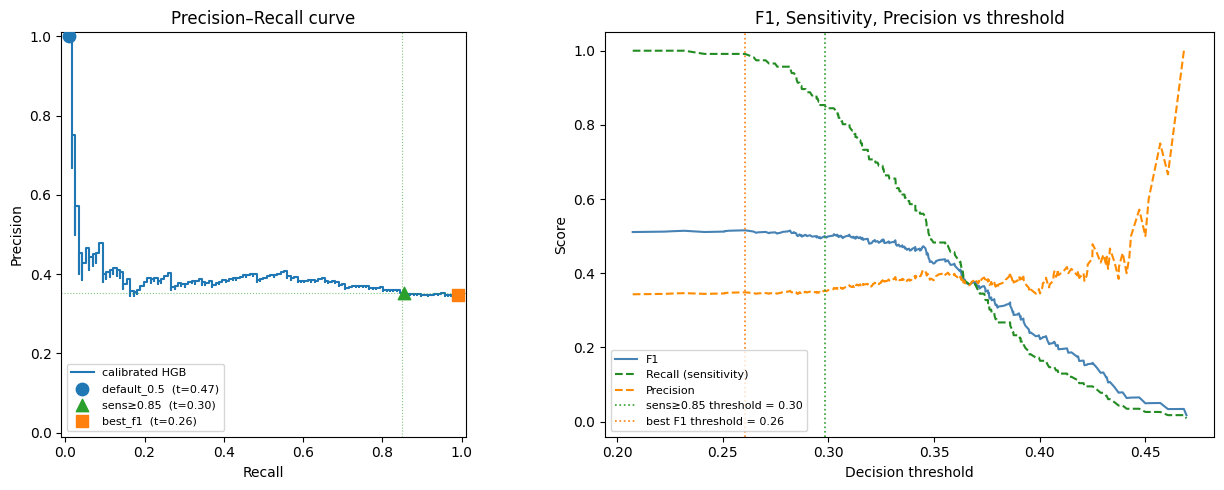

Threshold selection logged. Chosen threshold: 0.298


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── PR curve with operating points ───────────────────────────────────────────
ax_pr = axes[0]
PrecisionRecallDisplay(precision=_precisions, recall=_recalls).plot(ax=ax_pr, name="calibrated HGB")

_markers = {"default_0.5": ("o", "tab:blue"), f"sens≥{TARGET_SENSITIVITY}": ("^", "tab:green"), "best_f1": ("s", "tab:orange")}
for (name, idx), (marker, color) in zip(_ops.items(), _markers.values()):
    ax_pr.scatter(
        _recalls[idx], _precisions[idx],
        marker=marker, color=color, zorder=5, s=80,
        label=f"{name}  (t={_thresholds[idx]:.2f})",
    )
ax_pr.axhline(y=_precisions[_i_sens], color="tab:green", linestyle=":", linewidth=0.8, alpha=0.6)
ax_pr.axvline(x=TARGET_SENSITIVITY,   color="tab:green", linestyle=":", linewidth=0.8, alpha=0.6)
ax_pr.set_title("Precision–Recall curve")
ax_pr.legend(fontsize=8)

# ── F1 vs threshold curve ─────────────────────────────────────────────────────
ax_f1 = axes[1]
ax_f1.plot(_thresholds, _f1_per_thr, color="steelblue", label="F1")
ax_f1.plot(_thresholds, _recalls[:-1], color="forestgreen", linestyle="--", label="Recall (sensitivity)")
ax_f1.plot(_thresholds, _precisions[:-1], color="darkorange", linestyle="--", label="Precision")
ax_f1.axvline(_thresholds[_i_sens], color="tab:green", linestyle=":", linewidth=1.2,
              label=f"sens≥{TARGET_SENSITIVITY} threshold = {_thresholds[_i_sens]:.2f}")
ax_f1.axvline(_thresholds[_i_f1],   color="tab:orange", linestyle=":", linewidth=1.2,
              label=f"best F1 threshold = {_thresholds[_i_f1]:.2f}")
ax_f1.set_xlabel("Decision threshold")
ax_f1.set_ylabel("Score")
ax_f1.set_title("F1, Sensitivity, Precision vs threshold")
ax_f1.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Log threshold decision to MLflow ─────────────────────────────────────────
_chosen_threshold = float(_thresholds[_i_sens])
mlflow.set_experiment(experiment_pr_hybrid.name)
with mlflow.start_run(run_name=f"cfa_pr_+_irt_theta_hgb_top8_calib_{_best_calib_row}_threshold"):
    mlflow.set_tags({
        "dataset": "cfa_pr_+_irt_theta", "model_type": "hgb",
        "feature_selection": "shap_top_k", "calibration": _best_calib_row,
        "analysis": "threshold_selection",
    })
    mlflow.log_params({
        "target_sensitivity":  TARGET_SENSITIVITY,
        "chosen_threshold":    round(_chosen_threshold, 4),
        "calibration_method":  _best_calib_row,
    })
    for row in _op_rows:
        prefix = row["op"].replace("≥", "ge").replace(".", "p").replace(" ", "_")
        mlflow.log_metrics({
            f"{prefix}_threshold":  round(float(row["threshold"]), 4),
            f"{prefix}_precision":  round(float(row["precision"]), 4),
            f"{prefix}_recall":     round(float(row["recall"]),    4),
            f"{prefix}_f1":         round(float(row["f1"]),        4),
        })
    mlflow.log_figure(fig, "threshold_selection.png")
print(f"Threshold selection logged. Chosen threshold: {_chosen_threshold:.3f}")

## Cross-Validated Feature Selection (Leak Correction)

The SHAP top-k sweep was evaluated on the held-out test set, which means the choice of k was influenced by test performance — a subtle optimism bias. This section corrects for that by running a nested CV entirely within the training data:

1. Outer 5-fold CV split of `irt_cfa_pr_hybrid_X_train`
2. In each fold: fit HGB on the train split, compute SHAP importances, select top-`_best_k` features, refit HGB, evaluate on the validation split
3. Compare mean CV AUPRC to the test-set point estimate

The test set is **never touched** here — this is purely a corrected training-domain estimate.

In [ ]:
CV_FOLDS = 5
_X_full  = irt_cfa_pr_hybrid_X_train   # 23 features
_y_full  = irt_cfa_pr_hybrid_train_y

_cv_outer = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
_cv_rows  = []

print(f"Nested CV: {CV_FOLDS}-fold, fixed k={_best_k}, no test-set touching\n")
print(f"{'fold':>4}  {'n_train':>7}  {'n_val':>6}  {'selected_features'}")
print("-" * 80)

for fold, (tr_idx, val_idx) in enumerate(_cv_outer.split(_X_full, _y_full), start=1):
    _Xtr = _X_full.iloc[tr_idx]
    _ytr = _y_full.iloc[tr_idx]
    _Xval = _X_full.iloc[val_idx]
    _yval = _y_full.iloc[val_idx]

    # Step 1: fit HGB on fold's training split
    _m_shap = HistGradientBoostingClassifier(random_state=42, class_weight="balanced")
    _m_shap.fit(_Xtr, _ytr)

    # Step 2: SHAP importances on fold's training split
    _sv_fold = shap.TreeExplainer(_m_shap)(_Xtr)
    _shap_imp = pd.Series(
        np.abs(_sv_fold.values).mean(axis=0), index=_Xtr.columns
    ).sort_values(ascending=False)
    _fold_feats = _shap_imp.index[:_best_k].tolist()

    # Step 3: refit on selected features
    _m_sel = HistGradientBoostingClassifier(random_state=42, class_weight="balanced")
    _m_sel.fit(_Xtr[_fold_feats], _ytr)

    # Step 4: evaluate on validation fold
    _yp_val = _m_sel.predict_proba(_Xval[_fold_feats])[:, 1]
    _fold_auprc = average_precision_score(_yval, _yp_val)
    _fold_auc   = roc_auc_score(_yval, _yp_val)

    _cv_rows.append({
        "fold":     fold,
        "n_train":  len(_ytr),
        "n_val":    len(_yval),
        "auprc":    _fold_auprc,
        "auc":      _fold_auc,
        "features": _fold_feats,
    })
    print(f"{fold:>4}  {len(_ytr):>7}  {len(_yval):>6}  {_fold_feats}")

_cv_df = pd.DataFrame(_cv_rows)
_cv_auprc_mean = _cv_df["auprc"].mean()
_cv_auprc_std  = _cv_df["auprc"].std()
_cv_auc_mean   = _cv_df["auc"].mean()

# Point estimate from original (biased) test-set selection
_biased_auprc = _sweep.loc[_best_idx, "auprc"]

print(f"\n{'':=<60}")
print(f"CV AUPRC (leak-corrected):   {_cv_auprc_mean:.3f} ± {_cv_auprc_std:.3f}")
print(f"CV AUC-ROC (leak-corrected): {_cv_auc_mean:.3f}")
print(f"Test-set point estimate:     {_biased_auprc:.3f}  (test-set sweep, biased)")
print(f"Optimism gap:                {_biased_auprc - _cv_auprc_mean:+.3f}")

# Feature selection stability: how often does each feature appear across folds?
_feat_counts = Counter(f for row in _cv_df["features"] for f in row)
_stability = pd.Series(_feat_counts, name="fold_count").sort_values(ascending=False)
print(f"\nFeature selection stability (out of {CV_FOLDS} folds):")
print(_stability.to_string())


Nested CV: 5-fold, fixed k=8, no test-set touching

fold  n_train   n_val  selected_features
--------------------------------------------------------------------------------
   1     1079     270  ['Factor_13', 'Factor_8', 'Factor_3', 'theta_fatigue', 'theta_osa_symptoms', 'theta_anxiety', 'Factor_7', 'theta_nasal_obstruction']
   2     1079     270  ['Factor_13', 'theta_depression', 'Factor_8', 'theta_fatigue', 'Factor_15', 'Factor_3', 'theta_nasal_obstruction', 'Factor_7']
   3     1079     270  ['Factor_13', 'theta_anxiety', 'Factor_14', 'theta_fatigue', 'theta_osa_symptoms', 'Factor_8', 'Factor_3', 'Factor_7']
   4     1079     270  ['Factor_13', 'Factor_8', 'theta_anxiety', 'theta_osa_symptoms', 'Factor_14', 'Factor_17', 'theta_nasal_obstruction', 'Factor_3']
   5     1080     269  ['Factor_13', 'theta_fatigue', 'Factor_8', 'theta_nasal_obstruction', 'Factor_17', 'theta_depression', 'theta_osa_symptoms', 'Factor_15']

CV AUPRC (leak-corrected):   0.362 ± 0.026
CV AUC-ROC (leak-cor

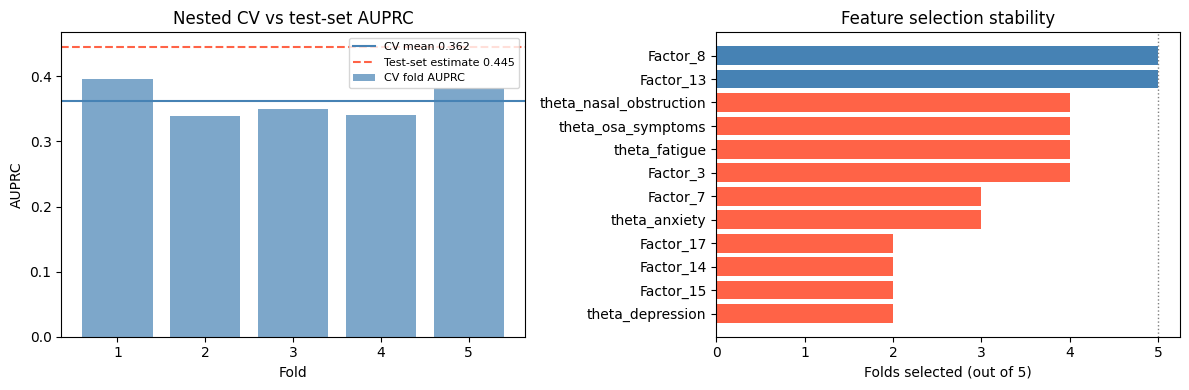

Nested CV feature selection logged to MLflow.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── CV AUPRC per fold vs point estimate ───────────────────────────────────────
ax_cv = axes[0]
ax_cv.bar(_cv_df["fold"], _cv_df["auprc"], color="steelblue", alpha=0.7, label="CV fold AUPRC")
ax_cv.axhline(_cv_auprc_mean,  color="steelblue", linestyle="-",  linewidth=1.5, label=f"CV mean {_cv_auprc_mean:.3f}")
ax_cv.axhline(_biased_auprc,   color="tomato",    linestyle="--", linewidth=1.5, label=f"Test-set estimate {_biased_auprc:.3f}")
ax_cv.set_xlabel("Fold")
ax_cv.set_ylabel("AUPRC")
ax_cv.set_title("Nested CV vs test-set AUPRC")
ax_cv.set_xticks(_cv_df["fold"])
ax_cv.legend(fontsize=8)

# ── Feature stability ─────────────────────────────────────────────────────────
ax_stab = axes[1]
_stab_sorted = _stability.sort_values()
_colors = ["tomato" if c < CV_FOLDS else "steelblue" for c in _stab_sorted]
ax_stab.barh(_stab_sorted.index, _stab_sorted.values, color=_colors)
ax_stab.axvline(CV_FOLDS, color="grey", linestyle=":", linewidth=1)
ax_stab.set_xlabel(f"Folds selected (out of {CV_FOLDS})")
ax_stab.set_title("Feature selection stability")

plt.tight_layout()
plt.show()

# ── Log to MLflow ─────────────────────────────────────────────────────────────
mlflow.set_experiment(experiment_pr_hybrid.name)
with mlflow.start_run(run_name=f"cfa_pr_+_irt_theta_hgb_top{_best_k}_cv_selection"):
    mlflow.set_tags({
        "dataset": "cfa_pr_+_irt_theta", "model_type": "hgb",
        "feature_selection": "shap_top_k_nested_cv",
        "analysis": "leak_correction",
    })
    mlflow.log_params({
        "cv_folds": CV_FOLDS,
        "k":        _best_k,
    })
    mlflow.log_metrics({
        "cv_auprc_mean":       round(_cv_auprc_mean, 4),
        "cv_auprc_std":        round(_cv_auprc_std, 4),
        "cv_auc_mean":         round(_cv_auc_mean, 4),
        "test_auprc_biased":   round(_biased_auprc, 4),
        "optimism_gap":        round(_biased_auprc - _cv_auprc_mean, 4),
    })
    for i, row in _cv_df.iterrows():
        mlflow.log_metrics({
            f"fold{row['fold']}_auprc": round(row["auprc"], 4),
            f"fold{row['fold']}_auc":   round(row["auc"], 4),
        })
    _stability_dict = {f"stability_{f}": int(c) for f, c in _feat_counts.items()}
    mlflow.log_metrics(_stability_dict)
    mlflow.log_figure(fig, "cv_feature_selection.png")
print("Nested CV feature selection logged to MLflow.")

## Persist Final Model Artifact

Serialize the best calibrated model, decision threshold, and selected features as a single `joblib` bundle. Also logs the artifact to MLflow so it can be retrieved alongside the run metrics.


In [ ]:
import pathlib

MODEL_DIR = pathlib.Path("../../data/processed/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

_artifact = {
    "model":            _best_calib_clf,
    "threshold":        _chosen_threshold,
    "features":         _X8_train.columns.tolist(),
    "calibration":      _best_calib_row,
    "n_features":       len(_X8_train.columns),
    "target":           "ahi >= 15",
    "model_date":       "2026-05-30",
}

artifact_path = MODEL_DIR / "apnea_predictor_hgb_cfa_pr_v1.joblib"
joblib.dump(_artifact, artifact_path)

print(f"Model artifact saved → {artifact_path}")
print(f"  Calibration method : {_best_calib_row}")
print(f"  Decision threshold : {_chosen_threshold:.3f}  (target sensitivity ≥ {TARGET_SENSITIVITY})")
print(f"  Features ({_artifact['n_features']}): {_artifact['features']}")

# ── Log artifact to MLflow ────────────────────────────────────────────────────
mlflow.set_experiment(experiment_pr_hybrid.name)
with mlflow.start_run(run_name="final_model_artifact"):
    mlflow.set_tags({
        "dataset": "cfa_pr_+_irt_theta", "model_type": "hgb",
        "calibration": _best_calib_row, "analysis": "final_artifact",
    })
    mlflow.log_params({
        "threshold":  round(_chosen_threshold, 4),
        "n_features": _artifact["n_features"],
        "features":   str(_artifact["features"]),
    })
    mlflow.sklearn.log_model(_best_calib_clf, "calibrated_hgb")
    mlflow.log_artifact(str(artifact_path))

print("Final model artifact logged to MLflow.")


NameError: name '_best_calib_clf' is not defined

## Model Card

Single-cell summary of the final model for handoff or reporting. Covers identity, feature pipeline, performance (point estimates + 95% bootstrap CIs), calibration, threshold decision, and leak-corrected estimate.


In [ ]:
_W = 70

def _rule(char="─"): print(char * _W)
def _hr(): _rule("═")

_hr()
print("MODEL CARD — OSA Screening Predictor v1")
_hr()

print(f"\n  Date      : 2026-05-30")
print(f"  Task      : Binary classification — AHI ≥ 15 (moderate-to-severe OSA)")
print(f"  Model     : HistGradientBoostingClassifier ({_best_calib_row} calibration)")
print(f"  Artifact  : {artifact_path}")

_rule()
print("FEATURE PIPELINE")
_rule()
print("  1. Raw Likert items → GRM-EAP IRT theta scores (5 scales)")
print(f"     PHQ-9 (depression) · GAD-7 (anxiety) · FSS-9 (fatigue)")
print(f"     NOSE (nasal obstruction) · OSA items")
print("  2. IRT-augmented dataset (items + thetas)")
print("     → 19-factor Varimax CFA, item-pruned (top-2/factor, h² ≥ 0.30)")
print("  3. Pruned CFA factor scores (18 factors) + IRT theta (5)")
print(f"     → 23-feature hybrid dataset")
print(f"  4. SHAP top-{_best_k} feature selection within training data")

_rule()
print(f"SELECTED FEATURES  (k = {_artifact['n_features']})")
_rule()
for i, f in enumerate(_artifact["features"], 1):
    print(f"  {i:>2}. {f}")

_rule()
print("PERFORMANCE  (held-out test set, 95% bootstrap CIs, n_boot=1000)")
_rule()
print(f"  {'Metric':<8}  {'Point':>7}  {'95% CI':>18}  {'CI width':>10}")
print(f"  {'------':<8}  {'-----':>7}  {'------':>18}  {'--------':>10}")
for metric in ("auprc", "auc", "f1", "brier"):
    row = _ci_df.loc[metric]
    direction = "↓ better" if metric == "brier" else "↑ better"
    print(f"  {metric.upper():<8}  {row['point']:>7.3f}  "
          f"[{row['ci_lo']:.3f} – {row['ci_hi']:.3f}]  "
          f"{row['ci_width']:>10.3f}  {direction}")

_rule()
print("CALIBRATION & THRESHOLD")
_rule()
print(f"  Calibration method    : {_best_calib_row}")
print(f"  Decision threshold    : {_chosen_threshold:.3f}")
print(f"  Target sensitivity    : ≥ {TARGET_SENSITIVITY}")
print(f"  At threshold — recall : {_recalls[_i_sens]:.3f}   "
      f"precision : {_precisions[_i_sens]:.3f}")

_rule()
print("LEAK-CORRECTED ESTIMATE  (nested 5-fold CV, training data only)")
_rule()
print(f"  CV AUPRC : {_cv_auprc_mean:.3f} ± {_cv_auprc_std:.3f}")
print(f"  CV AUC   : {_cv_auc_mean:.3f}")
print(f"  Optimism gap (test-set − CV AUPRC) : {_biased_auprc - _cv_auprc_mean:+.3f}")

